# Comparativa final — 4 modelos: métricas físicas + comparativa visual

Notebook unificado que evalúa cuatro modelos generativos condicionales:

- **DDPM-mío** (ResBlocks U-Net, 3 niveles, SiLU)
- **DDPM-paper** (Lee-style U-Net, 4 niveles, DoubleConv + self-attn)
- **NCSN v2** (Jha-style U-Net + **AdaGN** + λ Karras-stable)
- **CVAE** (PyTorch, encoder Conv stride-2 + prior condicional + decoder Conv-T + Sigmoid)

**Dos vistas en un solo notebook:**

1. **Cuantitativa** (`K=32`, `N_TARGET` configurable, balanceado por estructura):
   - 4 métricas físicas: magnetization, abs. magnetization, spin correlation, peak wavevector.
   - R² + MAE por modelo, general y por fase.
   - 10 figuras (5 R² + 5 MAE) + CSV.

2. **Visual** (`N_GRIDS=10` grillas 5×6):
   - Filas: Original + 4 modelos. Columnas: 6 fases. Para que elijas la que más representativa veas.

**Eficiencia:** cada modelo se carga UNA sola vez y genera ambos batches (cuantitativo y visual) antes de liberar GPU. Sin re-cargas.

**Inputs (datasets de Kaggle):**
- `dataset_unificado_v2.npz` (imgs, params, labels)
- `metrics.py`
- Pesos de los 4 modelos (paths configurables abajo)

In [1]:
# ============================================================
# CONFIGURACIÓN
# ============================================================
import os

# ── Cuantitativo ─────────────────────────────────────────────
K              = 32      # muestras por θ (se promedian para R²/MAE)
N_TARGET       = 1000    # nº de θ a evaluar (balanceado proporcional por fase). None = todo.
SEED           = 42      # split + selección balanceada
GEN_SEED       = 123     # ruido de generación

# ── Visual ───────────────────────────────────────────────────
N_GRIDS        = 10      # nº de grillas 5×6 a generar (cada una con θ distintos)
PICK_SEEDS     = list(range(N_GRIDS))  # seeds para selección de θ por fase

# ── Sampling ─────────────────────────────────────────────────
FAST_STEPS_DDPM = 50     # pasos DDIM para los DDPMs
ODE_STEPS_NCSN  = 100    # pasos RK3 para el NCSN
USE_MALA_NCSN   = False  # MALA polish (lento, ~50 pasos × 3 evals)
MALA_STEPS_NCSN = 50
MALA_EPS_NCSN   = 1e-4

# ── Batches GPU (T4 16GB) ────────────────────────────────────
THETA_CHUNK_GPU = 32     # batch efectivo cuantitativo = THETA_CHUNK_GPU * K

# ── Selección de modelos ─────────────────────────────────────
RUN_DDPM_MIO    = True
RUN_DDPM_PAPER  = True
RUN_NCSN        = True
RUN_CVAE        = True

# ── Paths Kaggle ─────────────────────────────────────────────
DATASET_PATH    = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz"
METRICS_PATH    = "/kaggle/input/datasets/carloscanamejoy/physicalmetrics/metrics.py"
DDPM_MIO_CKPT   = "/kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_final_39crop.pt"
DDPM_PAPER_CKPT = "/kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_lee_best.pt"  # ⚠️ ajustar
NCSN_CKPT       = "/kaggle/input/datasets/carloscanamejoy/weights-models/ncsn_jha_style.pt"                # ⚠️ ajustar
CVAE_PT_CKPT    = "/kaggle/input/datasets/carloscanamejoy/weights-models/cvae_8params.pth"          # ⚠️ ajustar

# ── Caches y outputs ─────────────────────────────────────────
CACHE_DIR = "/kaggle/working/eval_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Modelos y métricas ───────────────────────────────────────
MODELS   = ["DDPM-mio", "DDPM-paper", "NCSN", "CVAE"]
METRICS  = ["magnetization", "abs_magnetization", "spin_correlation", "peak_wavevector"]
METRIC_LABEL = {
    "magnetization":     "Magnetization",
    "abs_magnetization": "Abs. Magnetization",
    "spin_correlation":  "Spin Correlation",
    "peak_wavevector":   "Peak Wavevector",
}
MODEL_COLORS_LOCAL = {
    "DDPM-mio":   "#2563EB",
    "DDPM-paper": "#9333EA",
    "NCSN":       "#EA580C",
    "CVAE":       "#16A34A",
}
ROW_LABELS = ["Original", "DDPM-mio", "DDPM-paper", "NCSN", "CVAE"]

print(f"Cuantitativo: K={K}  N_TARGET={N_TARGET}  GPU batch={THETA_CHUNK_GPU*K}")
print(f"Visual:       N_GRIDS={N_GRIDS}  imgs/modelo={N_GRIDS*6}")
print(f"Modelos activos: " + ", ".join(m for m, r in zip(
    MODELS, [RUN_DDPM_MIO, RUN_DDPM_PAPER, RUN_NCSN, RUN_CVAE]) if r))

Cuantitativo: K=32  N_TARGET=1000  GPU batch=1024
Visual:       N_GRIDS=10  imgs/modelo=60
Modelos activos: DDPM-mio, DDPM-paper, NCSN, CVAE


## 1. Verificación de paths + cargar `metrics.py`

In [2]:
import sys, time, math, importlib.util, gc
import numpy as np

paths_to_check = [("dataset", DATASET_PATH), ("metrics.py", METRICS_PATH)]
if RUN_DDPM_MIO:    paths_to_check.append(("ddpm-mio",   DDPM_MIO_CKPT))
if RUN_DDPM_PAPER:  paths_to_check.append(("ddpm-paper", DDPM_PAPER_CKPT))
if RUN_NCSN:        paths_to_check.append(("ncsn-v2",    NCSN_CKPT))
if RUN_CVAE:        paths_to_check.append(("cvae-pt",    CVAE_PT_CKPT))

print("Paths:")
missing = []
for tag, p in paths_to_check:
    ok = os.path.exists(p)
    print(f"  {'OK ' if ok else 'MISS'}  {tag:14s} → {p}")
    if not ok: missing.append(tag)
if missing:
    print(f"\n⚠️  Faltan: {missing}. Ajusta los paths o desactiva esos modelos.")

spec = importlib.util.spec_from_file_location("metrics", METRICS_PATH)
metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(metrics)
sys.modules["metrics"] = metrics
from metrics import (STRUCTURE_NAMES, STRUCTURE_COLORS, MASK,
                     get_structure_label, magnetization, abs_magnetization,
                     cnn_correlation, structure_factor, azimuthal_average,
                     apply_figure_style, save_figure)
apply_figure_style()
print(f"\nFases ({len(STRUCTURE_NAMES)}):", STRUCTURE_NAMES)

Paths:
  OK   dataset        → /kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz
  OK   metrics.py     → /kaggle/input/datasets/carloscanamejoy/physicalmetrics/metrics.py
  OK   ddpm-mio       → /kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_final_39crop.pt
  OK   ddpm-paper     → /kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_lee_best.pt
  OK   ncsn-v2        → /kaggle/input/datasets/carloscanamejoy/weights-models/ncsn_jha_style.pt
  OK   cvae-pt        → /kaggle/input/datasets/carloscanamejoy/weights-models/cvae_8params.pth

Fases (6): ['Ferromagnetic', 'Helical', 'Labyrinthine & Conical', 'Bimeron', 'Skyrmions', 'Field-Saturated']


## 2. Cargar datos + split test + balanceo proporcional + selección visual

- **Cuantitativo**: balanceo proporcional por estructura del subset de test (`eval_idx` con `n_theta` θ).
- **Visual**: `N_GRIDS` sets independientes de 6 θ (uno por estructura) seleccionados con `PICK_SEEDS`.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data_npz = np.load(DATASET_PATH)
imgs   = data_npz["img"].astype(np.float32)
params = data_npz["params"].astype(np.float32)
labels = data_npz["labels"].astype(int)
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]
print(f"Dataset: {len(imgs):,}  imgs: {imgs.shape}  params: {params.shape}")

# Split idéntico al entrenamiento
rng = np.random.RandomState(SEED)
sub_idx = rng.choice(len(imgs), size=len(imgs), replace=False)
idx_all = np.arange(len(sub_idx))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
_,      idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
scaler = MinMaxScaler().fit(params[sub_idx][idx_tr])

test_global   = sub_idx[idx_te]
test_imgs     = imgs[test_global]
test_params   = params[test_global]
test_labels   = labels[test_global]
test_phase    = np.array([get_structure_label(c) for c in test_labels])
print(f"\nTest set: {len(test_global):,} θ")
phase_counts = {ph: int((test_phase == ph).sum()) for ph in STRUCTURE_NAMES}
for ph in STRUCTURE_NAMES:
    print(f"  {ph:24s} {phase_counts[ph]:6,}  ({100*phase_counts[ph]/len(test_global):5.2f}%)")

# ── Cuantitativo: balanceo proporcional ──────────────────────
if N_TARGET is None:
    eval_idx = np.arange(len(test_global))
    print(f"\nN_TARGET=None → todo el test ({len(eval_idx):,} muestras)")
else:
    rng_bal = np.random.RandomState(SEED)
    selected = []
    print(f"\nBalanceando a N_TARGET={N_TARGET}:")
    for ph in STRUCTURE_NAMES:
        frac = phase_counts[ph] / len(test_global)
        n_take = int(round(N_TARGET * frac))
        idx_in_phase = np.where(test_phase == ph)[0]
        if len(idx_in_phase) == 0 or n_take == 0:
            print(f"  {ph:24s} 0"); continue
        n_take = min(n_take, len(idx_in_phase))
        chosen = rng_bal.choice(idx_in_phase, size=n_take, replace=False)
        selected.append(chosen)
        print(f"  {ph:24s} {n_take:5,}")
    eval_idx = np.concatenate(selected); rng_bal.shuffle(eval_idx)
    print(f"  TOTAL: {len(eval_idx):,}")

eval_imgs   = test_imgs[eval_idx]
eval_params = test_params[eval_idx]
eval_phase  = test_phase[eval_idx]
eval_cond   = scaler.transform(eval_params).astype(np.float32)
n_theta = len(eval_cond)
print(f"\nCuantitativo final: {n_theta:,} θ  →  {n_theta*K:,} imágenes por modelo")

# ── Visual: N_GRIDS sets de 6 θ ──────────────────────────────
selected_visual = {}
print(f"\nθ para grillas visuales (N_GRIDS={N_GRIDS}):")
for grid_id, pick_seed in enumerate(PICK_SEEDS):
    rng_pick = np.random.RandomState(pick_seed)
    line = f"  grid {grid_id} (seed={pick_seed}):"
    for ph in STRUCTURE_NAMES:
        cand = np.where(test_phase == ph)[0]
        if len(cand) == 0: continue
        chosen = int(rng_pick.choice(cand))
        real_img = test_imgs[chosen, :, :, 0]
        cond = scaler.transform(test_params[chosen:chosen+1]).astype(np.float32)[0]
        selected_visual[(grid_id, ph)] = (chosen, cond, real_img)
        line += f"  {ph[:6]}={chosen}"
    print(line)
visual_batch_order = [(g, ph) for g in range(N_GRIDS) for ph in STRUCTURE_NAMES]
visual_cond_batch = np.stack([selected_visual[k][1] for k in visual_batch_order], axis=0)
print(f"\nVisual cond_batch: {visual_cond_batch.shape}  ({len(visual_batch_order)} entradas)")

Dataset: 169,671  imgs: (169671, 39, 39, 1)  params: (169671, 8)

Test set: 25,451 θ
  Ferromagnetic             3,886  (15.27%)
  Helical                  15,206  (59.75%)
  Labyrinthine & Conical    2,918  (11.47%)
  Bimeron                     921  ( 3.62%)
  Skyrmions                 1,562  ( 6.14%)
  Field-Saturated             958  ( 3.76%)

Balanceando a N_TARGET=1000:
  Ferromagnetic              153
  Helical                    597
  Labyrinthine & Conical     115
  Bimeron                     36
  Skyrmions                   61
  Field-Saturated             38
  TOTAL: 1,000

Cuantitativo final: 1,000 θ  →  32,000 imágenes por modelo

θ para grillas visuales (N_GRIDS=10):
  grid 0 (seed=0):  Ferrom=17371  Helica=18099  Labyri=14238  Bimero=5431  Skyrmi=14254  Field-=20328
  grid 1 (seed=1):  Ferrom=6648  Helica=370  Labyri=9156  Bimero=21879  Skyrmi=15193  Field-=19190
  grid 2 (seed=2):  Ferrom=21167  Helica=4346  Labyri=22144  Bimero=16633  Skyrmi=25363  Field-=9138
  grid 

## 3. Métricas físicas — GPU vectorizada (réplica de `metrics.py`)

Por velocidad, se vectoriza el cálculo de las 4 métricas. Al inicio se verifica que da los mismos valores que `metrics.py` (CPU, una a una).

In [4]:
import torch
_GPU = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPU para métricas: {_GPU}")

def four_metrics_cpu(img39):
    q, sq = azimuthal_average(structure_factor(img39))
    qpeak = float(q[np.argmax(sq)]) if len(sq) else np.nan
    return (float(magnetization(img39)), float(abs_magnetization(img39)),
            float(cnn_correlation(img39)), qpeak)

_H = _W = 39
_MASK_T = torch.tensor(MASK, dtype=torch.bool, device=_GPU)
_cy, _cx = _H // 2, _W // 2
_Y, _X = np.ogrid[:_H, :_W]
_R = np.sqrt((_X - _cx) ** 2 + (_Y - _cy) ** 2).astype(int)
_max_r = min(_cy, _cx)
_R_T = torch.tensor(_R, dtype=torch.long, device=_GPU)
_RING_IDX = [(_R_T == r) for r in range(1, _max_r + 1)]
_RING_R = torch.tensor([r for r in range(1, _max_r + 1)], dtype=torch.float32, device=_GPU)
_NN = []
for _dy, _dx in [(0, 1), (1, 0)]:
    _valid = MASK[:-_dy or None, :-_dx or None] & MASK[_dy:, _dx:]
    _NN.append((_dy, _dx, torch.tensor(_valid, dtype=torch.bool, device=_GPU)))

def _as_gpu(imgs):
    if isinstance(imgs, torch.Tensor):
        return imgs.to(_GPU, dtype=torch.float32)
    return torch.as_tensor(np.asarray(imgs), dtype=torch.float32, device=_GPU)

def four_metrics_gpu(imgs):
    """(B,39,39) en [-1,1] → (B,4) numpy [mag, |mag|, corr, qpeak]."""
    x = _as_gpu(imgs)
    flat = x[:, _MASK_T]
    mag = flat.mean(dim=1); mag_abs = mag.abs()
    total = torch.zeros(x.shape[0], device=_GPU); count = 0
    for dy, dx, vm in _NN:
        a = x[:, :x.shape[1]-dy if dy else None, :x.shape[2]-dx if dx else None]
        b = x[:, dy:, dx:]
        total = total + (a * b)[:, vm].sum(dim=1)
        count += int(vm.sum())
    corr = total / count
    N = _H * _W
    ft = torch.fft.fftshift(torch.fft.fft2(x), dim=(-2, -1))
    sq = (ft.abs() ** 2) / N
    rm = torch.stack([sq[:, ring].mean(dim=1) for ring in _RING_IDX], dim=1)
    qpeak = _RING_R[rm.argmax(dim=1)]
    return torch.stack([mag, mag_abs, corr, qpeak], dim=1).cpu().numpy()

# Verificar GPU = CPU
sample = eval_imgs[:50, :, :, 0].astype(np.float32)
cpu_v = np.array([four_metrics_cpu(sample[i]) for i in range(len(sample))])
gpu_v = four_metrics_gpu(torch.tensor(sample, device=_GPU))
diff = np.nanmax(np.abs(cpu_v - gpu_v), axis=0)
print("max |GPU - CPU| por métrica:", dict(zip(METRICS, diff.round(6))))
assert np.all(diff < 1e-3), "Métricas GPU difieren de metrics.py"
print("✅ Métricas GPU coinciden con metrics.py")

# Cachear métricas reales
REAL_CACHE = os.path.join(CACHE_DIR, f"real_metrics_N{n_theta}.npz")
if os.path.exists(REAL_CACHE):
    real_vals = dict(np.load(REAL_CACHE))
    print(f"\nMétricas reales en caché: {REAL_CACHE}")
else:
    t0 = time.time()
    real_arr = np.array([four_metrics_cpu(eval_imgs[i, :, :, 0]) for i in range(n_theta)])
    real_vals = {m: real_arr[:, j] for j, m in enumerate(METRICS)}
    np.savez_compressed(REAL_CACHE, **real_vals)
    print(f"\nMétricas reales calculadas en {time.time()-t0:.1f}s → {REAL_CACHE}")

GPU para métricas: cuda
max |GPU - CPU| por métrica: {'magnetization': np.float64(0.0), 'abs_magnetization': np.float64(0.0), 'spin_correlation': np.float64(0.0), 'peak_wavevector': np.float64(0.0)}
✅ Métricas GPU coinciden con metrics.py

Métricas reales calculadas en 0.5s → /kaggle/working/eval_cache/real_metrics_N1000.npz


## 4. Helper combinado: cuantitativo + visual en una sola pasada

`run_model(name, gen_fn)` genera ambos batches por modelo. Las imágenes deben salir en **[-1, 1]** (el CVAE PT convierte internamente desde [0, 1]).

In [5]:
def run_model(model_name, generate_fn, theta_chunk):
    """Genera cuantitativo + visual para un modelo y cachea ambos.

    generate_fn(cond_np): np (B,8) → torch (B, 39, 39) en [-1, 1].
    """
    q_cache = os.path.join(CACHE_DIR, f"gen_metrics_{model_name}_N{n_theta}.npz")
    v_cache = os.path.join(CACHE_DIR, f"gen_visual_{model_name}_G{N_GRIDS}.npz")
    q_done = os.path.exists(q_cache)
    v_done = os.path.exists(v_cache)
    if q_done and v_done:
        print(f"[{model_name}] cuantitativo + visual ya cacheados")
        return

    # ── Cuantitativo ────────────────────────────────────────
    if not q_done:
        gen_vals = {m: np.full(n_theta, np.nan) for m in METRICS}
        t0 = time.time()
        n_chunks = (n_theta + theta_chunk - 1) // theta_chunk
        for ic, i0 in enumerate(range(0, n_theta, theta_chunk)):
            i1 = min(i0 + theta_chunk, n_theta)
            chunk = i1 - i0
            cond_rep = np.repeat(eval_cond[i0:i1], K, axis=0)
            gen = generate_fn(cond_rep)
            met = four_metrics_gpu(gen).reshape(chunk, K, 4)
            mean_over_k = np.nanmean(met, axis=1)
            for jm, m in enumerate(METRICS):
                gen_vals[m][i0:i1] = mean_over_k[:, jm]
            if ic % max(1, n_chunks // 10) == 0 or ic == n_chunks - 1:
                elapsed = time.time() - t0
                rate = i1 / (elapsed + 1e-9)
                eta = (n_theta - i1) / rate / 60
                print(f"  [{model_name}] cuant {i1:>6}/{n_theta} | {rate:.1f} θ/s | ETA {eta:.1f} min")
        np.savez_compressed(q_cache, **gen_vals)
        print(f"  [{model_name}] cuant guardado en {q_cache}")

    # ── Visual: un solo batch ───────────────────────────────
    if not v_done:
        t1 = time.time()
        gen_v = generate_fn(visual_cond_batch)  # (N_GRIDS*6, 39, 39) en [-1, 1]
        gen_v_np = gen_v.cpu().numpy() if isinstance(gen_v, torch.Tensor) else np.asarray(gen_v)
        gen_v_np = gen_v_np.reshape(N_GRIDS, len(STRUCTURE_NAMES), 39, 39)
        np.savez_compressed(v_cache, imgs=gen_v_np)
        print(f"  [{model_name}] visual guardado en {v_cache}  ({time.time()-t1:.1f}s)")

def free():
    gc.collect()
    try:
        import torch as _t; _t.cuda.empty_cache()
    except: pass

## Etapa A — DDPM mío (PyTorch GPU)

In [6]:
if RUN_DDPM_MIO:
    import torch, torch.nn as nn, torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_SIZE, CROP_TO, COND_DIM, T_STEPS = 40, 39, 8, 1000

    def sinusoidal_embedding(t, dim):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))
        return torch.cat([(t[:, None].float() * freqs[None]).sin(),
                          (t[:, None].float() * freqs[None]).cos()], dim=-1)

    class TimeCondEmbedding(nn.Module):
        def __init__(self, t_dim, cond_in, out_dim):
            super().__init__()
            self.t_mlp = nn.Sequential(nn.Linear(t_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
            self.c_mlp = nn.Sequential(nn.Linear(cond_in, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
        def forward(self, t, cond):
            return self.t_mlp(sinusoidal_embedding(t, self.t_mlp[0].in_features)) + self.c_mlp(cond)

    class ResBlock(nn.Module):
        def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
            super().__init__()
            self.norm1 = nn.GroupNorm(groups, in_ch); self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.norm2 = nn.GroupNorm(groups, out_ch); self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
            self.emb_proj = nn.Linear(emb_dim, out_ch)
            self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
            self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        def forward(self, x, emb):
            h = F.silu(self.norm1(x)); h = self.conv1(h)
            h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
            h = F.silu(self.norm2(h)); h = self.dropout(h); h = self.conv2(h)
            return h + self.skip(x)

    class SelfAttention_M(nn.Module):
        def __init__(self, ch, groups=8):
            super().__init__()
            self.norm = nn.GroupNorm(groups, ch); self.qkv = nn.Conv2d(ch, ch*3, 1); self.proj = nn.Conv2d(ch, ch, 1)
        def forward(self, x):
            B, C, H, W = x.shape; h = self.norm(x)
            q,k,v = self.qkv(h).chunk(3, dim=1)
            q = q.reshape(B,C,-1); k = k.reshape(B,C,-1); v = v.reshape(B,C,-1)
            attn = torch.softmax(torch.bmm(q.transpose(1,2), k) / math.sqrt(C), dim=-1)
            return x + self.proj(torch.bmm(v, attn.transpose(1,2)).reshape(B,C,H,W))

    class ConditionalUNet(nn.Module):
        def __init__(self, img_channels=1, base_ch=64, ch_mults=(1,2,4), cond_dim=8, emb_dim=128, dropout=0.0):
            super().__init__()
            chs = [base_ch * m for m in ch_mults]
            self.emb = TimeCondEmbedding(t_dim=emb_dim, cond_in=cond_dim, out_dim=emb_dim)
            self.conv_in = nn.Conv2d(img_channels, chs[0], 3, padding=1)
            self.down_blocks = nn.ModuleList(); self.down_samples = nn.ModuleList()
            in_ch = chs[0]; self.skip_channels = []
            for i, out_ch in enumerate(chs):
                self.down_blocks.append(nn.ModuleList([
                    ResBlock(in_ch, out_ch, emb_dim, dropout=dropout),
                    ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
                self.skip_channels.append(out_ch)
                self.down_samples.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
                in_ch = out_ch
            self.mid_block1 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
            self.mid_attn   = SelfAttention_M(chs[-1])
            self.mid_block2 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
            self.up_blocks = nn.ModuleList(); self.up_samples = nn.ModuleList()
            for i, out_ch in enumerate(reversed(chs)):
                skip_ch = self.skip_channels[-(i+1)]
                self.up_blocks.append(nn.ModuleList([
                    ResBlock(in_ch + skip_ch, out_ch, emb_dim, dropout=dropout),
                    ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
                self.up_samples.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
                in_ch = out_ch
            self.norm_out = nn.GroupNorm(8, chs[0]); self.conv_out = nn.Conv2d(chs[0], img_channels, 1)
        def forward(self, x, t, cond):
            emb = self.emb(t, cond); h = self.conv_in(x); skips = []
            for (rb1, rb2), ds in zip(self.down_blocks, self.down_samples):
                h = rb1(h, emb); h = rb2(h, emb); skips.append(h); h = ds(h)
            h = self.mid_block1(h, emb); h = self.mid_attn(h); h = self.mid_block2(h, emb)
            for (rb1, rb2), us, skip in zip(self.up_blocks, self.up_samples, reversed(skips)):
                h = torch.cat([h, skip], dim=1); h = rb1(h, emb); h = rb2(h, emb); h = us(h)
            return self.conv_out(F.silu(self.norm_out(h)))

    class DDPMScheduler:
        def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, schedule='cosine', device='cpu'):
            self.T = T
            if schedule == 'linear':
                betas = torch.linspace(beta_start, beta_end, T, device=device)
            elif schedule == 'cosine':
                steps = T + 1; s = 0.008
                x = torch.linspace(0, T, steps, device=device)
                ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
                ac = ac / ac[0]; betas = (1 - (ac[1:] / ac[:-1])).clamp(max=0.999)
            alphas = 1.0 - betas; ac = torch.cumprod(alphas, dim=0)
            self.sqrt_alphas_cumprod = ac.sqrt()
            self.sqrt_one_minus_alphas_cumprod = (1.0 - ac).sqrt()

    @torch.no_grad()
    def sample_ddpm(model, cond, sch, n_steps, img_size):
        B = cond.shape[0]
        x = torch.randn(B, 1, img_size, img_size, device=cond.device)
        timesteps = list(range(0, sch.T, sch.T // n_steps))[::-1]
        for t_val in timesteps:
            tt = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
            eps = model(x, tt, cond)
            sa = sch.sqrt_alphas_cumprod[t_val]; s1 = sch.sqrt_one_minus_alphas_cumprod[t_val]
            x0 = ((x - s1*eps) / sa).clamp(-1, 1)
            if t_val > 0:
                tp = max(t_val - sch.T // n_steps, 0)
                x = sch.sqrt_alphas_cumprod[tp]*x0 + sch.sqrt_one_minus_alphas_cumprod[tp]*eps
            else:
                x = x0
        return x

    ckpt = torch.load(DDPM_MIO_CKPT, map_location=DEVICE, weights_only=False)
    hp = ckpt.get("hyperparams", {"base_ch":80,"cond_emb_dim":128,"dropout":0.1,"beta_schedule":"cosine"})
    ddpm_mio = ConditionalUNet(img_channels=1, base_ch=hp["base_ch"], ch_mults=(1,2,4),
                               cond_dim=COND_DIM, emb_dim=hp["cond_emb_dim"], dropout=hp["dropout"]).to(DEVICE)
    ddpm_mio.load_state_dict(ckpt["model"])
    if ckpt.get("ema") is not None:
        with torch.no_grad():
            for n, p in ddpm_mio.named_parameters():
                if p.requires_grad and n in ckpt["ema"]:
                    p.data.copy_(ckpt["ema"][n].to(DEVICE))
    ddpm_mio.eval()
    sch_m = DDPMScheduler(T=T_STEPS, beta_start=1e-4, beta_end=0.02,
                          schedule=hp["beta_schedule"], device=DEVICE)
    torch.manual_seed(GEN_SEED)
    print(f"DDPM-mío: {sum(p.numel() for p in ddpm_mio.parameters())/1e6:.1f}M params")

    @torch.no_grad()
    def ddpm_mio_gen(cond_np):
        c = torch.from_numpy(cond_np).to(DEVICE)
        g40 = sample_ddpm(ddpm_mio, c, sch_m, FAST_STEPS_DDPM, IMG_SIZE)
        return g40[:, 0, :CROP_TO, :CROP_TO]

    run_model("DDPM-mio", ddpm_mio_gen, THETA_CHUNK_GPU)
    del ddpm_mio, sch_m, ckpt; free()
else:
    print("DDPM-mío: omitido")

DDPM-mío: 18.1M params
  [DDPM-mio] cuant     32/1000 | 0.3 θ/s | ETA 51.4 min
  [DDPM-mio] cuant    128/1000 | 0.3 θ/s | ETA 53.5 min
  [DDPM-mio] cuant    224/1000 | 0.3 θ/s | ETA 49.4 min
  [DDPM-mio] cuant    320/1000 | 0.3 θ/s | ETA 43.9 min
  [DDPM-mio] cuant    416/1000 | 0.3 θ/s | ETA 38.0 min
  [DDPM-mio] cuant    512/1000 | 0.3 θ/s | ETA 31.9 min
  [DDPM-mio] cuant    608/1000 | 0.3 θ/s | ETA 25.8 min
  [DDPM-mio] cuant    704/1000 | 0.3 θ/s | ETA 19.6 min
  [DDPM-mio] cuant    800/1000 | 0.3 θ/s | ETA 13.2 min
  [DDPM-mio] cuant    896/1000 | 0.3 θ/s | ETA 6.9 min
  [DDPM-mio] cuant    992/1000 | 0.3 θ/s | ETA 0.5 min
  [DDPM-mio] cuant   1000/1000 | 0.3 θ/s | ETA 0.0 min
  [DDPM-mio] cuant guardado en /kaggle/working/eval_cache/gen_metrics_DDPM-mio_N1000.npz
  [DDPM-mio] visual guardado en /kaggle/working/eval_cache/gen_visual_DDPM-mio_G10.npz  (7.0s)


## Etapa B — DDPM-paper (Lee-style, PyTorch GPU)

In [7]:
if RUN_DDPM_PAPER:
    import torch, torch.nn as nn, torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_SIZE, CROP_TO, COND_DIM, T_STEPS, GROUPS = 40, 39, 8, 1000, 8

    def _sin_emb(t, dim):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))
        return torch.cat([(t[:, None].float() * freqs[None]).sin(),
                          (t[:, None].float() * freqs[None]).cos()], dim=-1)

    class _TCE_P(nn.Module):
        def __init__(self, emb_dim, cond_dim=8):
            super().__init__(); self.emb_dim = emb_dim
            self.cond_mlp = nn.Sequential(nn.Linear(cond_dim, emb_dim), nn.ReLU(),
                                          nn.Linear(emb_dim, emb_dim), nn.ReLU())
            self.out = nn.Sequential(nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        def forward(self, t, cond):
            return self.out(_sin_emb(t, self.emb_dim) + self.cond_mlp(cond))

    class _EI_P(nn.Module):
        def __init__(self, emb_dim, h, w):
            super().__init__(); self.h, self.w = h, w
            self.proj = nn.Linear(emb_dim, h * w)
        def forward(self, x, emb): return x + self.proj(emb).view(-1, 1, self.h, self.w)

    class _DC_P(nn.Module):
        def __init__(self, in_ch, out_ch, groups=GROUPS):
            super().__init__()
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1); self.norm1 = nn.GroupNorm(groups, out_ch)
            self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1); self.norm2 = nn.GroupNorm(groups, out_ch)
        def forward(self, x): return self.norm2(self.conv2(F.gelu(self.norm1(self.conv1(x)))))

    class _SA_P(nn.Module):
        def __init__(self, ch, groups=GROUPS):
            super().__init__()
            self.norm = nn.GroupNorm(groups, ch); self.qkv = nn.Conv2d(ch, ch*3, 1); self.proj = nn.Conv2d(ch, ch, 1)
        def forward(self, x):
            B, C, H, W = x.shape; h = self.norm(x)
            q,k,v = self.qkv(h).chunk(3, dim=1)
            q = q.reshape(B,C,-1); k = k.reshape(B,C,-1); v = v.reshape(B,C,-1)
            attn = torch.softmax(torch.bmm(q.transpose(1,2), k) / math.sqrt(C), dim=-1)
            return x + self.proj(torch.bmm(v, attn.transpose(1,2)).reshape(B,C,H,W))

    class PaperUNet(nn.Module):
        def __init__(self, img_channels=1, cond_dim=8, base_ch=64, ch_mults=(1,2,4,8),
                     emb_dim=128, groups=GROUPS, img_size=40):
            super().__init__()
            self.emb_head = _TCE_P(emb_dim, cond_dim)
            H = [img_size // (2**i) for i in range(len(ch_mults))]
            C = [base_ch * m for m in ch_mults]
            self.conv_in = nn.Conv2d(img_channels, C[0], 3, padding=1)
            self.e0_e1 = _EI_P(emb_dim, H[0], H[0]); self.e0_c1 = _DC_P(C[0], C[0], groups)
            self.e0_e2 = _EI_P(emb_dim, H[0], H[0]); self.e0_c2 = _DC_P(C[0], C[0], groups)
            self.pool0 = nn.MaxPool2d(2)
            self.e1_e1 = _EI_P(emb_dim, H[1], H[1]); self.e1_c1 = _DC_P(C[0], C[0], groups)
            self.e1_e2 = _EI_P(emb_dim, H[1], H[1]); self.e1_c2 = _DC_P(C[0], C[1], groups)
            self.pool1 = nn.MaxPool2d(2)
            self.e2_e1 = _EI_P(emb_dim, H[2], H[2]); self.e2_c1 = _DC_P(C[1], C[1], groups); self.e2_a1 = _SA_P(C[1], groups)
            self.e2_e2 = _EI_P(emb_dim, H[2], H[2]); self.e2_c2 = _DC_P(C[1], C[2], groups); self.e2_a2 = _SA_P(C[2], groups)
            self.pool2 = nn.MaxPool2d(2)
            self.m_e1 = _EI_P(emb_dim, H[3], H[3]); self.m_c1 = _DC_P(C[2], C[2], groups); self.m_a1 = _SA_P(C[2], groups)
            self.m_e2 = _EI_P(emb_dim, H[3], H[3]); self.m_c2 = _DC_P(C[2], C[3], groups); self.m_a2 = _SA_P(C[3], groups)
            self.m_e3 = _EI_P(emb_dim, H[3], H[3]); self.m_c3 = _DC_P(C[3], C[2], groups); self.m_a3 = _SA_P(C[2], groups)
            self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d2_e1 = _EI_P(emb_dim, H[2], H[2]); self.d2_c1 = _DC_P(C[2]+C[2], C[3], groups); self.d2_a1 = _SA_P(C[3], groups)
            self.d2_e2 = _EI_P(emb_dim, H[2], H[2]); self.d2_c2 = _DC_P(C[3], C[1], groups); self.d2_a2 = _SA_P(C[1], groups)
            self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d1_e1 = _EI_P(emb_dim, H[1], H[1]); self.d1_c1 = _DC_P(C[1]+C[1], C[2], groups)
            self.d1_e2 = _EI_P(emb_dim, H[1], H[1]); self.d1_c2 = _DC_P(C[2], C[0], groups)
            self.up0 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d0_e1 = _EI_P(emb_dim, H[0], H[0]); self.d0_c1 = _DC_P(C[0]+C[0], C[1], groups)
            self.d0_e2 = _EI_P(emb_dim, H[0], H[0]); self.d0_c2 = _DC_P(C[1], C[0], groups)
            self.norm_out = nn.GroupNorm(groups, C[0]); self.conv_out = nn.Conv2d(C[0], img_channels, 1)
        def forward(self, x, t, cond):
            emb = self.emb_head(t, cond); h = self.conv_in(x)
            h = self.e0_e1(h, emb); h = self.e0_c1(h); h = self.e0_e2(h, emb); h = self.e0_c2(h); s0 = h; h = self.pool0(h)
            h = self.e1_e1(h, emb); h = self.e1_c1(h); h = self.e1_e2(h, emb); h = self.e1_c2(h); s1 = h; h = self.pool1(h)
            h = self.e2_e1(h, emb); h = self.e2_c1(h); h = self.e2_a1(h); h = self.e2_e2(h, emb); h = self.e2_c2(h); h = self.e2_a2(h); s2 = h; h = self.pool2(h)
            h = self.m_e1(h, emb); h = self.m_c1(h); h = self.m_a1(h)
            h = self.m_e2(h, emb); h = self.m_c2(h); h = self.m_a2(h)
            h = self.m_e3(h, emb); h = self.m_c3(h); h = self.m_a3(h)
            h = self.up2(h); h = torch.cat([h, s2], dim=1)
            h = self.d2_e1(h, emb); h = self.d2_c1(h); h = self.d2_a1(h); h = self.d2_e2(h, emb); h = self.d2_c2(h); h = self.d2_a2(h)
            h = self.up1(h); h = torch.cat([h, s1], dim=1)
            h = self.d1_e1(h, emb); h = self.d1_c1(h); h = self.d1_e2(h, emb); h = self.d1_c2(h)
            h = self.up0(h); h = torch.cat([h, s0], dim=1)
            h = self.d0_e1(h, emb); h = self.d0_c1(h); h = self.d0_e2(h, emb); h = self.d0_c2(h)
            return self.conv_out(F.gelu(self.norm_out(h)))

    class _SchPap:
        def __init__(self, T, beta_start, beta_end, device):
            self.T = T
            betas = torch.linspace(beta_start, beta_end, T, device=device)
            ac = torch.cumprod(1.0 - betas, dim=0)
            self.sqrt_alphas_cumprod = ac.sqrt(); self.sqrt_one_minus_alphas_cumprod = (1.0 - ac).sqrt()

    @torch.no_grad()
    def sample_paper(model, cond, sch, n_steps, img_size):
        B = cond.shape[0]
        x = torch.randn(B, 1, img_size, img_size, device=cond.device)
        timesteps = list(range(0, sch.T, sch.T // n_steps))[::-1]
        for t_val in timesteps:
            tt = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
            eps = model(x, tt, cond)
            sa = sch.sqrt_alphas_cumprod[t_val]; s1 = sch.sqrt_one_minus_alphas_cumprod[t_val]
            x0 = ((x - s1*eps) / sa).clamp(-1, 1)
            if t_val > 0:
                tp = max(t_val - sch.T // n_steps, 0)
                x = sch.sqrt_alphas_cumprod[tp]*x0 + sch.sqrt_one_minus_alphas_cumprod[tp]*eps
            else:
                x = x0
        return x

    ckpt = torch.load(DDPM_PAPER_CKPT, map_location=DEVICE, weights_only=False)
    state = ckpt.get("model", ckpt)
    ddpm_p = PaperUNet(img_channels=1, cond_dim=COND_DIM, base_ch=64, ch_mults=(1,2,4,8),
                       emb_dim=128, groups=GROUPS, img_size=IMG_SIZE).to(DEVICE)
    ddpm_p.load_state_dict(state); ddpm_p.eval()
    sch_p = _SchPap(T_STEPS, 1e-4, 0.02, DEVICE)
    torch.manual_seed(GEN_SEED)
    print(f"DDPM-paper: {sum(p.numel() for p in ddpm_p.parameters())/1e6:.1f}M params")

    @torch.no_grad()
    def ddpm_paper_gen(cond_np):
        c = torch.from_numpy(cond_np).to(DEVICE)
        g40 = sample_paper(ddpm_p, c, sch_p, FAST_STEPS_DDPM, IMG_SIZE)
        return g40[:, 0, :CROP_TO, :CROP_TO]

    run_model("DDPM-paper", ddpm_paper_gen, THETA_CHUNK_GPU)
    del ddpm_p, sch_p, ckpt; free()
else:
    print("DDPM-paper: omitido")

DDPM-paper: 19.5M params
  [DDPM-paper] cuant     32/1000 | 0.5 θ/s | ETA 35.6 min
  [DDPM-paper] cuant    128/1000 | 0.4 θ/s | ETA 32.3 min
  [DDPM-paper] cuant    224/1000 | 0.4 θ/s | ETA 28.9 min
  [DDPM-paper] cuant    320/1000 | 0.4 θ/s | ETA 25.4 min
  [DDPM-paper] cuant    416/1000 | 0.4 θ/s | ETA 21.8 min
  [DDPM-paper] cuant    512/1000 | 0.4 θ/s | ETA 18.2 min
  [DDPM-paper] cuant    608/1000 | 0.4 θ/s | ETA 14.6 min
  [DDPM-paper] cuant    704/1000 | 0.4 θ/s | ETA 11.1 min
  [DDPM-paper] cuant    800/1000 | 0.4 θ/s | ETA 7.5 min
  [DDPM-paper] cuant    896/1000 | 0.4 θ/s | ETA 3.9 min
  [DDPM-paper] cuant    992/1000 | 0.4 θ/s | ETA 0.3 min
  [DDPM-paper] cuant   1000/1000 | 0.4 θ/s | ETA 0.0 min
  [DDPM-paper] cuant guardado en /kaggle/working/eval_cache/gen_metrics_DDPM-paper_N1000.npz
  [DDPM-paper] visual guardado en /kaggle/working/eval_cache/gen_visual_DDPM-paper_G10.npz  (4.2s)


## Etapa C — NCSN v2 (AdaGN + Karras λ, PyTorch GPU)

Misma topología U-Net que DDPM-paper, pero entrenada como score-based con `λ(σ)=1/(σ²+σ_d²)` y conditioning vía **AdaGN** (GroupNorm con γ, β predichos por embedding).

In [8]:
if RUN_NCSN:
    import torch, torch.nn as nn, torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_SIZE, CROP_TO, COND_DIM = 40, 39, 8
    N_SIGMAS, SIGMA_MIN, SIGMA_MAX, GROUPS = 147, 0.01, 3.0, 8

    def _sn(t, dim):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))
        return torch.cat([(t[:, None].float() * freqs[None]).sin(),
                          (t[:, None].float() * freqs[None]).cos()], dim=-1)

    class _TC_N(nn.Module):
        def __init__(self, emb_dim, cond_dim=8):
            super().__init__(); self.emb_dim = emb_dim
            self.cond_mlp = nn.Sequential(nn.Linear(cond_dim, emb_dim), nn.ReLU(),
                                          nn.Linear(emb_dim, emb_dim), nn.ReLU())
            self.out = nn.Sequential(nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        def forward(self, t, cond):
            return self.out(_sn(t, self.emb_dim) + self.cond_mlp(cond))

    class AdaGN(nn.Module):
        def __init__(self, channels, emb_dim, groups=GROUPS):
            super().__init__()
            self.gn = nn.GroupNorm(groups, channels, affine=False)
            self.scale_shift = nn.Linear(emb_dim, 2 * channels)
            nn.init.zeros_(self.scale_shift.weight); nn.init.zeros_(self.scale_shift.bias)
        def forward(self, x, emb):
            h = self.gn(x)
            ss = self.scale_shift(F.silu(emb))[:, :, None, None]
            scale, shift = ss.chunk(2, dim=1)
            return h * (1.0 + scale) + shift

    class AdaConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch, emb_dim, groups=GROUPS):
            super().__init__()
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.norm1 = AdaGN(out_ch, emb_dim, groups)
            self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
            self.norm2 = AdaGN(out_ch, emb_dim, groups)
        def forward(self, x, emb):
            h = self.conv1(x); h = self.norm1(h, emb); h = F.gelu(h)
            h = self.conv2(h); h = self.norm2(h, emb)
            return h

    class _SA_N(nn.Module):
        def __init__(self, ch, groups=GROUPS):
            super().__init__()
            self.norm = nn.GroupNorm(groups, ch); self.qkv = nn.Conv2d(ch, ch*3, 1); self.proj = nn.Conv2d(ch, ch, 1)
        def forward(self, x):
            B, C, H, W = x.shape; h = self.norm(x)
            q,k,v = self.qkv(h).chunk(3, dim=1)
            q = q.reshape(B,C,-1); k = k.reshape(B,C,-1); v = v.reshape(B,C,-1)
            attn = torch.softmax(torch.bmm(q.transpose(1,2), k) / math.sqrt(C), dim=-1)
            return x + self.proj(torch.bmm(v, attn.transpose(1,2)).reshape(B,C,H,W))

    class ScoreUNetV2(nn.Module):
        def __init__(self, img_channels=1, cond_dim=8, base_ch=64, ch_mults=(1,2,4,8),
                     emb_dim=128, groups=GROUPS, img_size=40):
            super().__init__()
            self.emb_head = _TC_N(emb_dim, cond_dim)
            H = [img_size // (2**i) for i in range(len(ch_mults))]
            C = [base_ch * m for m in ch_mults]
            self.conv_in = nn.Conv2d(img_channels, C[0], 3, padding=1)
            self.e0_c1 = AdaConvBlock(C[0], C[0], emb_dim, groups)
            self.e0_c2 = AdaConvBlock(C[0], C[0], emb_dim, groups)
            self.pool0 = nn.MaxPool2d(2)
            self.e1_c1 = AdaConvBlock(C[0], C[0], emb_dim, groups)
            self.e1_c2 = AdaConvBlock(C[0], C[1], emb_dim, groups)
            self.pool1 = nn.MaxPool2d(2)
            self.e2_c1 = AdaConvBlock(C[1], C[1], emb_dim, groups); self.e2_a1 = _SA_N(C[1], groups)
            self.e2_c2 = AdaConvBlock(C[1], C[2], emb_dim, groups); self.e2_a2 = _SA_N(C[2], groups)
            self.pool2 = nn.MaxPool2d(2)
            self.m_c1 = AdaConvBlock(C[2], C[2], emb_dim, groups); self.m_a1 = _SA_N(C[2], groups)
            self.m_c2 = AdaConvBlock(C[2], C[3], emb_dim, groups); self.m_a2 = _SA_N(C[3], groups)
            self.m_c3 = AdaConvBlock(C[3], C[2], emb_dim, groups); self.m_a3 = _SA_N(C[2], groups)
            self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d2_c1 = AdaConvBlock(C[2]+C[2], C[3], emb_dim, groups); self.d2_a1 = _SA_N(C[3], groups)
            self.d2_c2 = AdaConvBlock(C[3], C[1], emb_dim, groups);      self.d2_a2 = _SA_N(C[1], groups)
            self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d1_c1 = AdaConvBlock(C[1]+C[1], C[2], emb_dim, groups)
            self.d1_c2 = AdaConvBlock(C[2], C[0], emb_dim, groups)
            self.up0 = nn.Upsample(scale_factor=2, mode='nearest')
            self.d0_c1 = AdaConvBlock(C[0]+C[0], C[1], emb_dim, groups)
            self.d0_c2 = AdaConvBlock(C[1], C[0], emb_dim, groups)
            self.norm_out = nn.GroupNorm(groups, C[0]); self.conv_out = nn.Conv2d(C[0], img_channels, 1)
        def forward(self, x, t, cond):
            emb = self.emb_head(t, cond); h = self.conv_in(x)
            h = self.e0_c1(h, emb); h = self.e0_c2(h, emb); s0 = h; h = self.pool0(h)
            h = self.e1_c1(h, emb); h = self.e1_c2(h, emb); s1 = h; h = self.pool1(h)
            h = self.e2_c1(h, emb); h = self.e2_a1(h); h = self.e2_c2(h, emb); h = self.e2_a2(h); s2 = h; h = self.pool2(h)
            h = self.m_c1(h, emb); h = self.m_a1(h)
            h = self.m_c2(h, emb); h = self.m_a2(h)
            h = self.m_c3(h, emb); h = self.m_a3(h)
            h = self.up2(h); h = torch.cat([h, s2], dim=1)
            h = self.d2_c1(h, emb); h = self.d2_a1(h); h = self.d2_c2(h, emb); h = self.d2_a2(h)
            h = self.up1(h); h = torch.cat([h, s1], dim=1)
            h = self.d1_c1(h, emb); h = self.d1_c2(h, emb)
            h = self.up0(h); h = torch.cat([h, s0], dim=1)
            h = self.d0_c1(h, emb); h = self.d0_c2(h, emb)
            return self.conv_out(F.gelu(self.norm_out(h)))

    class _SchN:
        def __init__(self, n_sigmas, sigma_min, sigma_max, device):
            self.n_sigmas, self.sigma_min, self.sigma_max = n_sigmas, sigma_min, sigma_max
            self.sigmas = torch.exp(torch.linspace(math.log(sigma_min), math.log(sigma_max), n_sigmas, device=device))
            self.log_ratio = math.log(sigma_max / sigma_min)
        def sigma_of_t(self, t):
            return self.sigma_min * (self.sigma_max / self.sigma_min) ** t

    @torch.no_grad()
    def ode_rk3(model, cond, sch, n_steps, img_size):
        B = cond.shape[0]
        x = torch.randn(B, 1, img_size, img_size, device=cond.device) * sch.sigma_max
        lr = sch.log_ratio
        def score(x_, t_):
            sigma = sch.sigma_of_t(t_)
            idx_f = math.log(sigma / sch.sigma_min) / lr * (sch.n_sigmas - 1)
            idx = int(round(max(0, min(sch.n_sigmas - 1, idx_f))))
            return model(x_, torch.full((B,), idx, device=cond.device, dtype=torch.long), cond)
        def rhs(x_, t_):
            s = sch.sigma_of_t(t_); return -lr * (s**2) * score(x_, t_)
        t = 1.0; h = -1.0 / n_steps
        for _ in range(n_steps):
            k1 = rhs(x, t); k2 = rhs(x + h/2*k1, t + h/2); k3 = rhs(x - h*k1 + 2*h*k2, t + h)
            x = x + h/6 * (k1 + 4*k2 + k3); t = max(t + h, 0.0)
        return x

    @torch.no_grad()
    def mala_polish(model, x_init, cond, n_steps, eps):
        B = x_init.shape[0]; device = x_init.device
        sigma_min_idx = torch.zeros(B, device=device, dtype=torch.long)
        def sf(x_): return model(x_, sigma_min_idx, cond)
        x = x_init.clone(); sqrt_2eps = math.sqrt(2*eps)
        for _ in range(n_steps):
            s_old = sf(x); z = torch.randn_like(x)
            x_tilde = x + eps*s_old + sqrt_2eps*z
            dx = x_tilde - x; s_mid = sf(x + 0.5*dx); s_new = sf(x_tilde)
            integrand = (s_old*dx + 4*s_mid*dx + s_new*dx) / 6.0
            delta_logp = integrand.sum(dim=[1,2,3])
            lq_fwd = -((x_tilde - x - eps*s_old)**2).sum(dim=[1,2,3]) / (4*eps)
            lq_bwd = -((x - x_tilde - eps*s_new)**2).sum(dim=[1,2,3]) / (4*eps)
            alpha = torch.clamp((delta_logp + lq_bwd - lq_fwd).exp(), max=1.0)
            u = torch.rand(B, device=device)
            accept = (u < alpha).float().view(-1,1,1,1)
            x = accept*x_tilde + (1 - accept)*x
        return x

    ckpt = torch.load(NCSN_CKPT, map_location=DEVICE, weights_only=False)
    state = ckpt.get("model", ckpt); ema_state = ckpt.get("ema", None)
    m_n = ScoreUNetV2(img_channels=1, cond_dim=COND_DIM, base_ch=64, ch_mults=(1,2,4,8),
                     emb_dim=128, groups=GROUPS, img_size=IMG_SIZE).to(DEVICE)
    m_n.load_state_dict(state)
    if ema_state is not None:
        with torch.no_grad():
            for n, p in m_n.named_parameters():
                if p.requires_grad and n in ema_state:
                    p.data.copy_(ema_state[n].to(DEVICE))
        print("NCSN v2: pesos EMA aplicados.")
    m_n.eval()
    sch_n = _SchN(N_SIGMAS, SIGMA_MIN, SIGMA_MAX, DEVICE)
    torch.manual_seed(GEN_SEED)
    print(f"NCSN v2 (AdaGN): {sum(p.numel() for p in m_n.parameters())/1e6:.1f}M params"
          + (f"  | sampling: ODE({ODE_STEPS_NCSN}) + MALA({MALA_STEPS_NCSN})" if USE_MALA_NCSN
             else f"  | sampling: ODE({ODE_STEPS_NCSN})"))

    @torch.no_grad()
    def ncsn_gen(cond_np):
        c = torch.from_numpy(cond_np).to(DEVICE)
        x = ode_rk3(m_n, c, sch_n, ODE_STEPS_NCSN, IMG_SIZE)
        if USE_MALA_NCSN:
            x = mala_polish(m_n, x, c, MALA_STEPS_NCSN, MALA_EPS_NCSN)
        return x[:, 0, :CROP_TO, :CROP_TO]

    run_model("NCSN", ncsn_gen, THETA_CHUNK_GPU)
    del m_n, sch_n, ckpt; free()
else:
    print("NCSN: omitido")

NCSN v2: pesos EMA aplicados.
NCSN v2 (AdaGN): 19.9M params  | sampling: ODE(100)
  [NCSN] cuant     32/1000 | 0.1 θ/s | ETA 226.2 min
  [NCSN] cuant    128/1000 | 0.1 θ/s | ETA 204.6 min
  [NCSN] cuant    224/1000 | 0.1 θ/s | ETA 181.8 min
  [NCSN] cuant    320/1000 | 0.1 θ/s | ETA 159.3 min
  [NCSN] cuant    416/1000 | 0.1 θ/s | ETA 136.8 min
  [NCSN] cuant    512/1000 | 0.1 θ/s | ETA 114.3 min
  [NCSN] cuant    608/1000 | 0.1 θ/s | ETA 91.8 min
  [NCSN] cuant    704/1000 | 0.1 θ/s | ETA 69.3 min
  [NCSN] cuant    800/1000 | 0.1 θ/s | ETA 46.8 min
  [NCSN] cuant    896/1000 | 0.1 θ/s | ETA 24.3 min
  [NCSN] cuant    992/1000 | 0.1 θ/s | ETA 1.9 min
  [NCSN] cuant   1000/1000 | 0.1 θ/s | ETA 0.0 min
  [NCSN] cuant guardado en /kaggle/working/eval_cache/gen_metrics_NCSN_N1000.npz
  [NCSN] visual guardado en /kaggle/working/eval_cache/gen_visual_NCSN_G10.npz  (26.1s)


## Etapa D — CVAE (PyTorch GPU)

Arquitectura idéntica al `cvae_8params.ipynb`. Genera en `[0, 1]` (Sigmoid output) y convertimos a `[-1, 1]` para que sea comparable con los DDPMs/NCSN. Reflect-pad 39→40 al entrenar, crop 40→39 en la salida.

In [9]:
if RUN_CVAE:
    import torch, torch.nn as nn, torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    ORIG_SIZE = 39; IMG_SIZE = 40; COND_DIM = 8

    class CVAE_PT(nn.Module):
        def __init__(self, z_dim, layers_config, device, cond_dim=8):
            super().__init__()
            self.z_dim = z_dim; self.layers_config = layers_config
            self.cond_dim = cond_dim; self.device = device
            self.cond = nn.Sequential(nn.Linear(cond_dim, 64), nn.LeakyReLU(0.2),
                                      nn.Linear(64, 128), nn.LeakyReLU(0.2)).to(device)
            self.cond_dim_process = 128
            self.encoder = self._build_encoder(layers_config).to(device)
            self.flat_dim, self.h_start, self.w_start = self._infer_start_dim()
            self.fc_mu_q     = nn.Linear(self.flat_dim + self.cond_dim_process, z_dim).to(device)
            self.fc_logvar_q = nn.Linear(self.flat_dim + self.cond_dim_process, z_dim).to(device)
            self.decoder = self._build_decoder().to(device)
            self.fc_mu_p     = nn.Linear(self.cond_dim_process, z_dim).to(device)
            self.fc_logvar_p = nn.Linear(self.cond_dim_process, z_dim).to(device)
        def _build_encoder(self, layers_config):
            layers = []; in_ch = 1
            for (n_filters, use_bn) in layers_config:
                layers.append(nn.Conv2d(in_ch, n_filters, kernel_size=3, stride=2, padding=1))
                if use_bn: layers.append(nn.BatchNorm2d(n_filters))
                layers.append(nn.LeakyReLU(0.2, inplace=True)); in_ch = n_filters
            layers.append(nn.Flatten())
            return nn.Sequential(*layers)
        def _infer_start_dim(self):
            x = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(self.device)
            with torch.no_grad():
                temp = nn.Sequential(*list(self.encoder.children())[:-1])
                temp.eval()
                for layer in temp: x = layer(x)
            return x.shape[1]*x.shape[2]*x.shape[3], x.shape[2], x.shape[3]
        def _build_decoder(self):
            layers = []
            layers.append(nn.Linear(self.z_dim + self.cond_dim_process, self.flat_dim))
            layers.append(nn.Unflatten(1, (self.layers_config[-1][0], self.h_start, self.w_start)))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            rev = list(reversed(self.layers_config)); N = len(rev); in_ch = rev[0][0]
            for i in range(N):
                is_final = (i == N - 1)
                out_ch = 1 if is_final else rev[i+1][0]
                use_bn = rev[i+1][1] if not is_final else False
                layers.append(nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1))
                in_ch = out_ch
                if not is_final:
                    if use_bn: layers.append(nn.BatchNorm2d(out_ch))
                    layers.append(nn.LeakyReLU(0.2, inplace=True))
                else:
                    layers.append(nn.Sigmoid())
            return nn.Sequential(*layers)
        def get_prior(self, y):
            y_proc = self.cond(y); return self.fc_mu_p(y_proc), self.fc_logvar_p(y_proc), y_proc
        def reparameterize(self, mu, logvar):
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        @torch.no_grad()
        def generate(self, y):
            mu_p, logvar_p, y_proc = self.get_prior(y)
            z = self.reparameterize(mu_p, logvar_p)
            return self.decoder(torch.cat([z, y_proc], dim=1))  # (B, 1, 40, 40) en [0, 1]

    ckpt = torch.load(CVAE_PT_CKPT, map_location=DEVICE, weights_only=False)
    bp = ckpt['best_params']
    layers_config = [(int(bp['base_filters'] * (bp['growth'] ** i)), bp['use_bn']) for i in range(3)]
    model_cvae = CVAE_PT(z_dim=bp['z_dim'], layers_config=layers_config,
                         device=DEVICE, cond_dim=COND_DIM).to(DEVICE)
    model_cvae.load_state_dict(ckpt['model'])
    model_cvae.eval()
    torch.manual_seed(GEN_SEED)
    print(f"CVAE PyTorch: {sum(p.numel() for p in model_cvae.parameters())/1e6:.2f}M params  "
          f"(z={bp['z_dim']}, β={bp['beta']:.3f})")

    @torch.no_grad()
    def cvae_gen(cond_np):
        c = torch.from_numpy(cond_np).to(DEVICE)
        gen_01 = model_cvae.generate(c)               # (B, 1, 40, 40) [0, 1]
        gen_pm1 = gen_01 * 2.0 - 1.0                   # → [-1, 1]
        return gen_pm1[:, 0, :ORIG_SIZE, :ORIG_SIZE]   # (B, 39, 39)

    run_model("CVAE", cvae_gen, THETA_CHUNK_GPU)
    del model_cvae, ckpt; free()
else:
    print("CVAE: omitido")

CVAE PyTorch: 1.64M params  (z=64, β=0.101)
  [CVAE] cuant     32/1000 | 880.7 θ/s | ETA 0.0 min
  [CVAE] cuant    128/1000 | 1162.3 θ/s | ETA 0.0 min
  [CVAE] cuant    224/1000 | 1133.5 θ/s | ETA 0.0 min
  [CVAE] cuant    320/1000 | 1134.6 θ/s | ETA 0.0 min
  [CVAE] cuant    416/1000 | 1130.5 θ/s | ETA 0.0 min
  [CVAE] cuant    512/1000 | 1133.1 θ/s | ETA 0.0 min
  [CVAE] cuant    608/1000 | 1133.1 θ/s | ETA 0.0 min
  [CVAE] cuant    704/1000 | 1130.6 θ/s | ETA 0.0 min
  [CVAE] cuant    800/1000 | 1130.0 θ/s | ETA 0.0 min
  [CVAE] cuant    896/1000 | 1128.1 θ/s | ETA 0.0 min
  [CVAE] cuant    992/1000 | 1130.1 θ/s | ETA 0.0 min
  [CVAE] cuant   1000/1000 | 1126.8 θ/s | ETA 0.0 min
  [CVAE] cuant guardado en /kaggle/working/eval_cache/gen_metrics_CVAE_N1000.npz
  [CVAE] visual guardado en /kaggle/working/eval_cache/gen_visual_CVAE_G10.npz  (0.0s)


## 5. Análisis cuantitativo: cargar cachés y calcular R² + MAE

`R² < 0` se guarda tal cual en CSV pero al graficar se trunca a 0 (con asterisco).

In [10]:
from sklearn.metrics import r2_score

real_vals = dict(np.load(REAL_CACHE))
gen_by_model = {}
for mdl in MODELS:
    p = os.path.join(CACHE_DIR, f"gen_metrics_{mdl}_N{n_theta}.npz")
    if os.path.exists(p):
        gen_by_model[mdl] = dict(np.load(p))
    else:
        print(f"FALTA caché de {mdl}")
present = [m for m in MODELS if m in gen_by_model]
print(f"Modelos con datos cuantitativos: {present}")

def r2_of(gen, real, mask=None):
    g = gen if mask is None else gen[mask]
    r = real if mask is None else real[mask]
    ok = ~(np.isnan(g) | np.isnan(r))
    if ok.sum() < 2 or np.var(r[ok]) < 1e-12: return np.nan
    return float(r2_score(r[ok], g[ok]))

def mae_of(gen, real, mask=None):
    g = gen if mask is None else gen[mask]
    r = real if mask is None else real[mask]
    ok = ~(np.isnan(g) | np.isnan(r))
    if ok.sum() < 1: return np.nan
    return float(np.mean(np.abs(g[ok] - r[ok])))

r2_general  = {mdl: {m: r2_of(gen_by_model[mdl][m], real_vals[m]) for m in METRICS} for mdl in present}
mae_general = {mdl: {m: mae_of(gen_by_model[mdl][m], real_vals[m]) for m in METRICS} for mdl in present}
r2_phase    = {mdl: {m: {ph: r2_of(gen_by_model[mdl][m], real_vals[m], eval_phase == ph)
                          for ph in STRUCTURE_NAMES} for m in METRICS} for mdl in present}
mae_phase   = {mdl: {m: {ph: mae_of(gen_by_model[mdl][m], real_vals[m], eval_phase == ph)
                          for ph in STRUCTURE_NAMES} for m in METRICS} for mdl in present}

print("\n— R² GENERAL —")
print(f"{'modelo':>12} " + " ".join(f"{METRIC_LABEL[m][:14]:>15}" for m in METRICS))
for mdl in present:
    print(f"{mdl:>12} " + " ".join(f"{r2_general[mdl][m]:>15.3f}" for m in METRICS))
print("\n— MAE GENERAL —")
print(f"{'modelo':>12} " + " ".join(f"{METRIC_LABEL[m][:14]:>15}" for m in METRICS))
for mdl in present:
    print(f"{mdl:>12} " + " ".join(f"{mae_general[mdl][m]:>15.4f}" for m in METRICS))

Modelos con datos cuantitativos: ['DDPM-mio', 'DDPM-paper', 'NCSN', 'CVAE']

— R² GENERAL —
      modelo   Magnetization  Abs. Magnetiza  Spin Correlati  Peak Wavevecto
    DDPM-mio           0.745           0.897           0.832           0.909
  DDPM-paper           0.721           0.891           0.819           0.898
        NCSN           0.024          -0.037          -0.455           0.617
        CVAE           0.708           0.826           0.279           0.755

— MAE GENERAL —
      modelo   Magnetization  Abs. Magnetiza  Spin Correlati  Peak Wavevecto
    DDPM-mio          0.0409          0.0237          0.0258          0.2076
  DDPM-paper          0.0462          0.0266          0.0296          0.2362
        NCSN          0.1054          0.0945          0.1208          0.7340
        CVAE          0.0558          0.0385          0.1254          0.4721


## 6. Figuras R² (5 figs: 1 general + 4 por métrica)

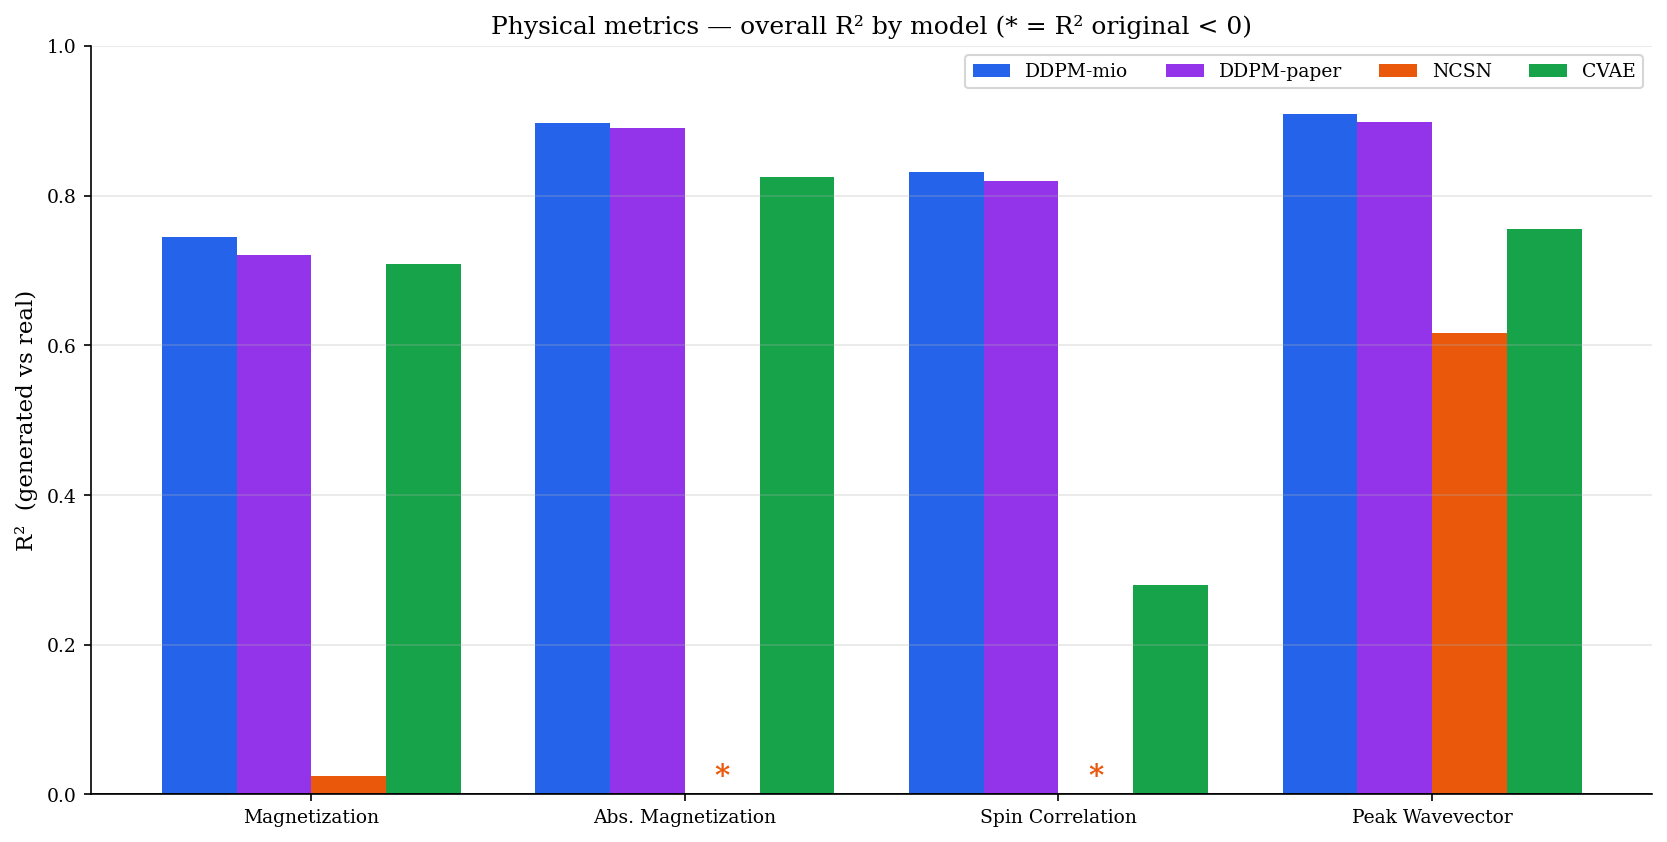

In [11]:
import matplotlib.pyplot as plt
n_mdl = len(present)

def clip_neg(v):
    return max(0.0, v) if not np.isnan(v) else 0.0

# General
x = np.arange(len(METRICS)); w = 0.8 / n_mdl
fig, ax = plt.subplots(figsize=(11, 5.5))
for i, mdl in enumerate(present):
    raw  = [r2_general[mdl][m] for m in METRICS]
    vals = [clip_neg(v) for v in raw]
    bars = ax.bar(x + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS_LOCAL[mdl])
    for bar, r in zip(bars, raw):
        if not np.isnan(r) and r < 0:
            ax.text(bar.get_x() + bar.get_width()/2, 0.005, "*", ha='center', va='bottom',
                    fontsize=14, color=MODEL_COLORS_LOCAL[mdl], fontweight='bold')
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([METRIC_LABEL[m] for m in METRICS])
ax.set_ylabel("R²  (generated vs real)")
ax.set_ylim(0, max(1.0, ax.get_ylim()[1]))
ax.set_title("Physical metrics — overall R² by model (* = R² original < 0)")
ax.legend(loc="upper right", ncol=min(4, n_mdl)); ax.grid(alpha=.3, axis="y")
save_figure(fig, os.path.join(CACHE_DIR, "fig1_overall_r2"))
plt.show()

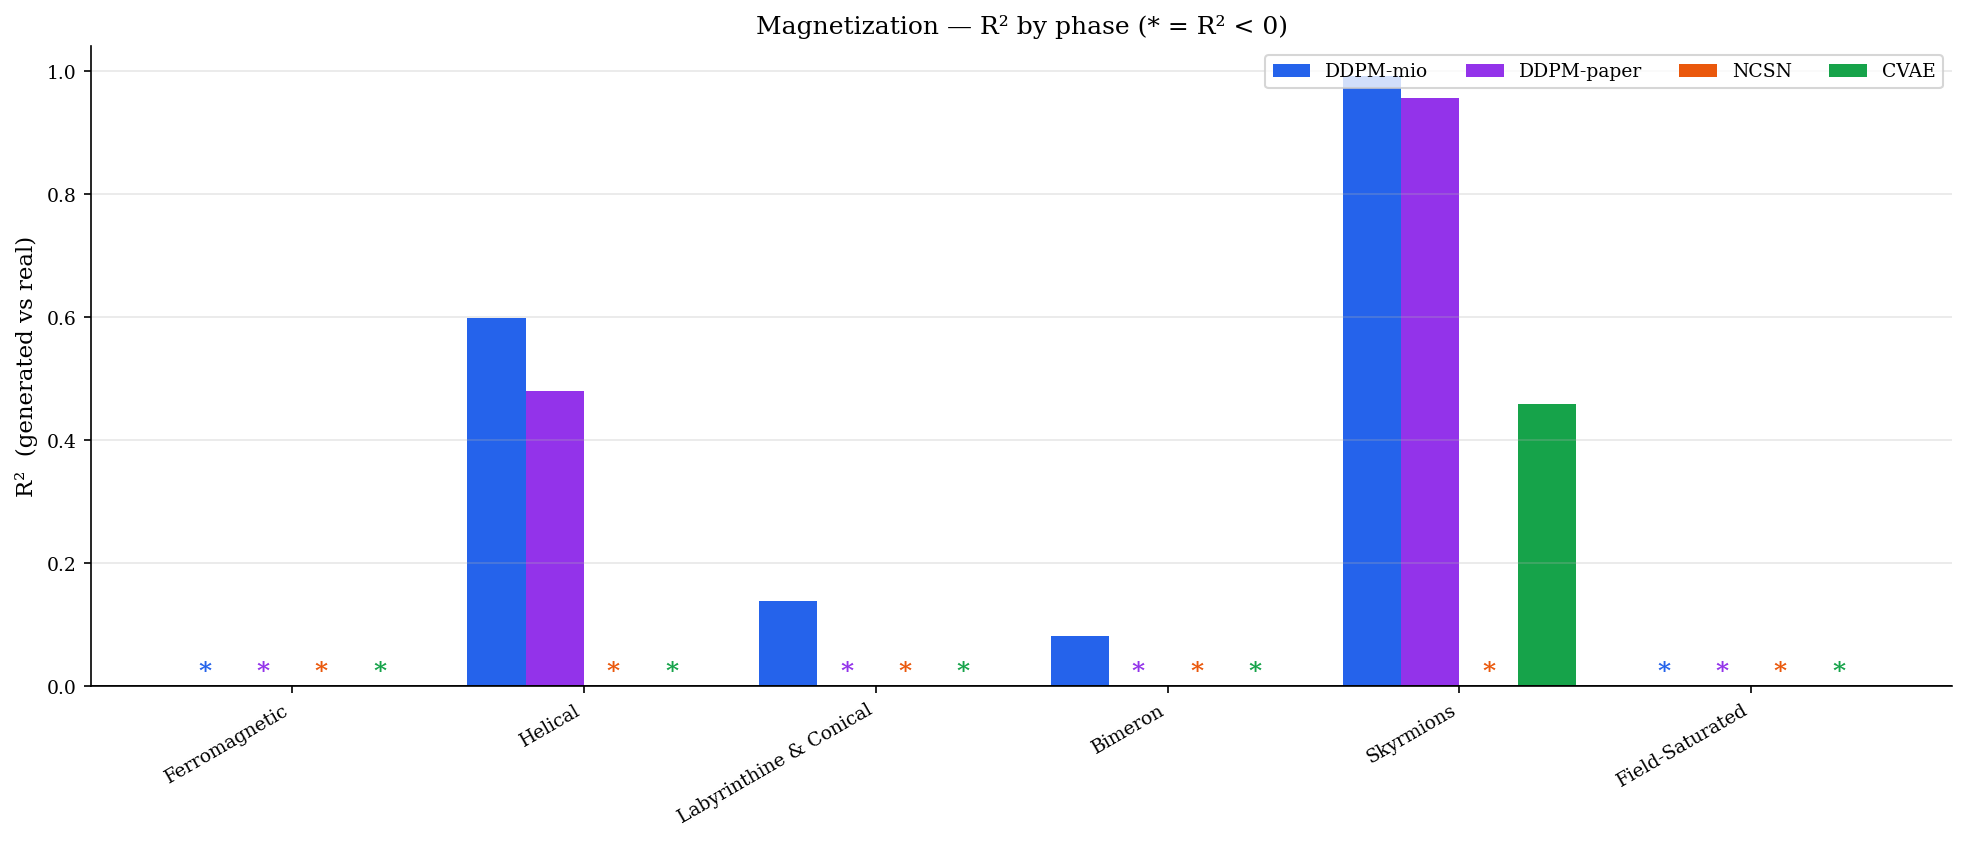

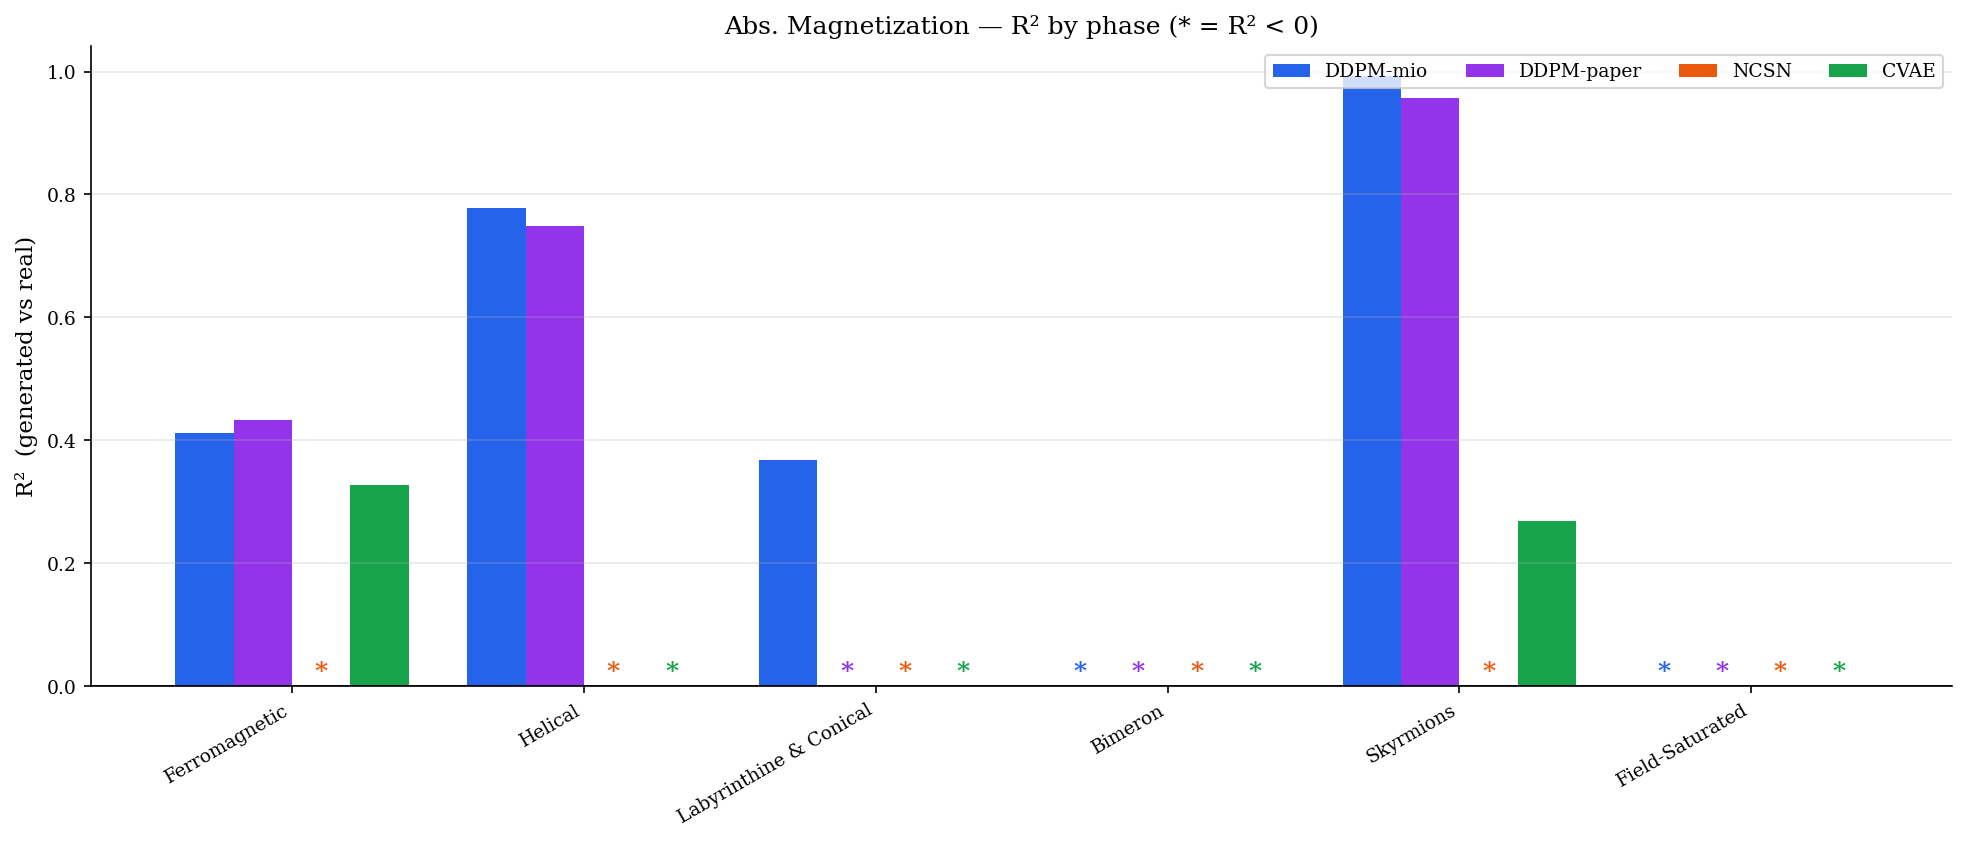

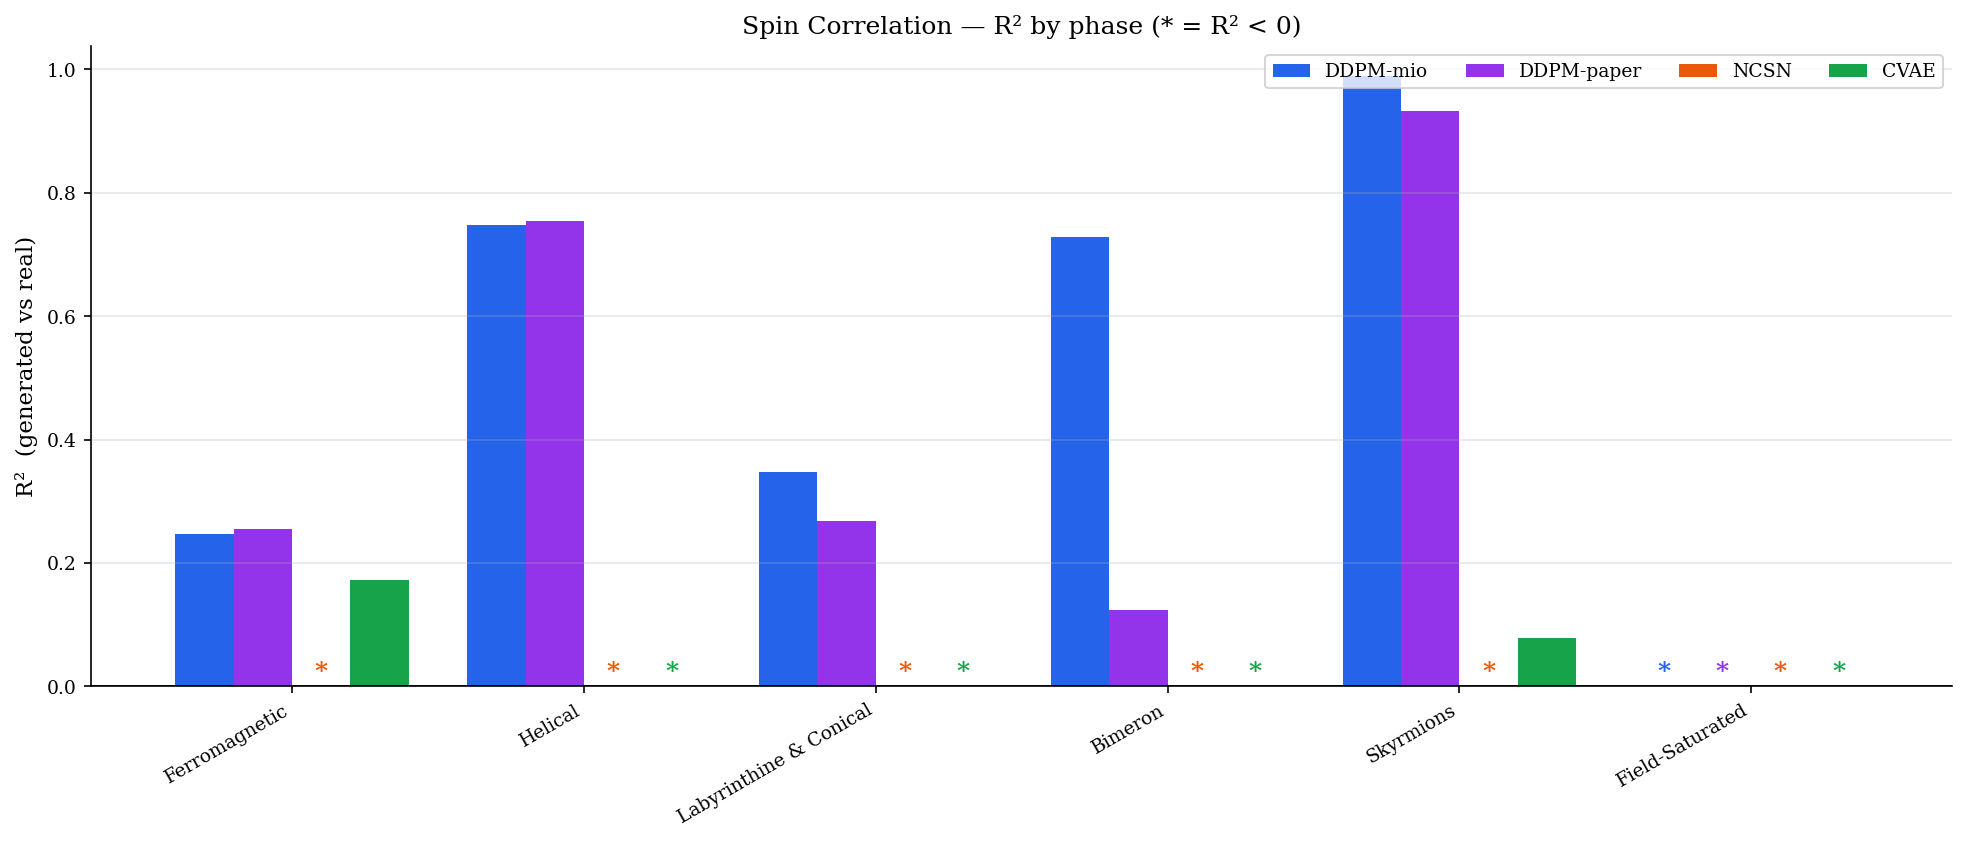

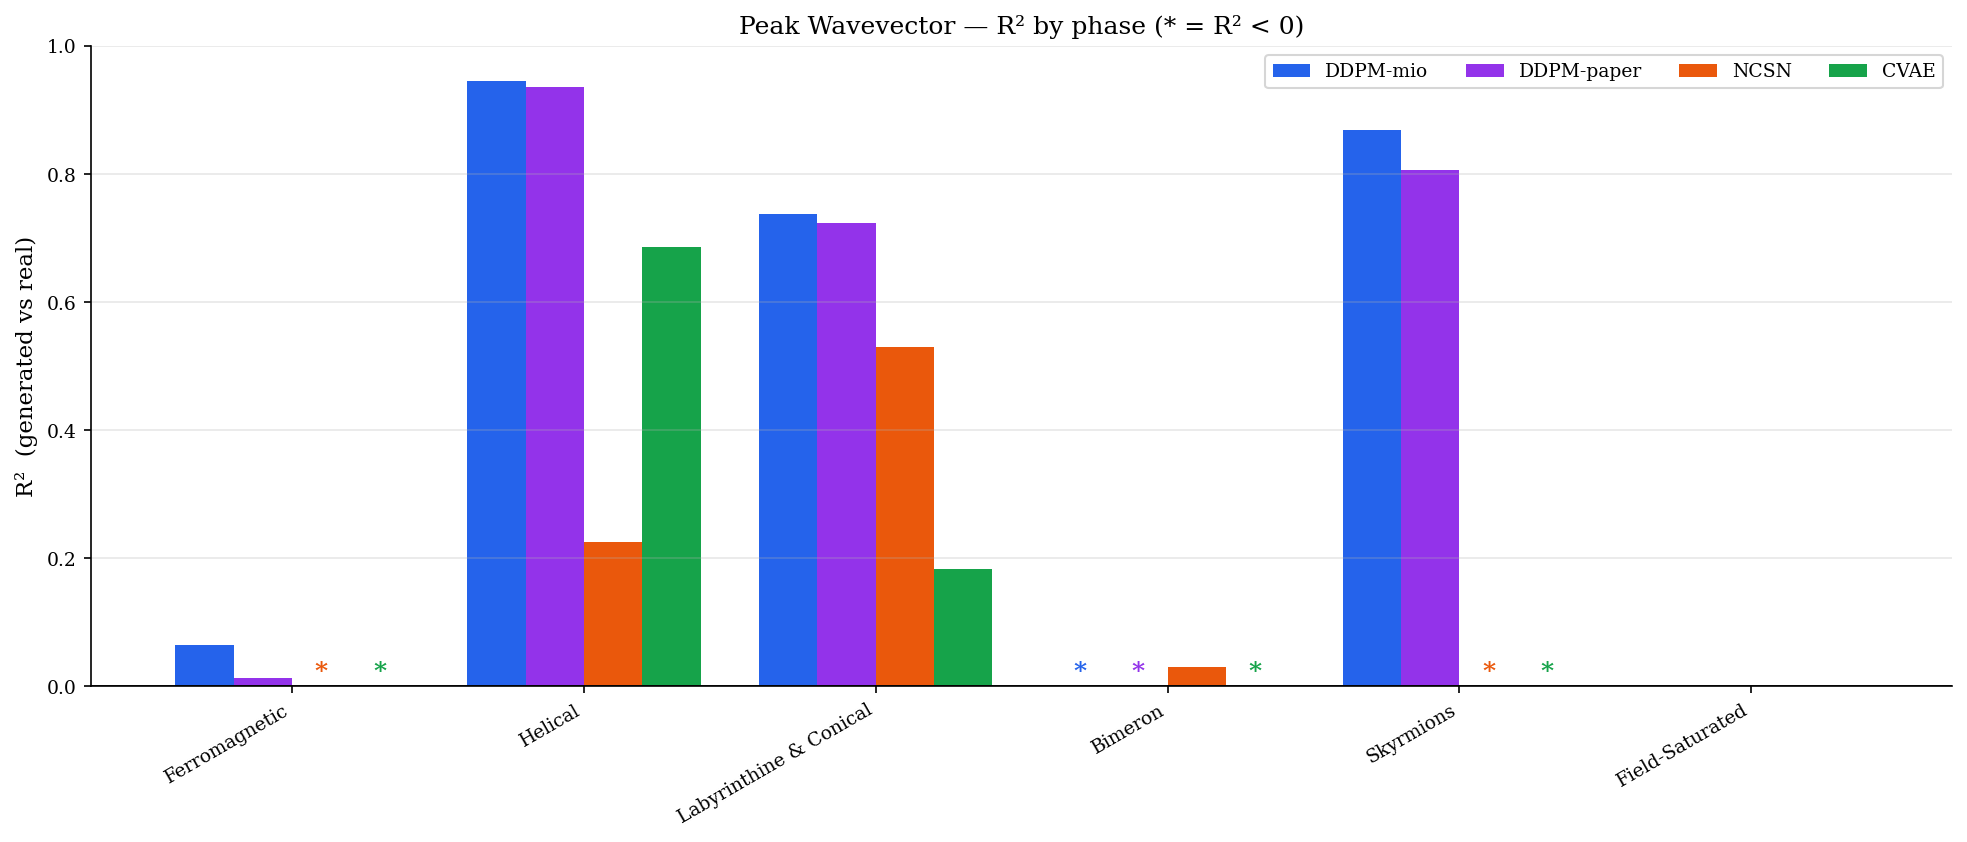

In [12]:
# Por métrica × fase
xph = np.arange(len(STRUCTURE_NAMES)); w = 0.8 / n_mdl
for m in METRICS:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for i, mdl in enumerate(present):
        raw  = [r2_phase[mdl][m][ph] for ph in STRUCTURE_NAMES]
        vals = [clip_neg(v) for v in raw]
        bars = ax.bar(xph + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS_LOCAL[mdl])
        for bar, r in zip(bars, raw):
            if not np.isnan(r) and r < 0:
                ax.text(bar.get_x() + bar.get_width()/2, 0.005, "*", ha='center', va='bottom',
                        fontsize=12, color=MODEL_COLORS_LOCAL[mdl], fontweight='bold')
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(xph); ax.set_xticklabels(STRUCTURE_NAMES, rotation=30, ha="right")
    ax.set_ylabel("R²  (generated vs real)")
    ax.set_ylim(0, max(1.0, ax.get_ylim()[1]))
    ax.set_title(f"{METRIC_LABEL[m]} — R² by phase (* = R² < 0)")
    ax.legend(loc="upper right", ncol=min(4, n_mdl)); ax.grid(alpha=.3, axis="y")
    save_figure(fig, os.path.join(CACHE_DIR, f"fig_{m}_r2_by_phase"))
    plt.show()

## 7. Figuras MAE (5 figs: 1 general + 4 por métrica)

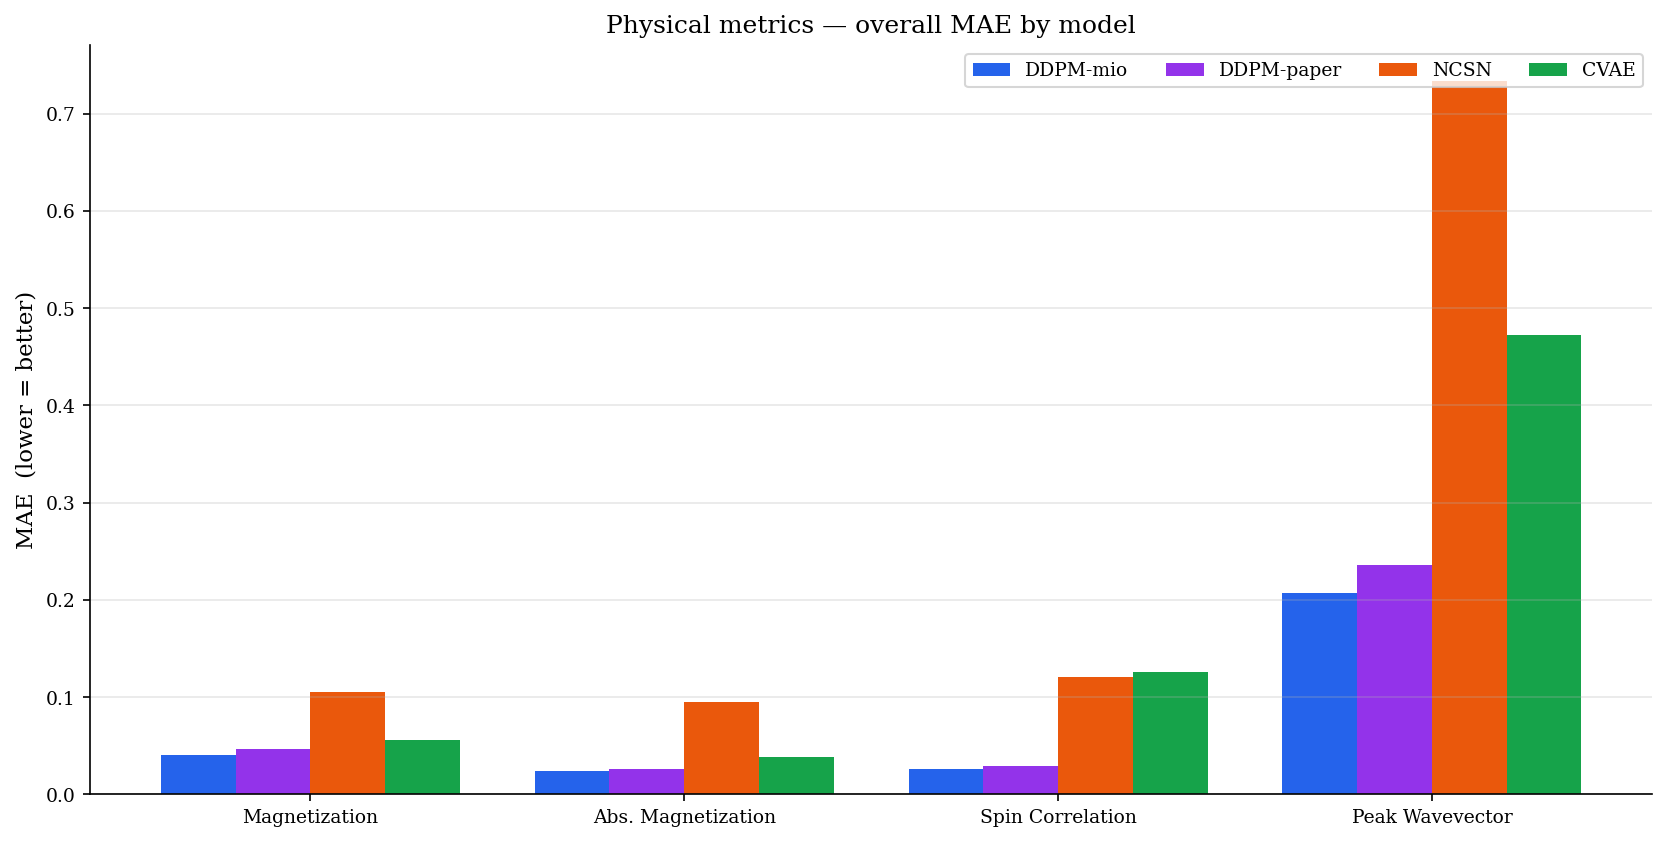

In [13]:
x = np.arange(len(METRICS)); w = 0.8 / n_mdl
fig, ax = plt.subplots(figsize=(11, 5.5))
for i, mdl in enumerate(present):
    vals = [mae_general[mdl][m] for m in METRICS]
    ax.bar(x + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS_LOCAL[mdl])
ax.set_xticks(x); ax.set_xticklabels([METRIC_LABEL[m] for m in METRICS])
ax.set_ylabel("MAE  (lower = better)")
ax.set_title("Physical metrics — overall MAE by model")
ax.legend(loc="upper right", ncol=min(4, n_mdl)); ax.grid(alpha=.3, axis="y")
save_figure(fig, os.path.join(CACHE_DIR, "fig1_overall_mae"))
plt.show()

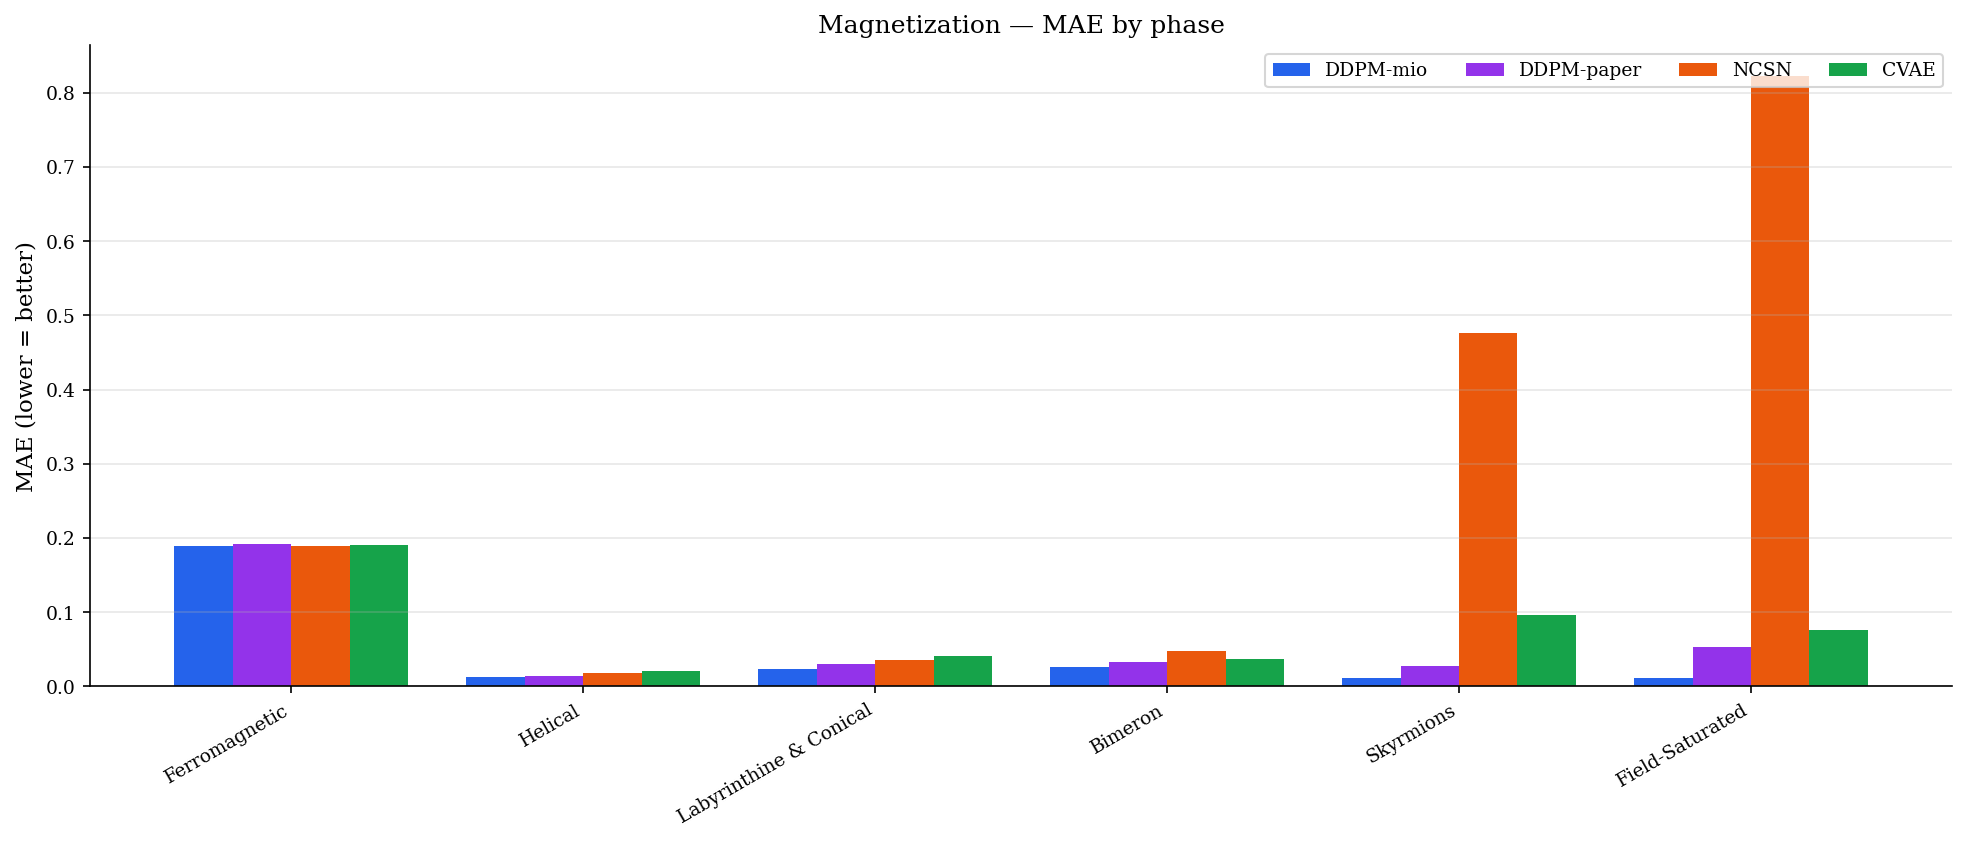

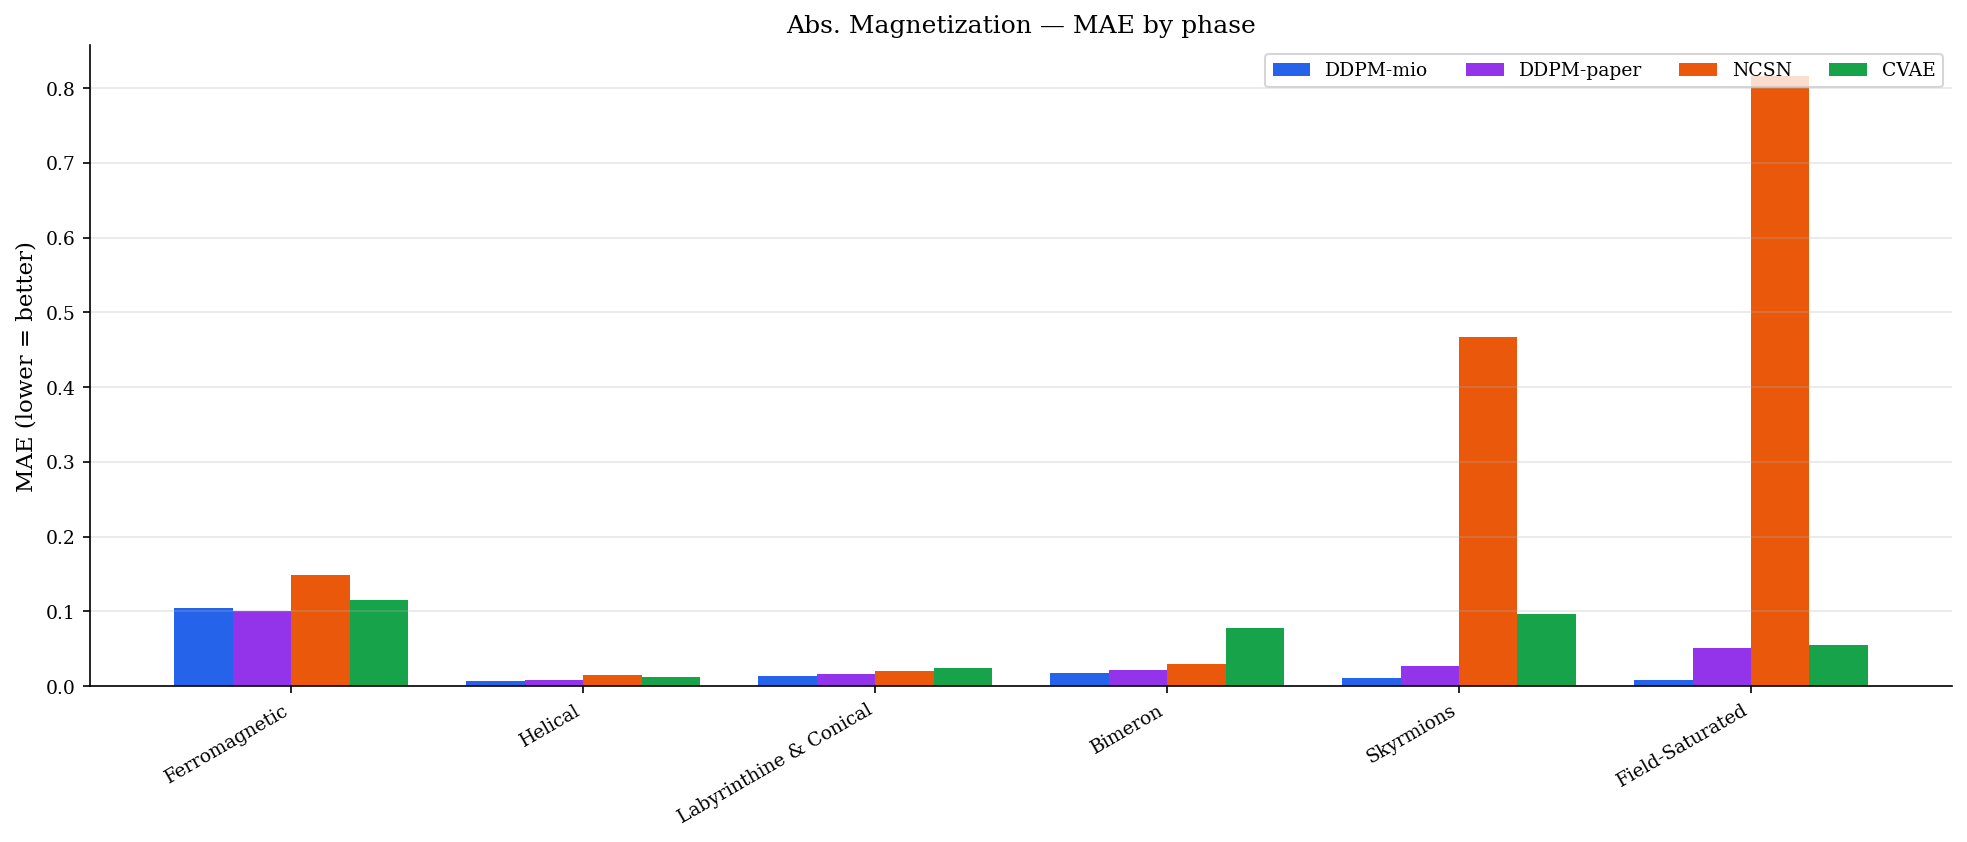

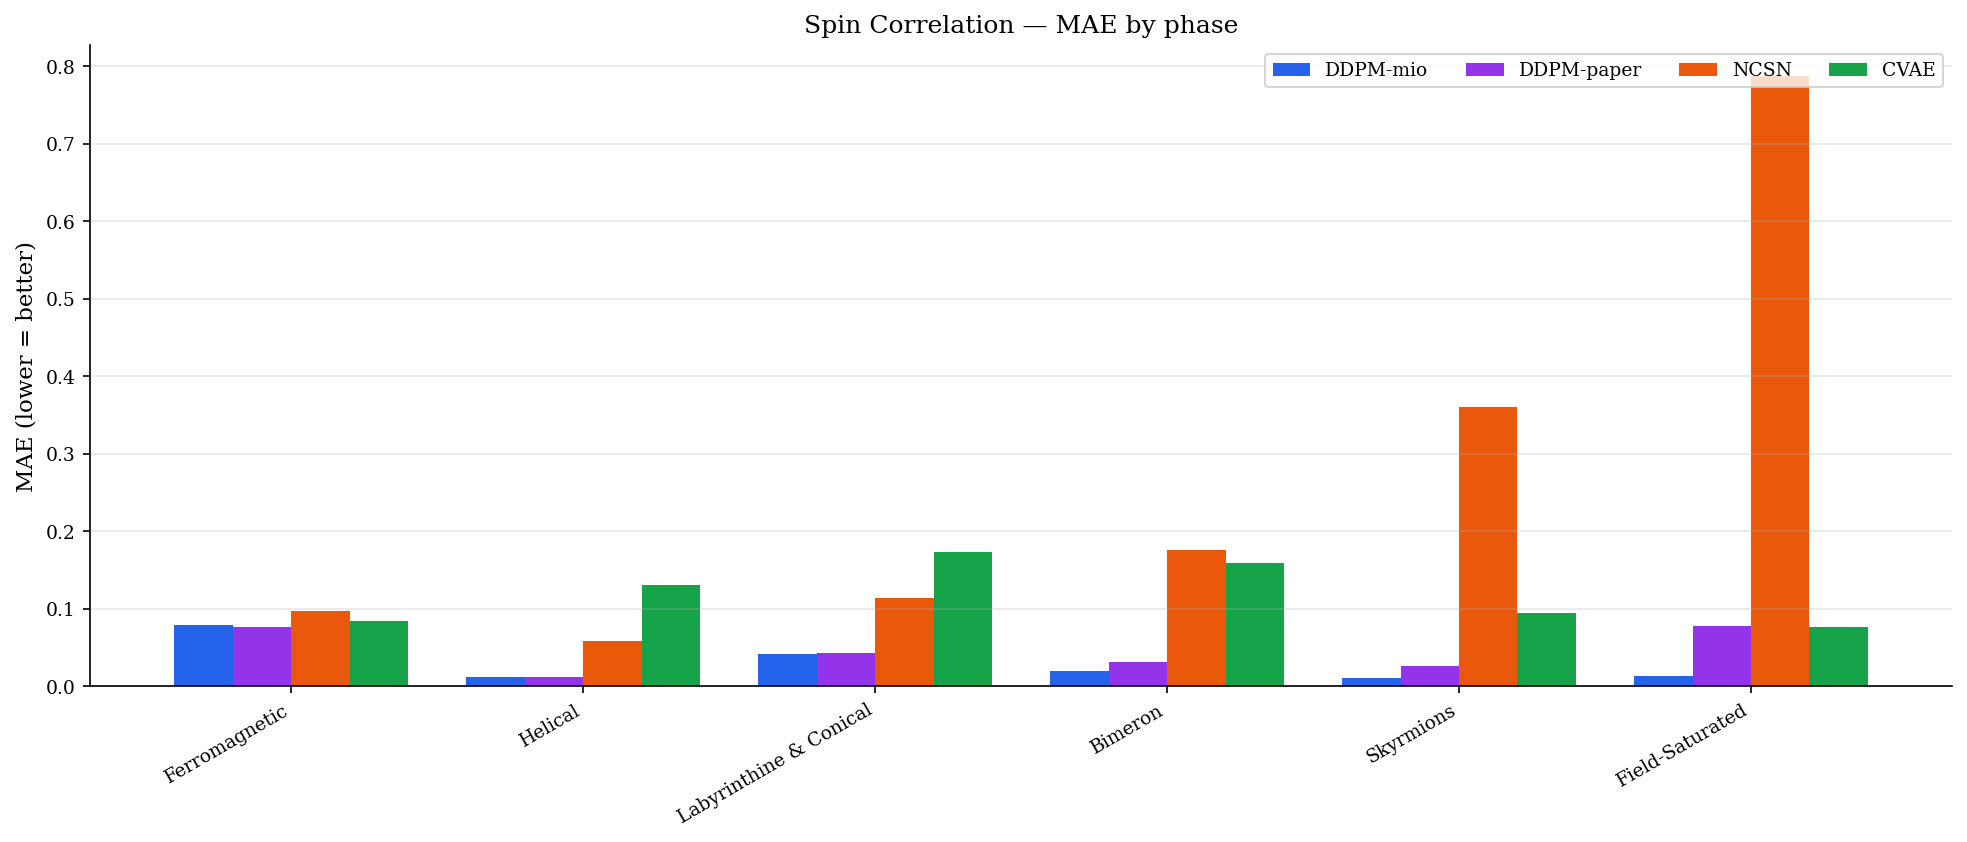

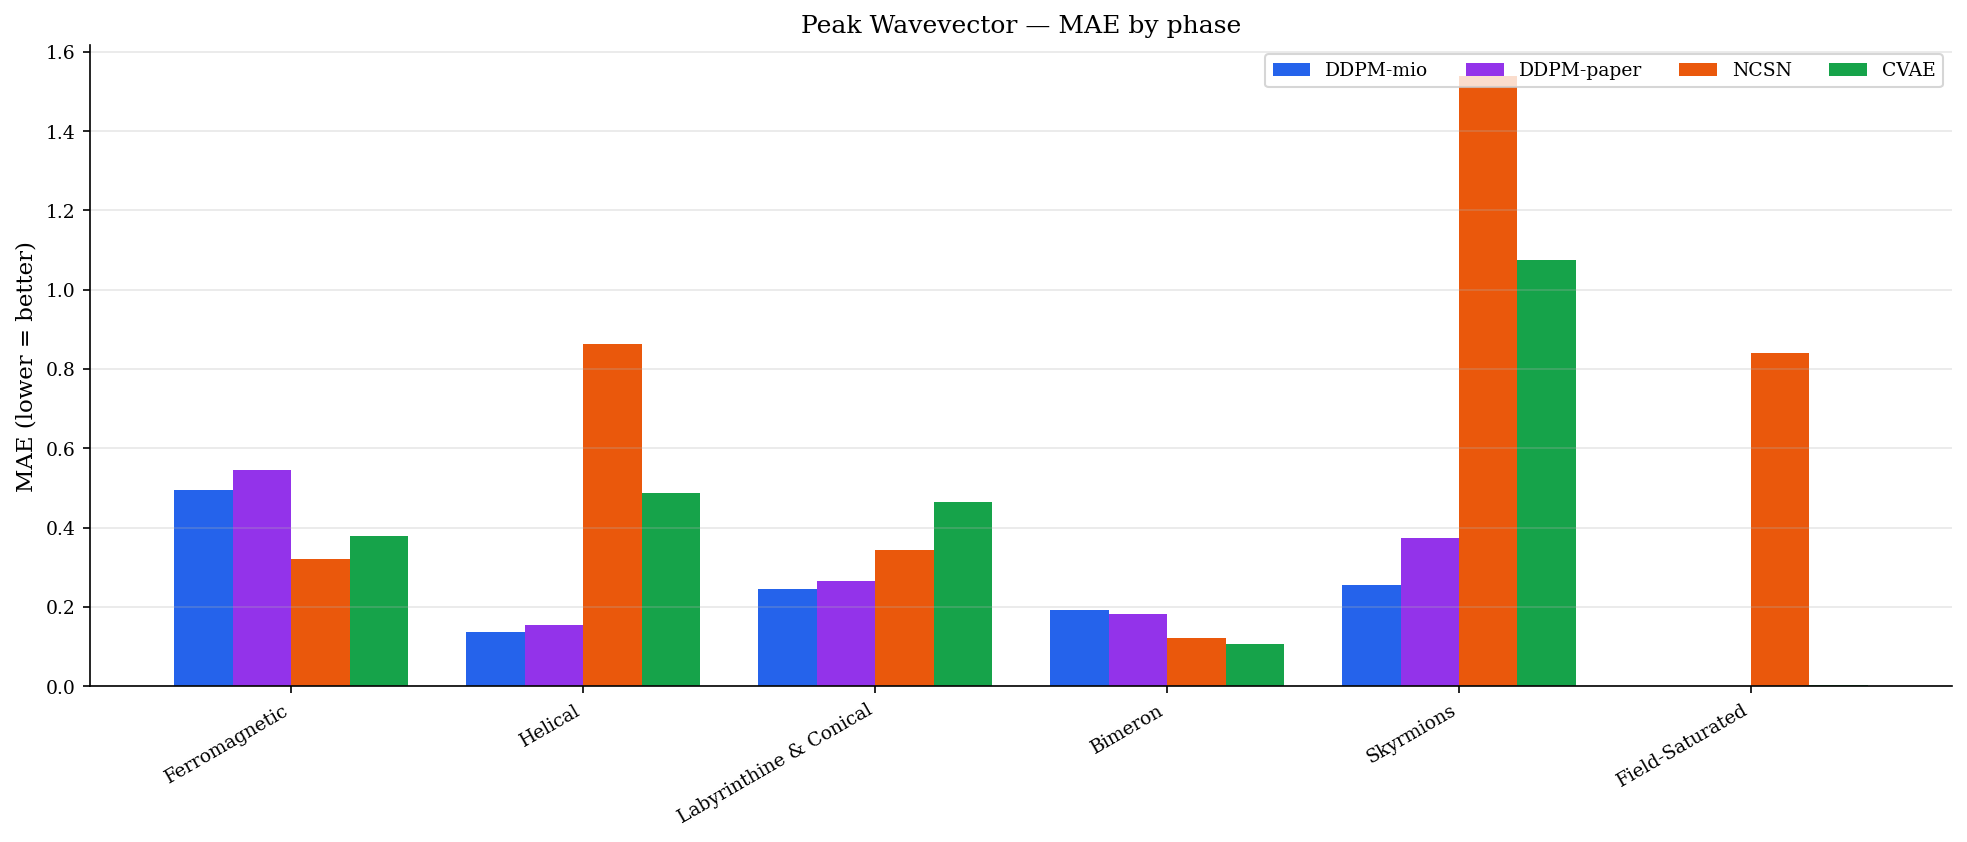

In [14]:
for m in METRICS:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for i, mdl in enumerate(present):
        vals = [mae_phase[mdl][m][ph] for ph in STRUCTURE_NAMES]
        ax.bar(xph + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS_LOCAL[mdl])
    ax.set_xticks(xph); ax.set_xticklabels(STRUCTURE_NAMES, rotation=30, ha="right")
    ax.set_ylabel("MAE (lower = better)")
    ax.set_title(f"{METRIC_LABEL[m]} — MAE by phase")
    ax.legend(loc="upper right", ncol=min(4, n_mdl)); ax.grid(alpha=.3, axis="y")
    save_figure(fig, os.path.join(CACHE_DIR, f"fig_{m}_mae_by_phase"))
    plt.show()

## 8. Tabla comparativa + CSV

In [15]:
import pandas as pd
rows = []
for mdl in present:
    for m in METRICS:
        rows.append({"model": mdl, "metric": METRIC_LABEL[m], "phase": "ALL",
                     "r2": r2_general[mdl][m], "mae": mae_general[mdl][m]})
        for ph in STRUCTURE_NAMES:
            rows.append({"model": mdl, "metric": METRIC_LABEL[m], "phase": ph,
                         "r2": r2_phase[mdl][m][ph], "mae": mae_phase[mdl][m][ph]})
df = pd.DataFrame(rows)
csv_path = os.path.join(CACHE_DIR, f"physical_metrics_r2_mae_N{n_theta}.csv")
df.to_csv(csv_path, index=False)
print(f"CSV: {csv_path}  ({len(df)} filas)")

print("\n=== RESUMEN GENERAL (phase=ALL) ===")
pivot = df[df['phase'] == 'ALL'].pivot_table(index='model', columns='metric', values=['r2', 'mae'])
print(pivot.round(4))

print("\n=== Ranking por R² promedio ===")
mean_r2 = {mdl: np.nanmean([r2_general[mdl][m] for m in METRICS]) for mdl in present}
mean_mae = {mdl: np.nanmean([mae_general[mdl][m] for m in METRICS]) for mdl in present}
ranking = sorted(present, key=lambda mdl: -mean_r2[mdl])
for i, mdl in enumerate(ranking, 1):
    print(f"  {i}. {mdl:12s}  R²={mean_r2[mdl]:+.3f}  MAE={mean_mae[mdl]:.4f}")

CSV: /kaggle/working/eval_cache/physical_metrics_r2_mae_N1000.csv  (112 filas)

=== RESUMEN GENERAL (phase=ALL) ===
                          mae                                                 \
metric     Abs. Magnetization Magnetization Peak Wavevector Spin Correlation   
model                                                                          
CVAE                   0.0385        0.0558          0.4721           0.1254   
DDPM-mio               0.0237        0.0409          0.2076           0.0258   
DDPM-paper             0.0266        0.0462          0.2362           0.0296   
NCSN                   0.0945        0.1054          0.7340           0.1208   

                           r2                                                 
metric     Abs. Magnetization Magnetization Peak Wavevector Spin Correlation  
model                                                                         
CVAE                   0.8256        0.7084          0.7554           0.2794  
DDPM-mi

## 9. Comparativa visual: `N_GRIDS` grillas 5×6

Cada grilla usa un `PICK_SEED` distinto → muestras diferentes por estructura. Cada modelo
generó su batch visual en su etapa (no se vuelve a cargar). El título de cada figura indica
el `PICK_SEED` y los `idx` para que puedas reproducir la grilla que más te guste.

In [16]:
from matplotlib.colors import Normalize

# Cargar caches visuales
gens_visual = {label: {g: {} for g in range(N_GRIDS)} for label in ROW_LABELS}
for (grid_id, ph), (idx, _, real_img) in selected_visual.items():
    gens_visual["Original"][grid_id][ph] = real_img.astype(np.float32)  # ya en [-1, 1]

for mdl in MODELS:
    v_cache = os.path.join(CACHE_DIR, f"gen_visual_{mdl}_G{N_GRIDS}.npz")
    if not os.path.exists(v_cache):
        print(f"FALTA visual cache de {mdl}")
        continue
    arr = np.load(v_cache)["imgs"]  # (N_GRIDS, 6, 39, 39)
    for g in range(N_GRIDS):
        for j, ph in enumerate(STRUCTURE_NAMES):
            gens_visual[mdl][g][ph] = arr[g, j]

active_rows = [r for r in ROW_LABELS if r == "Original" or r in [mdl for mdl in MODELS if mdl in gen_by_model]]
n_rows, n_cols = len(active_rows), len(STRUCTURE_NAMES)
print(f"Grilla visual: {n_rows} filas × {n_cols} cols  ({N_GRIDS} grids)")

Grilla visual: 5 filas × 6 cols  (10 grids)


/tmp/ipykernel_24/3672105887.py:30: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.08, right=0.91, top=0.93, bottom=0.04)


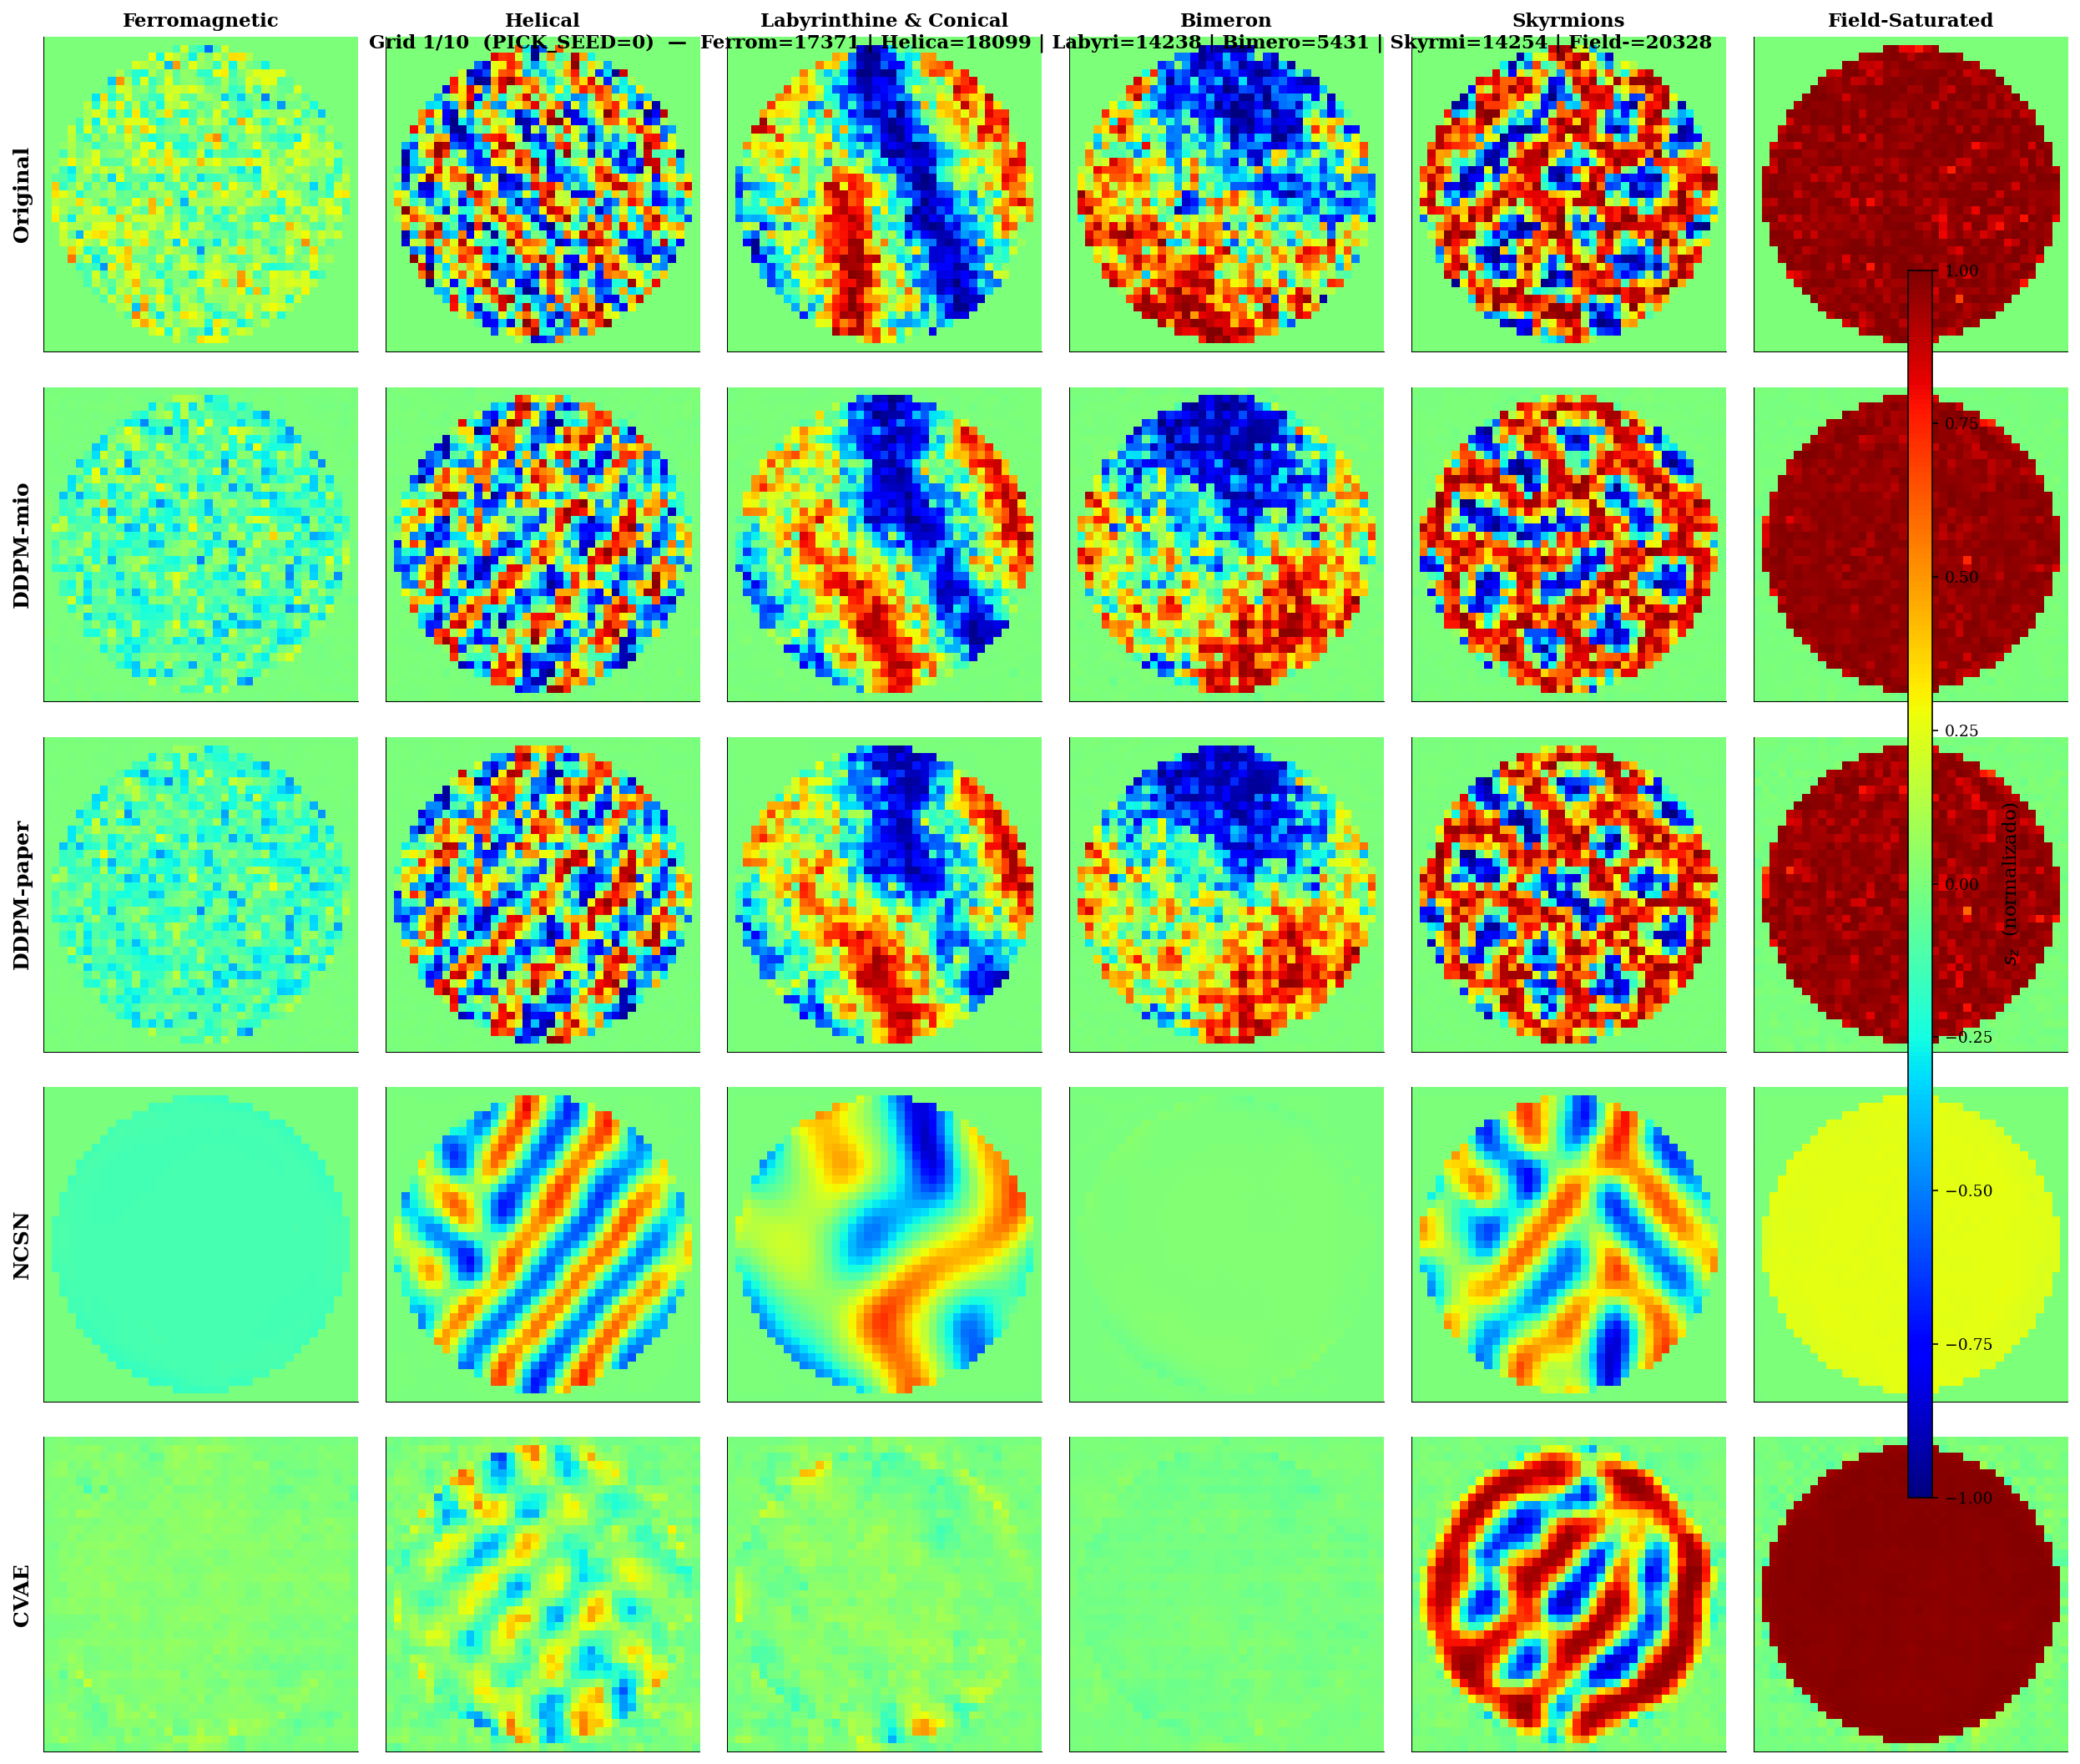

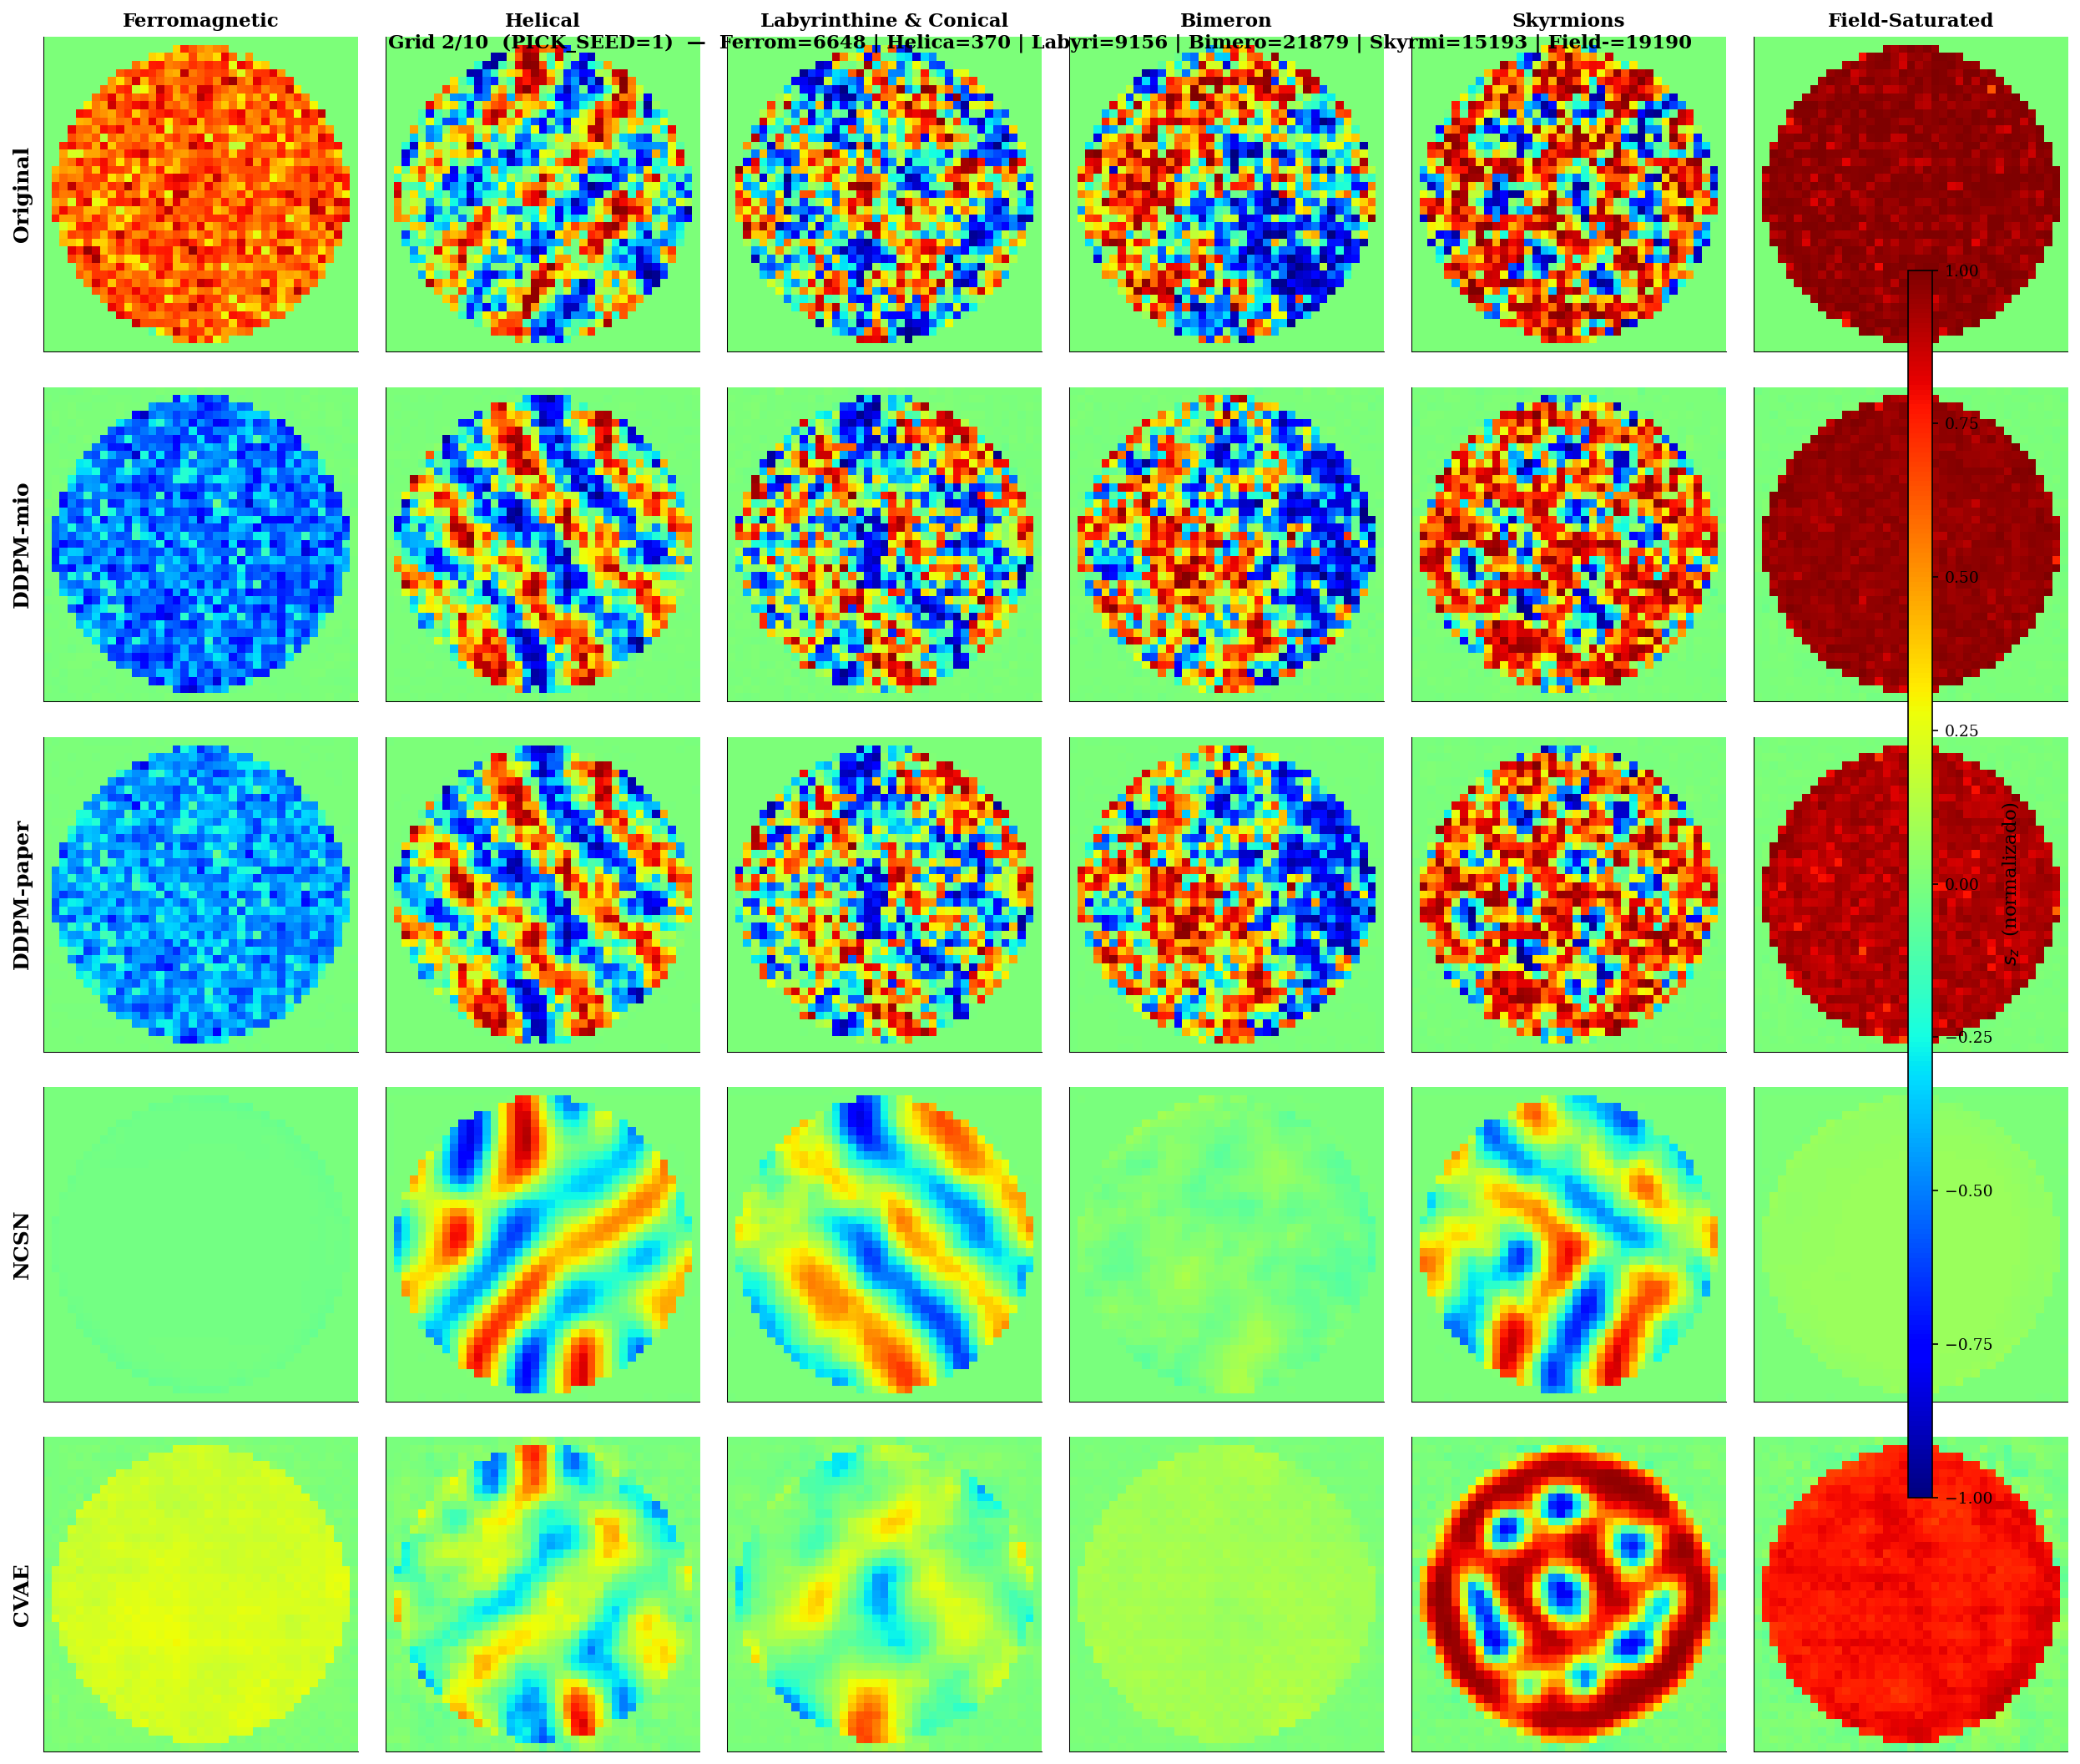

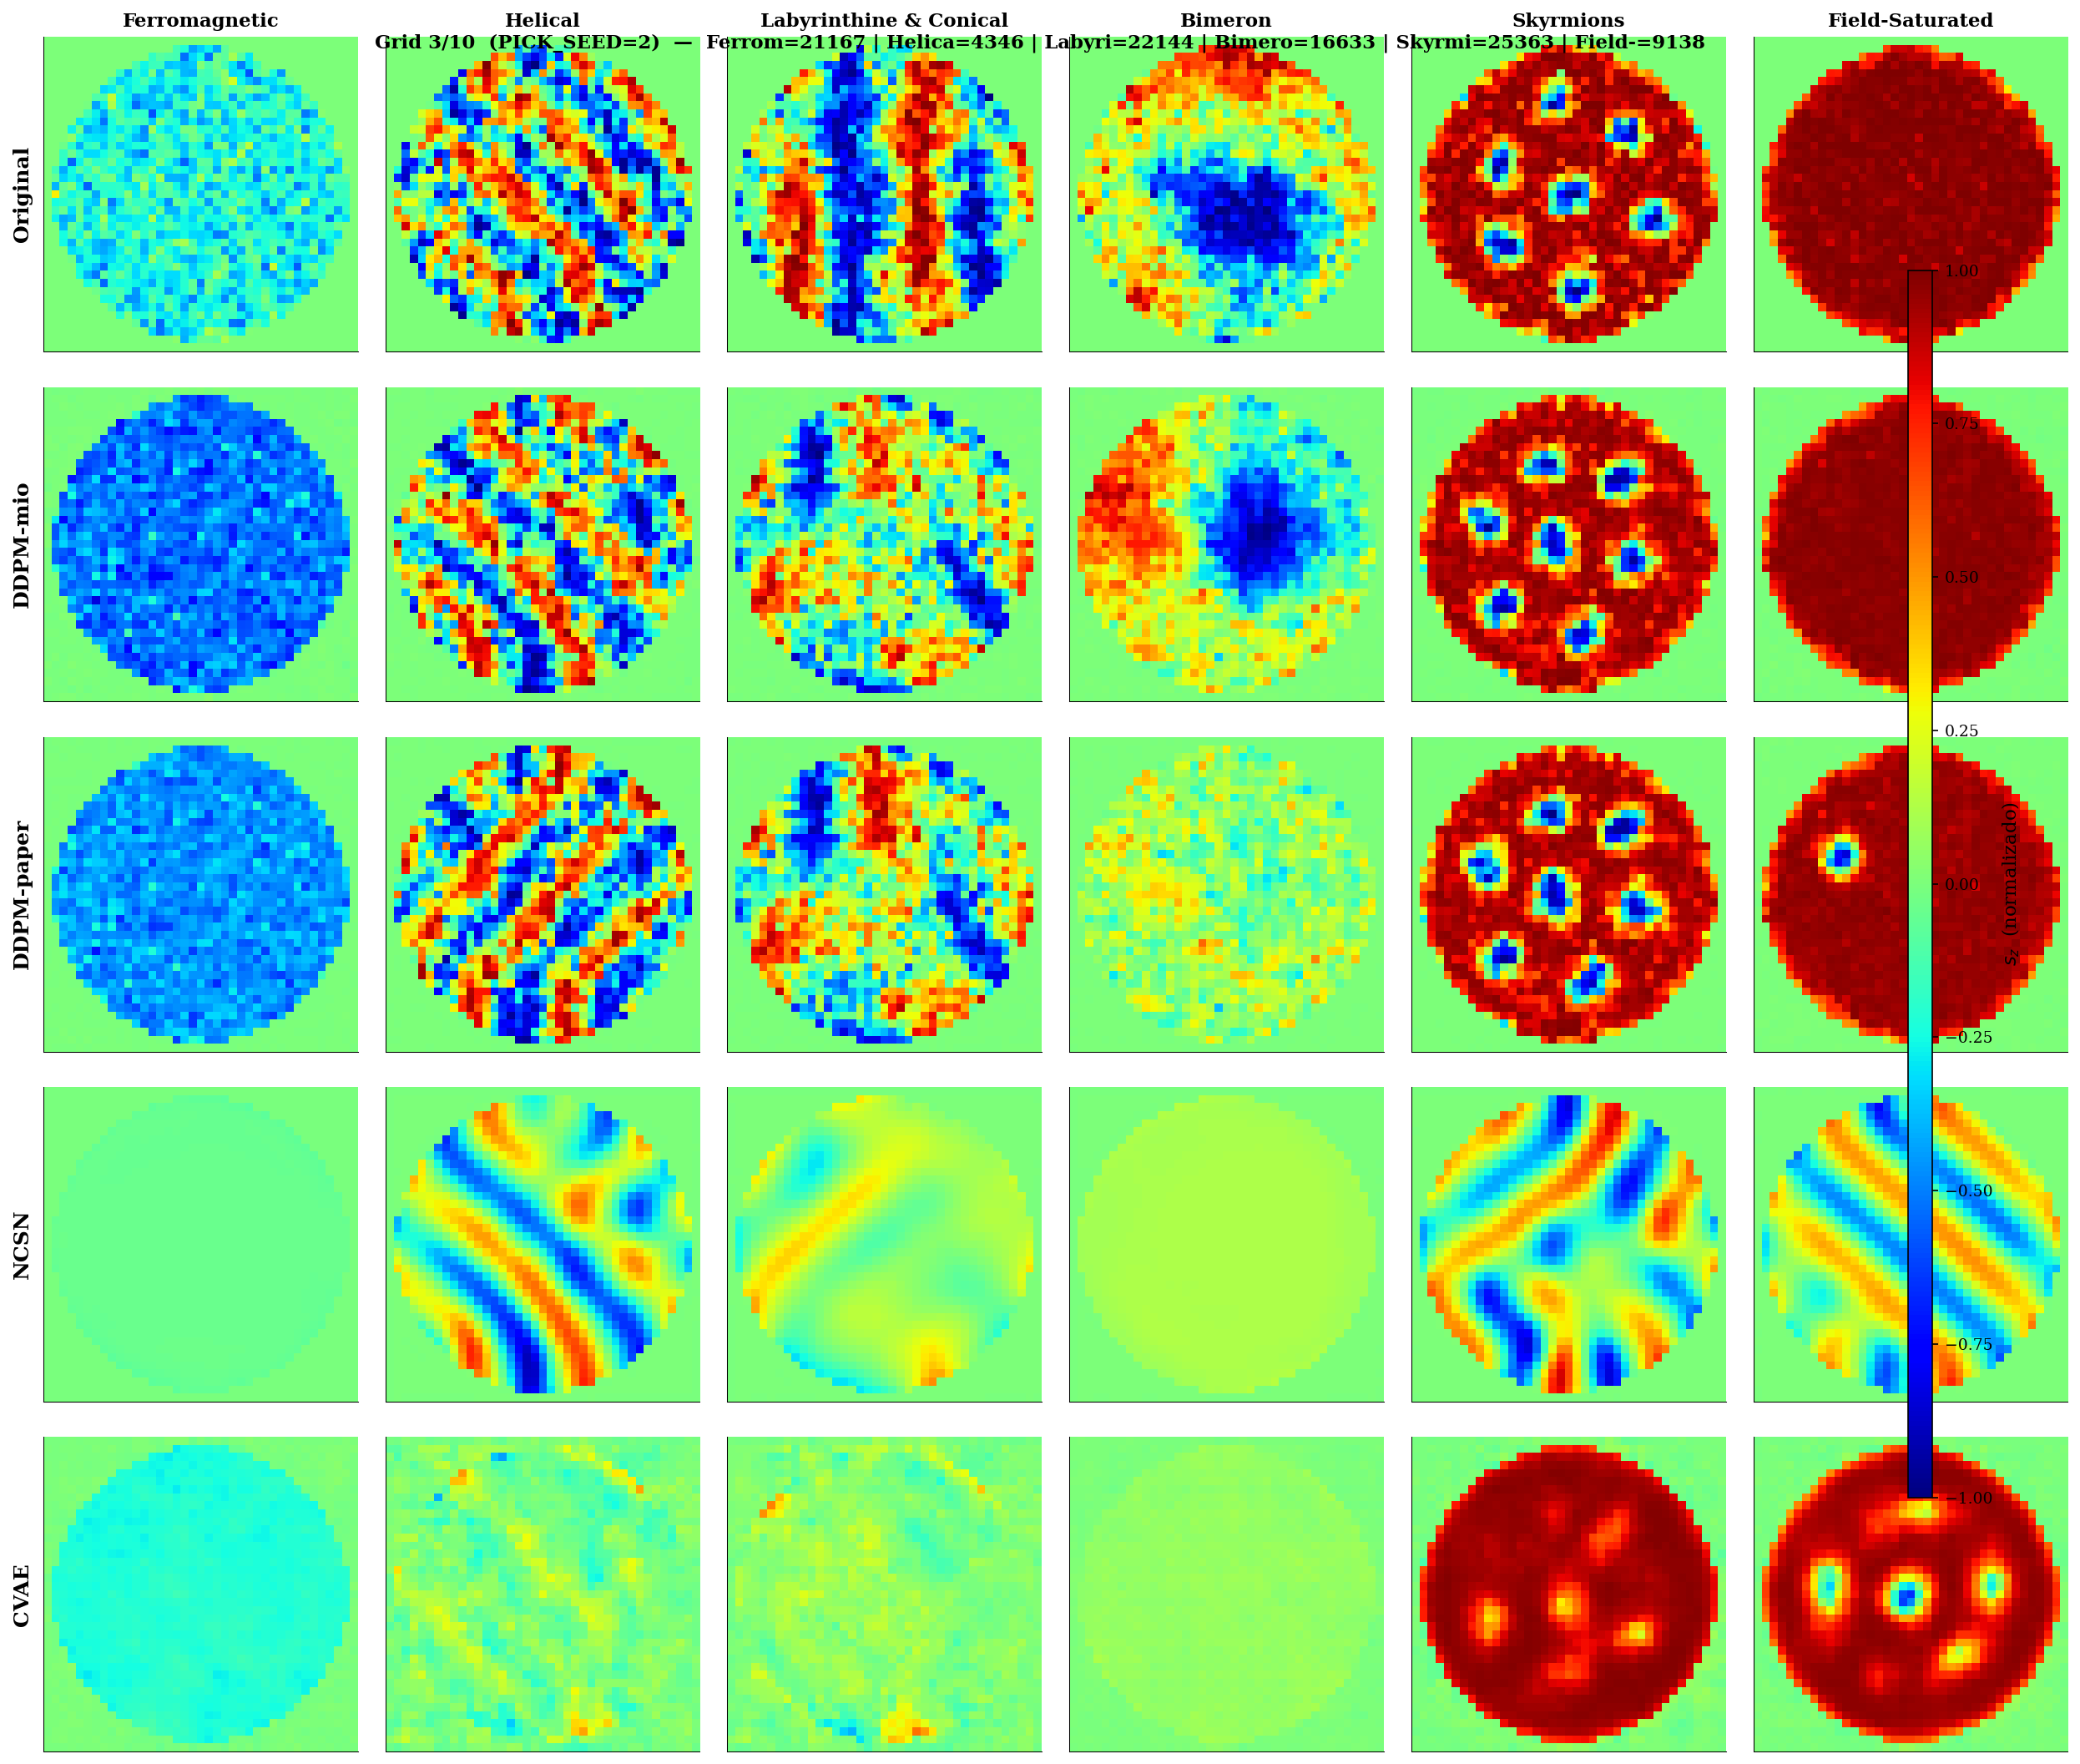

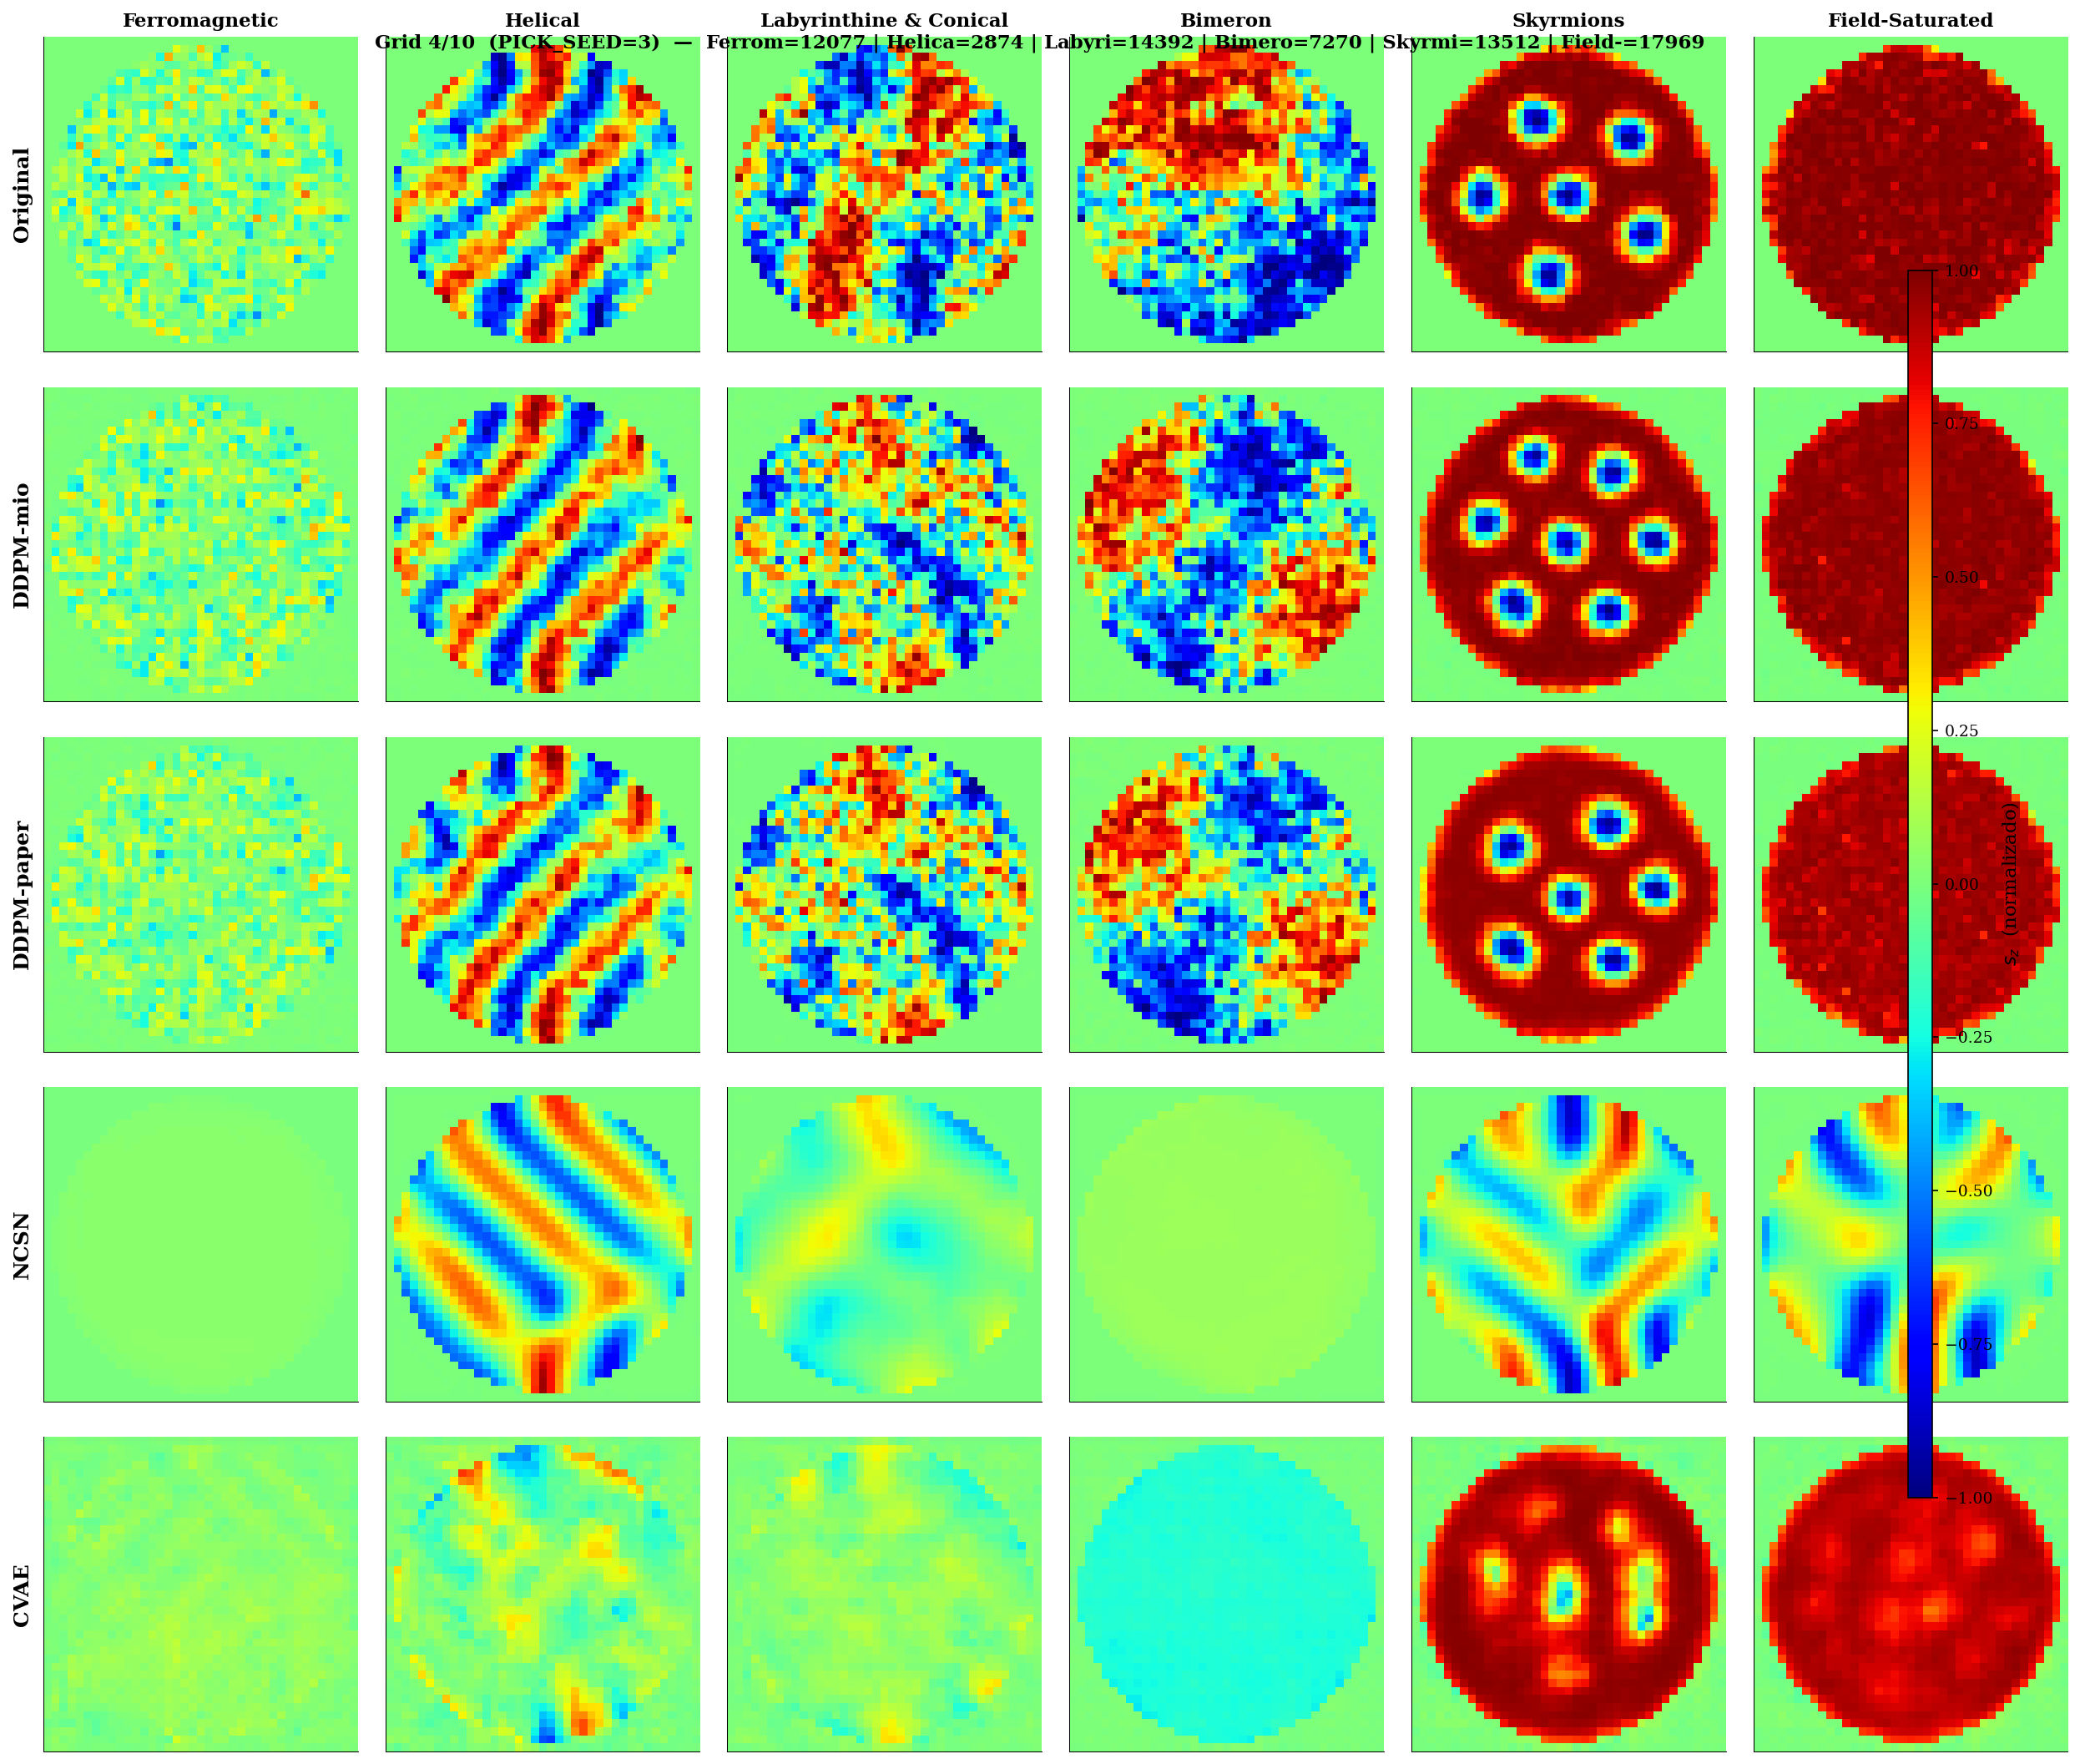

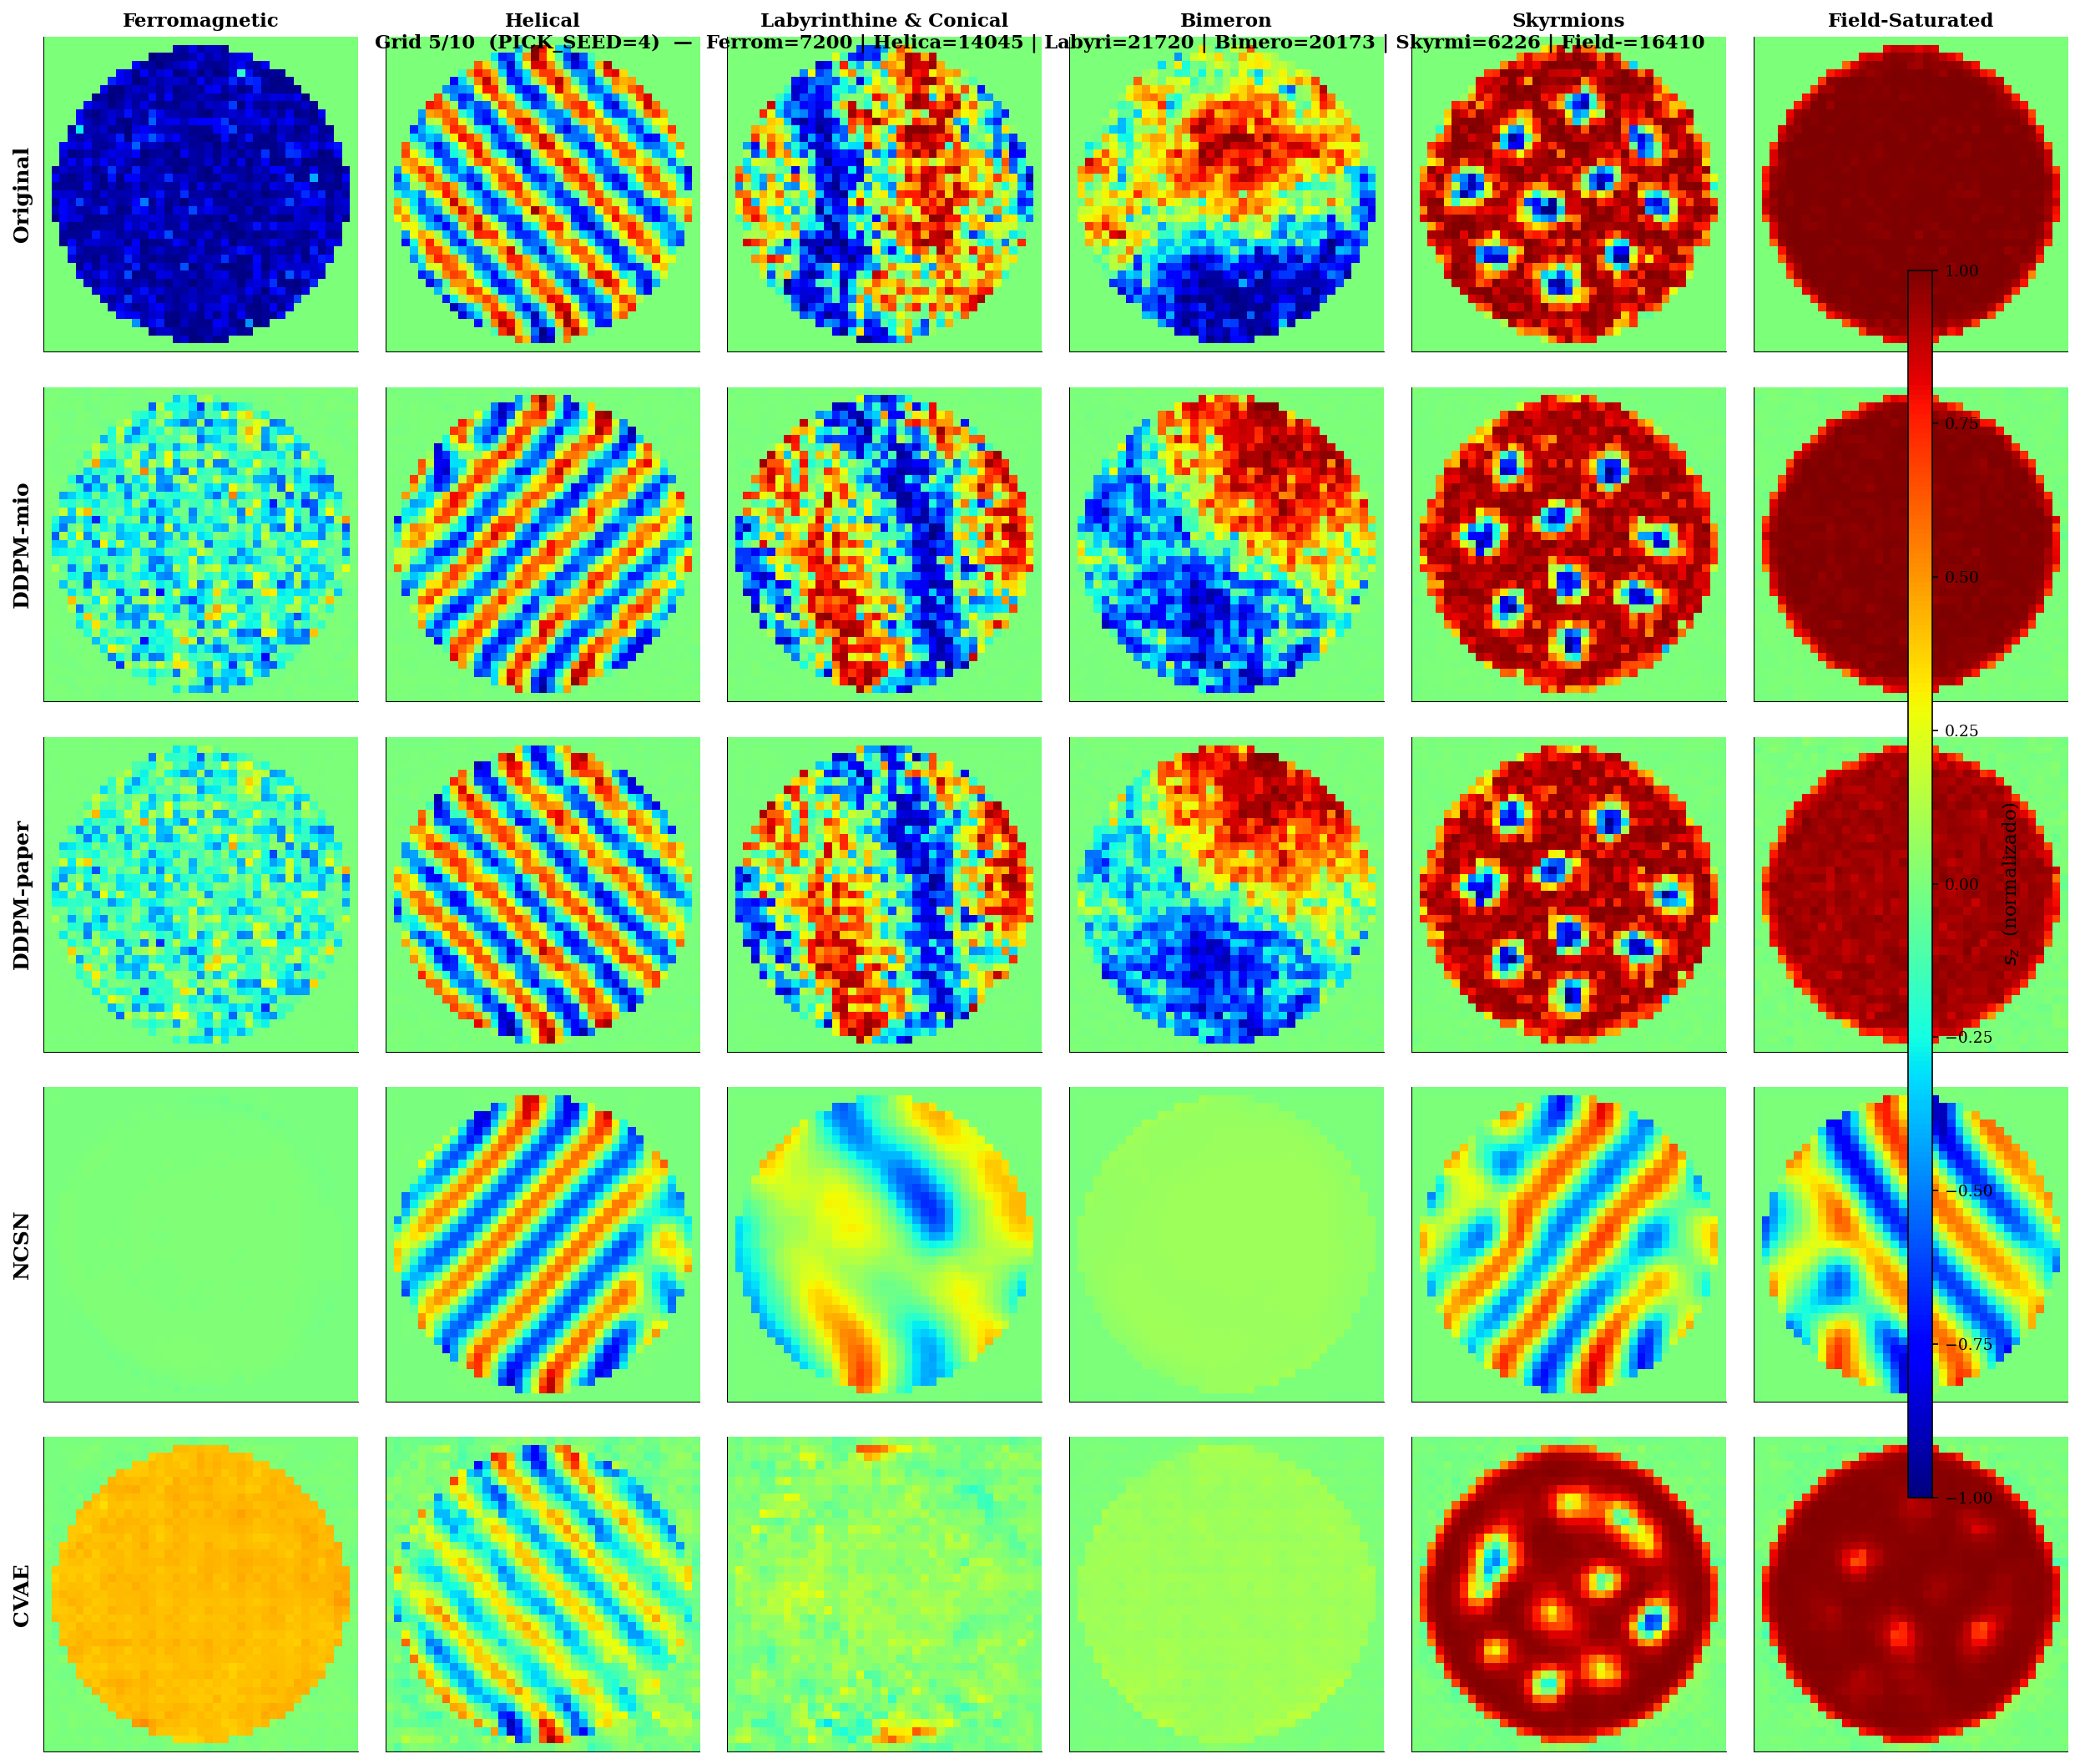

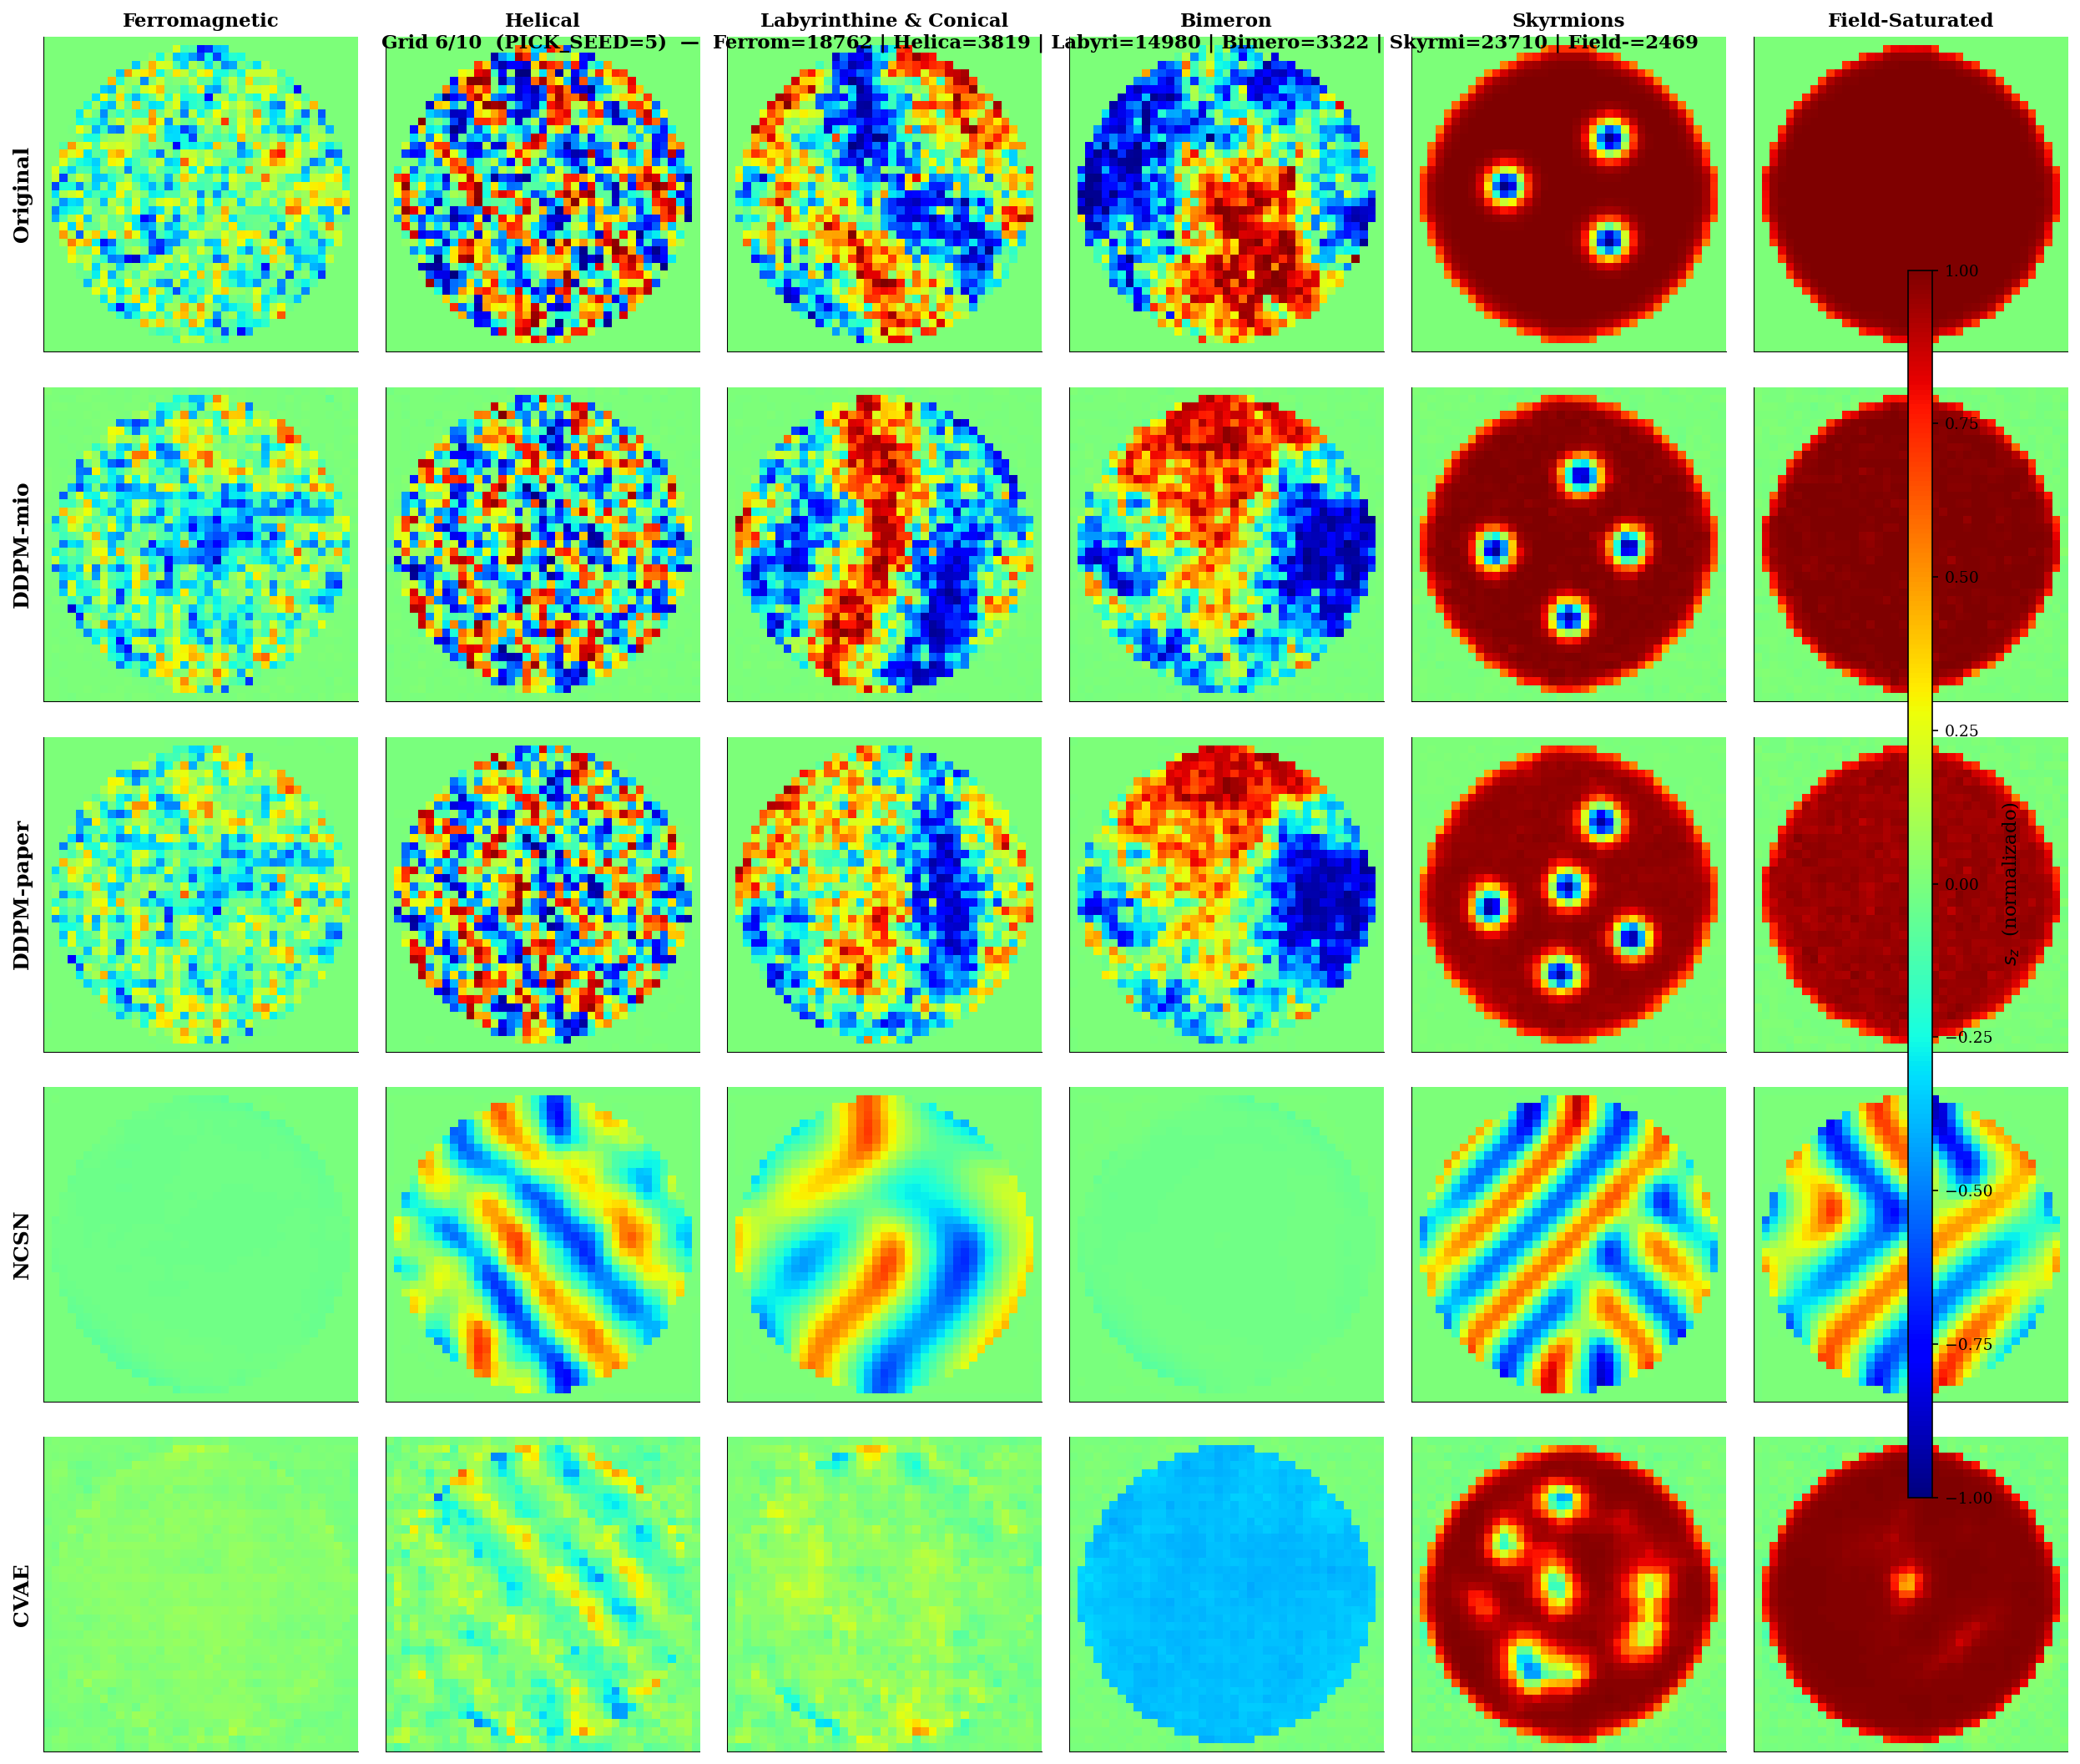

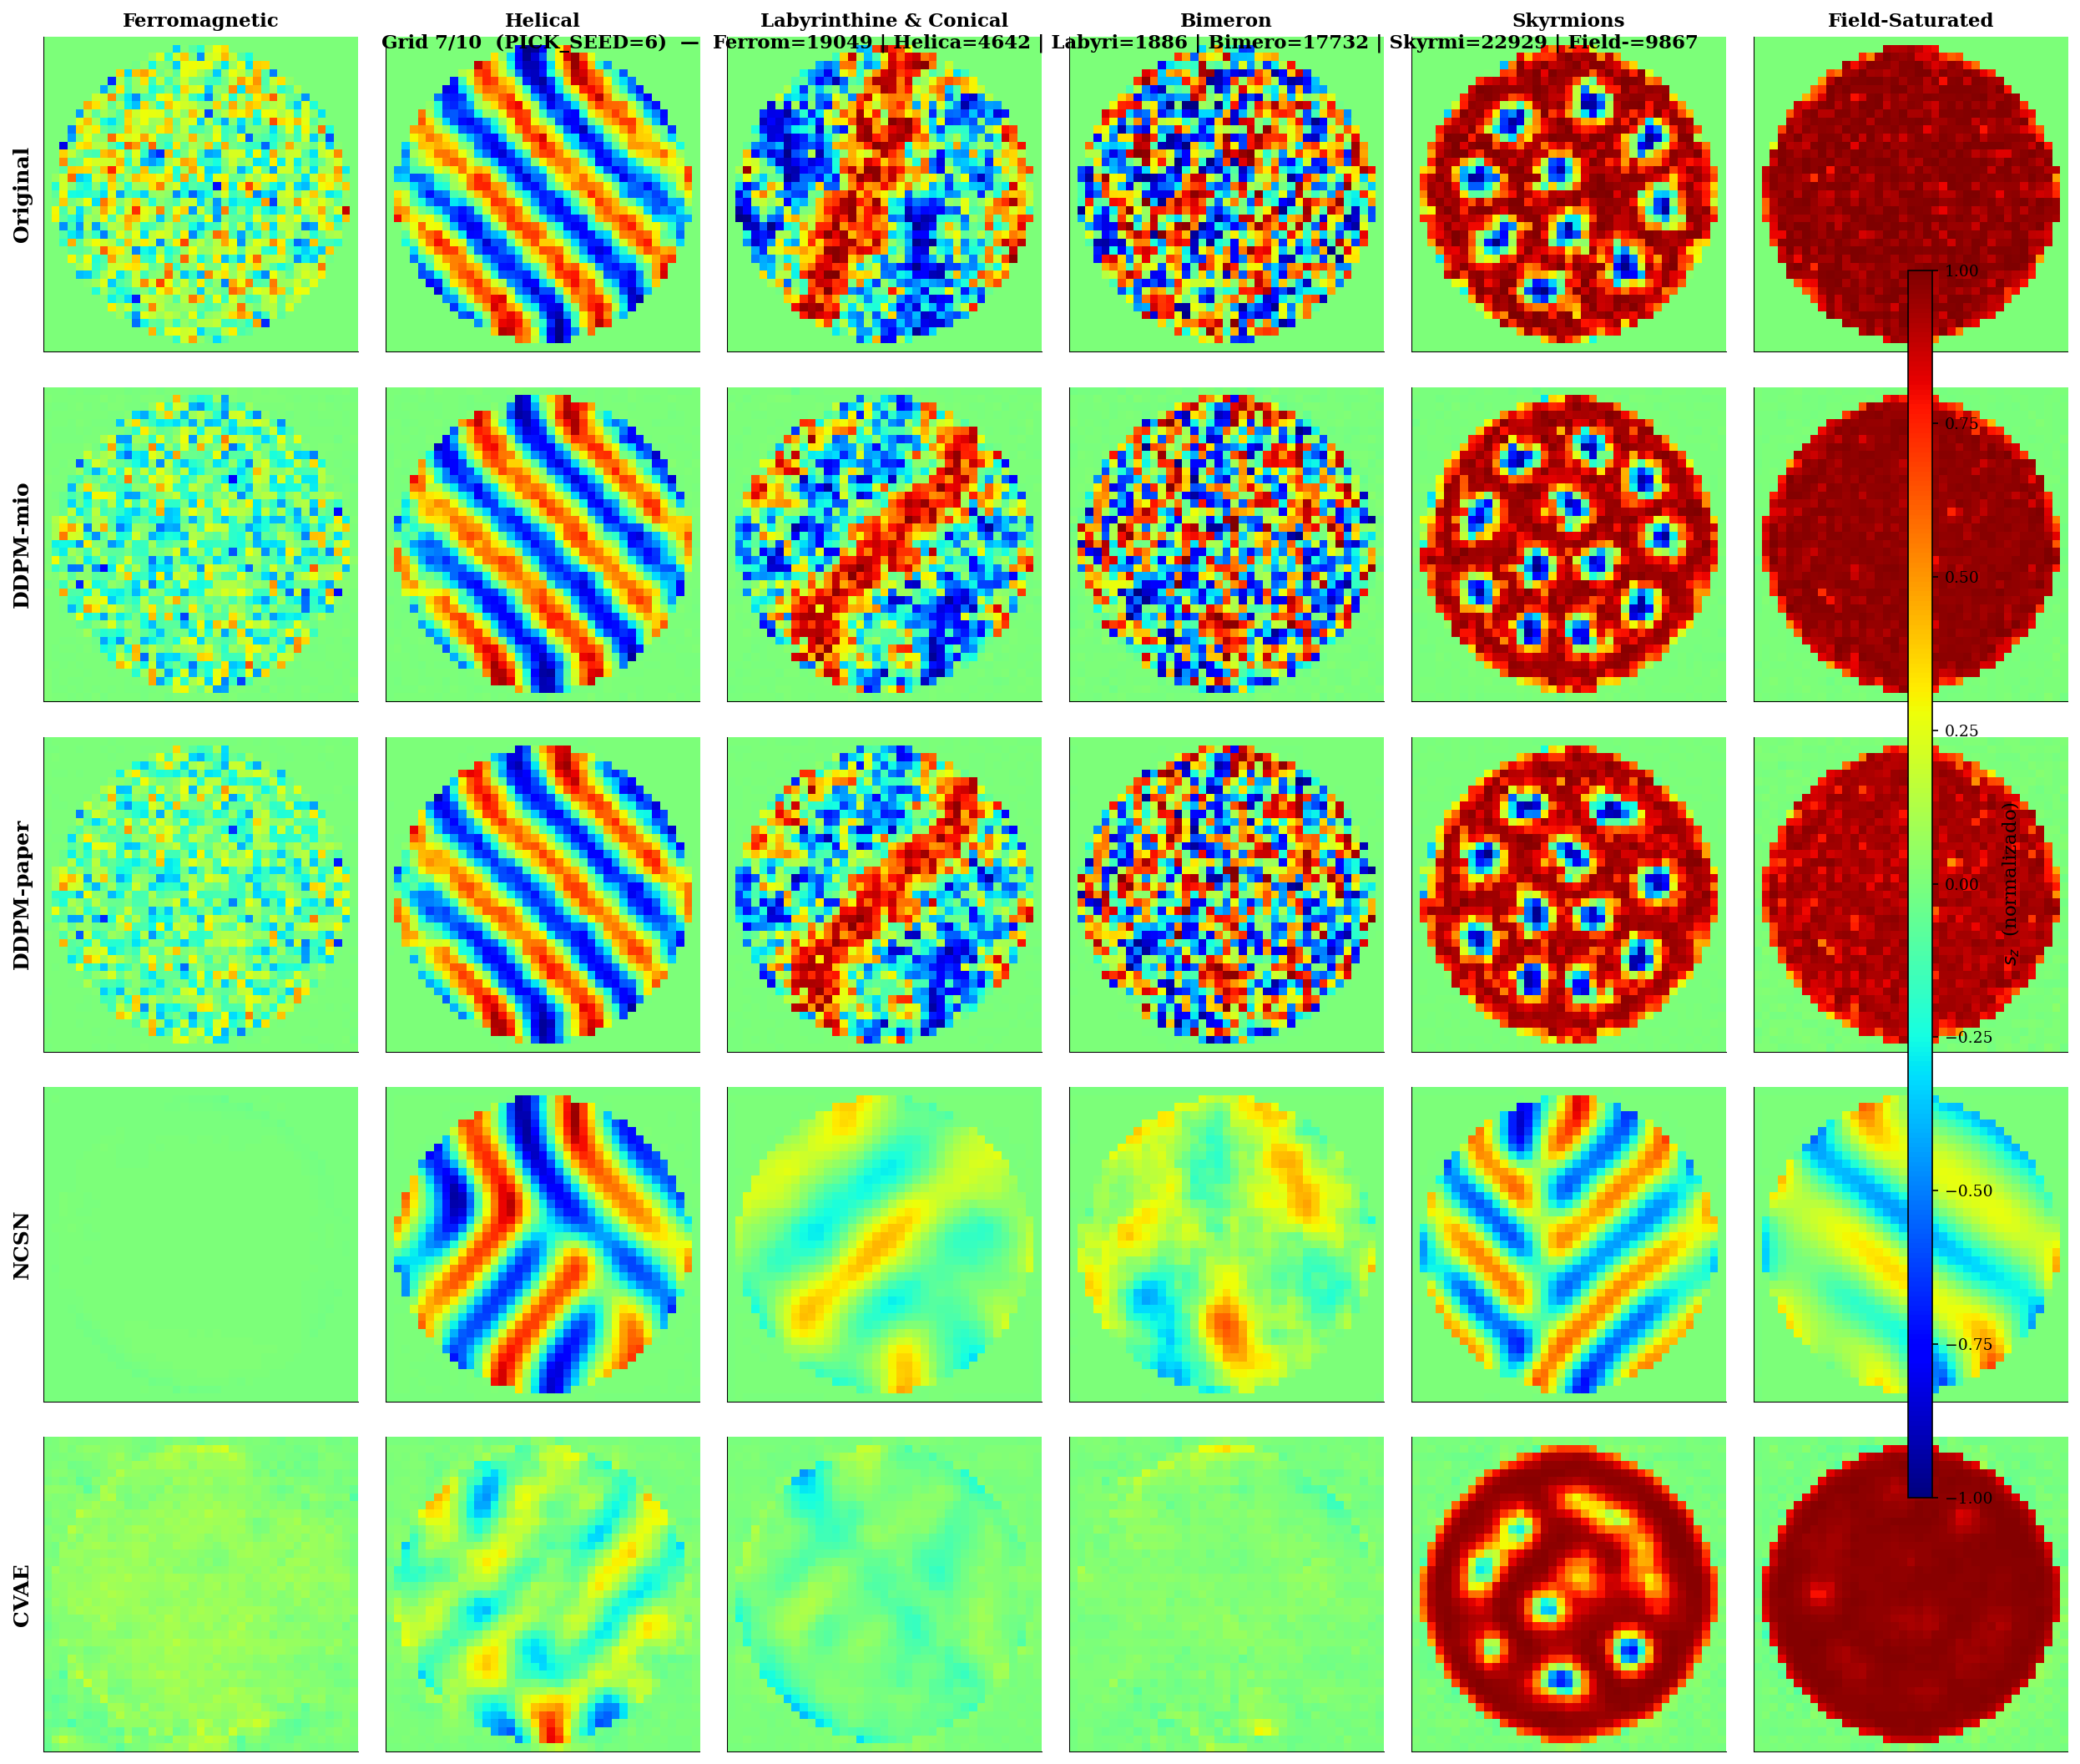

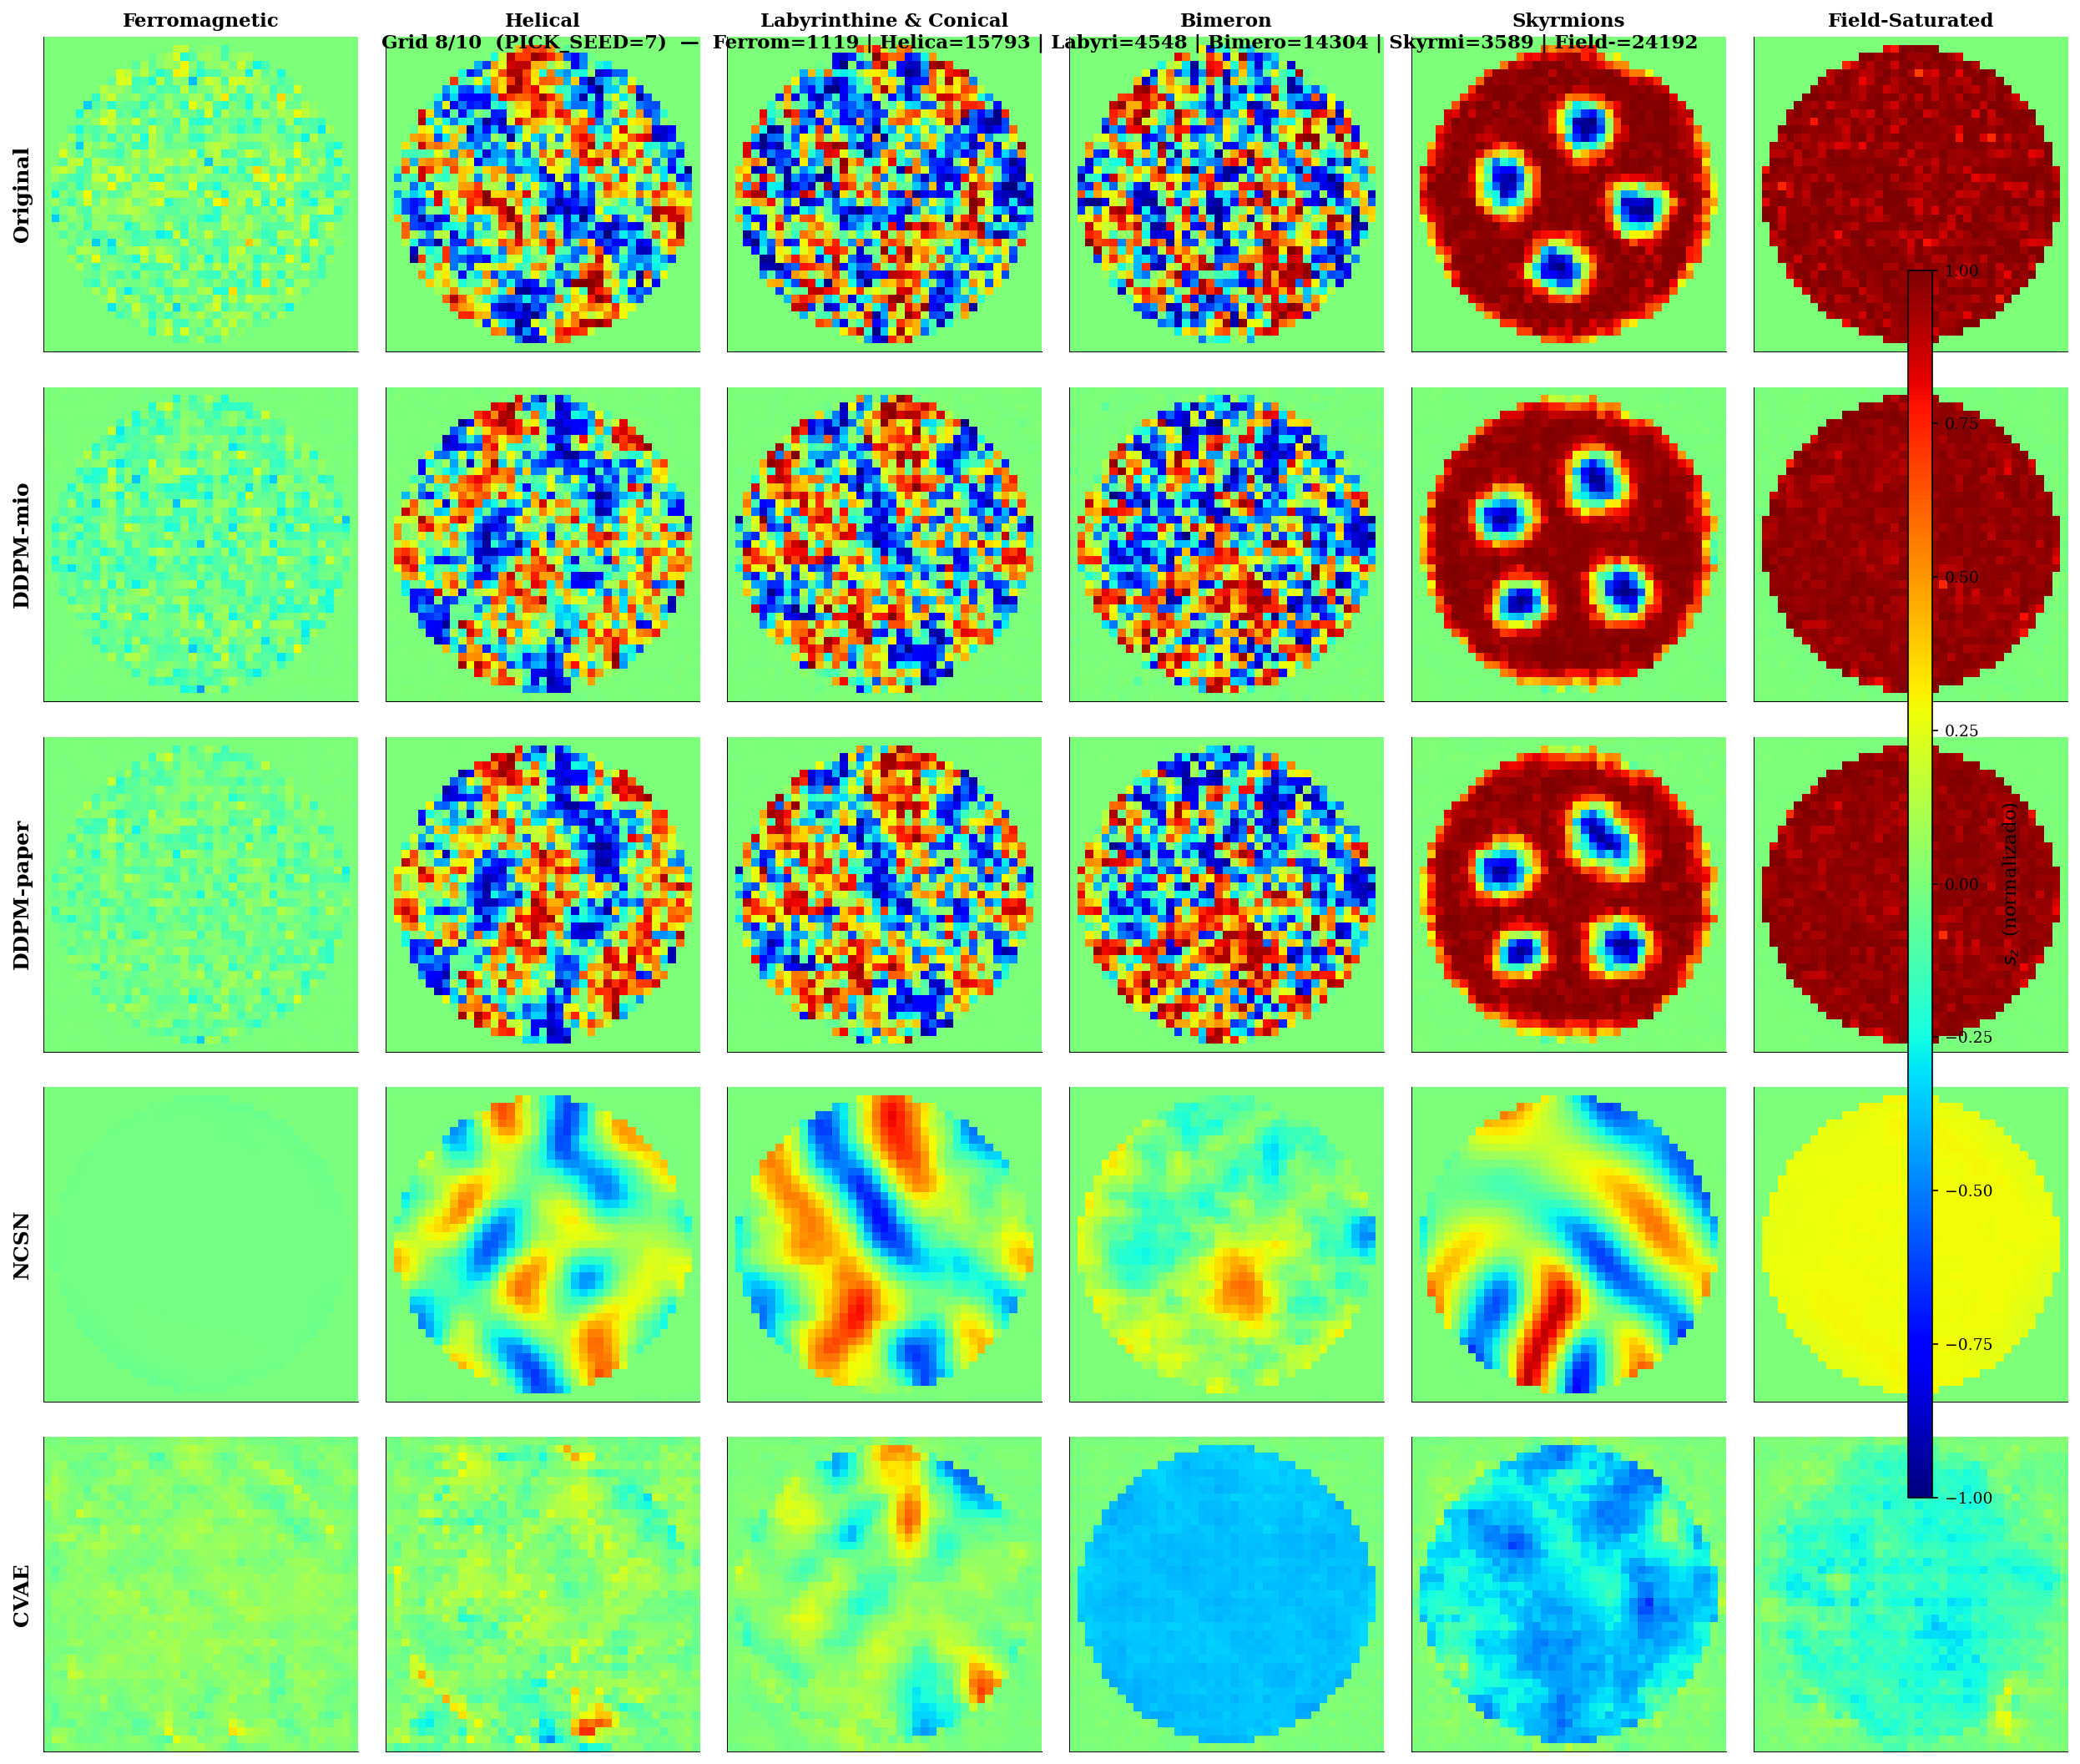

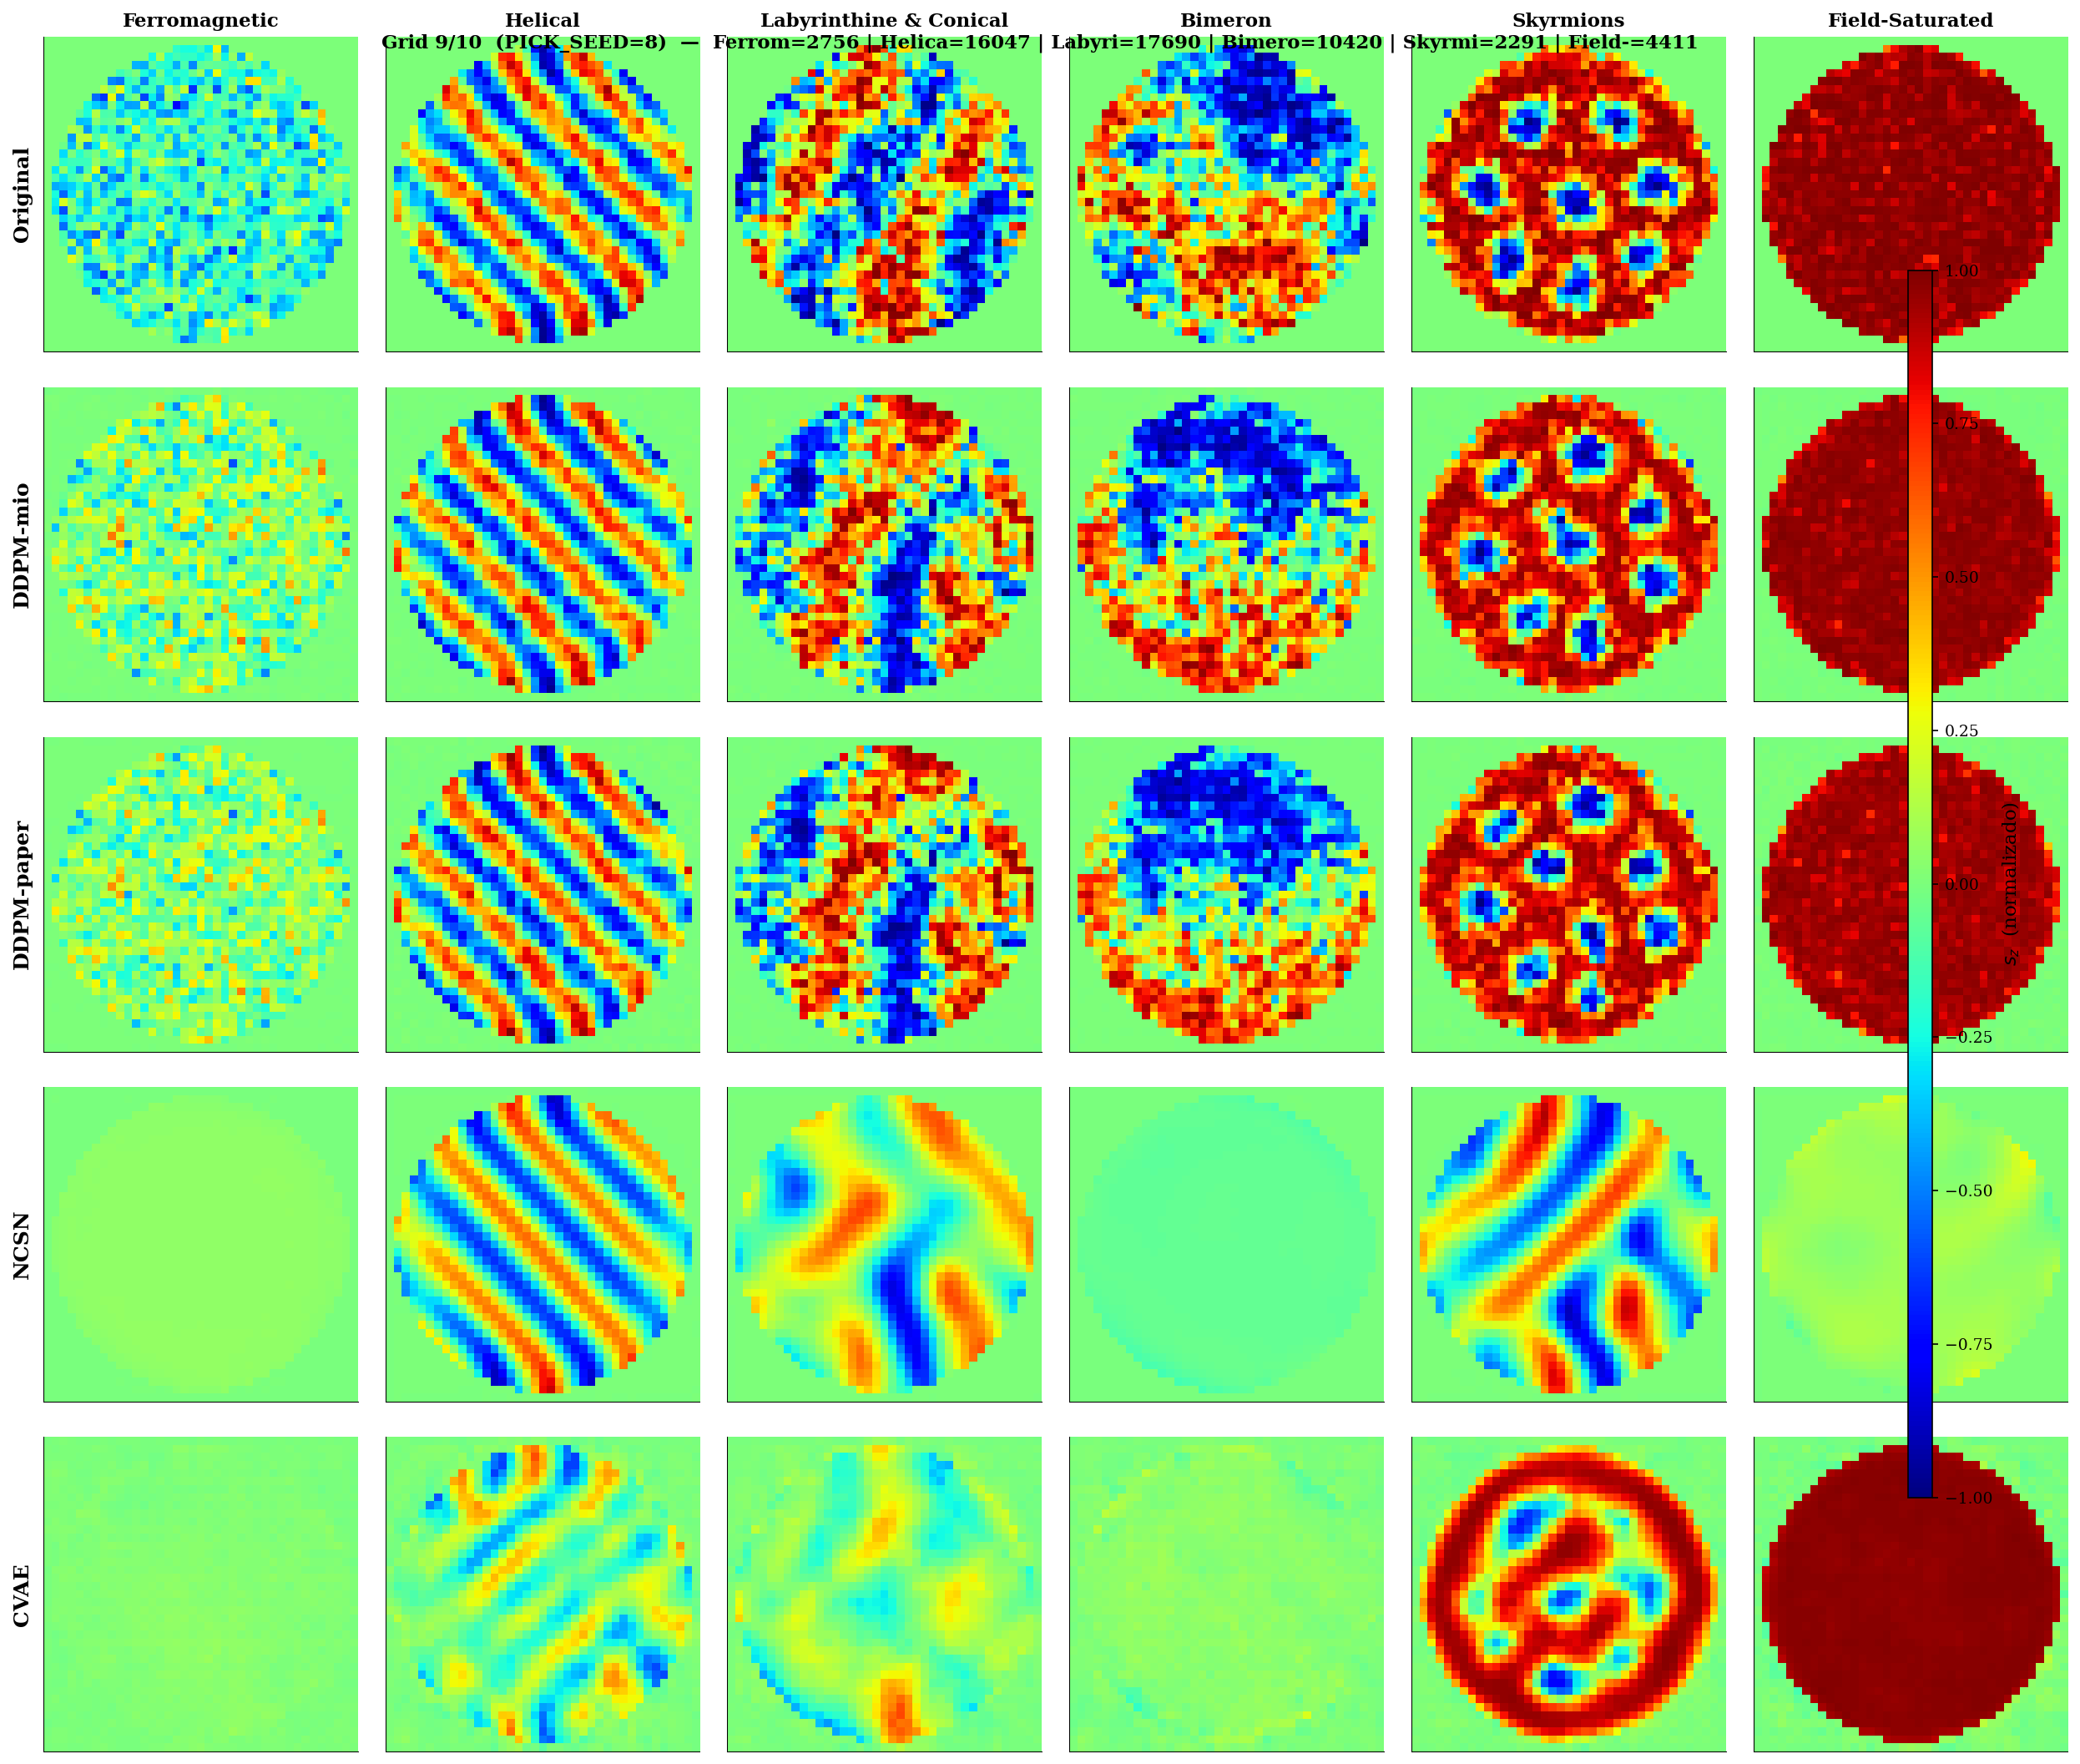

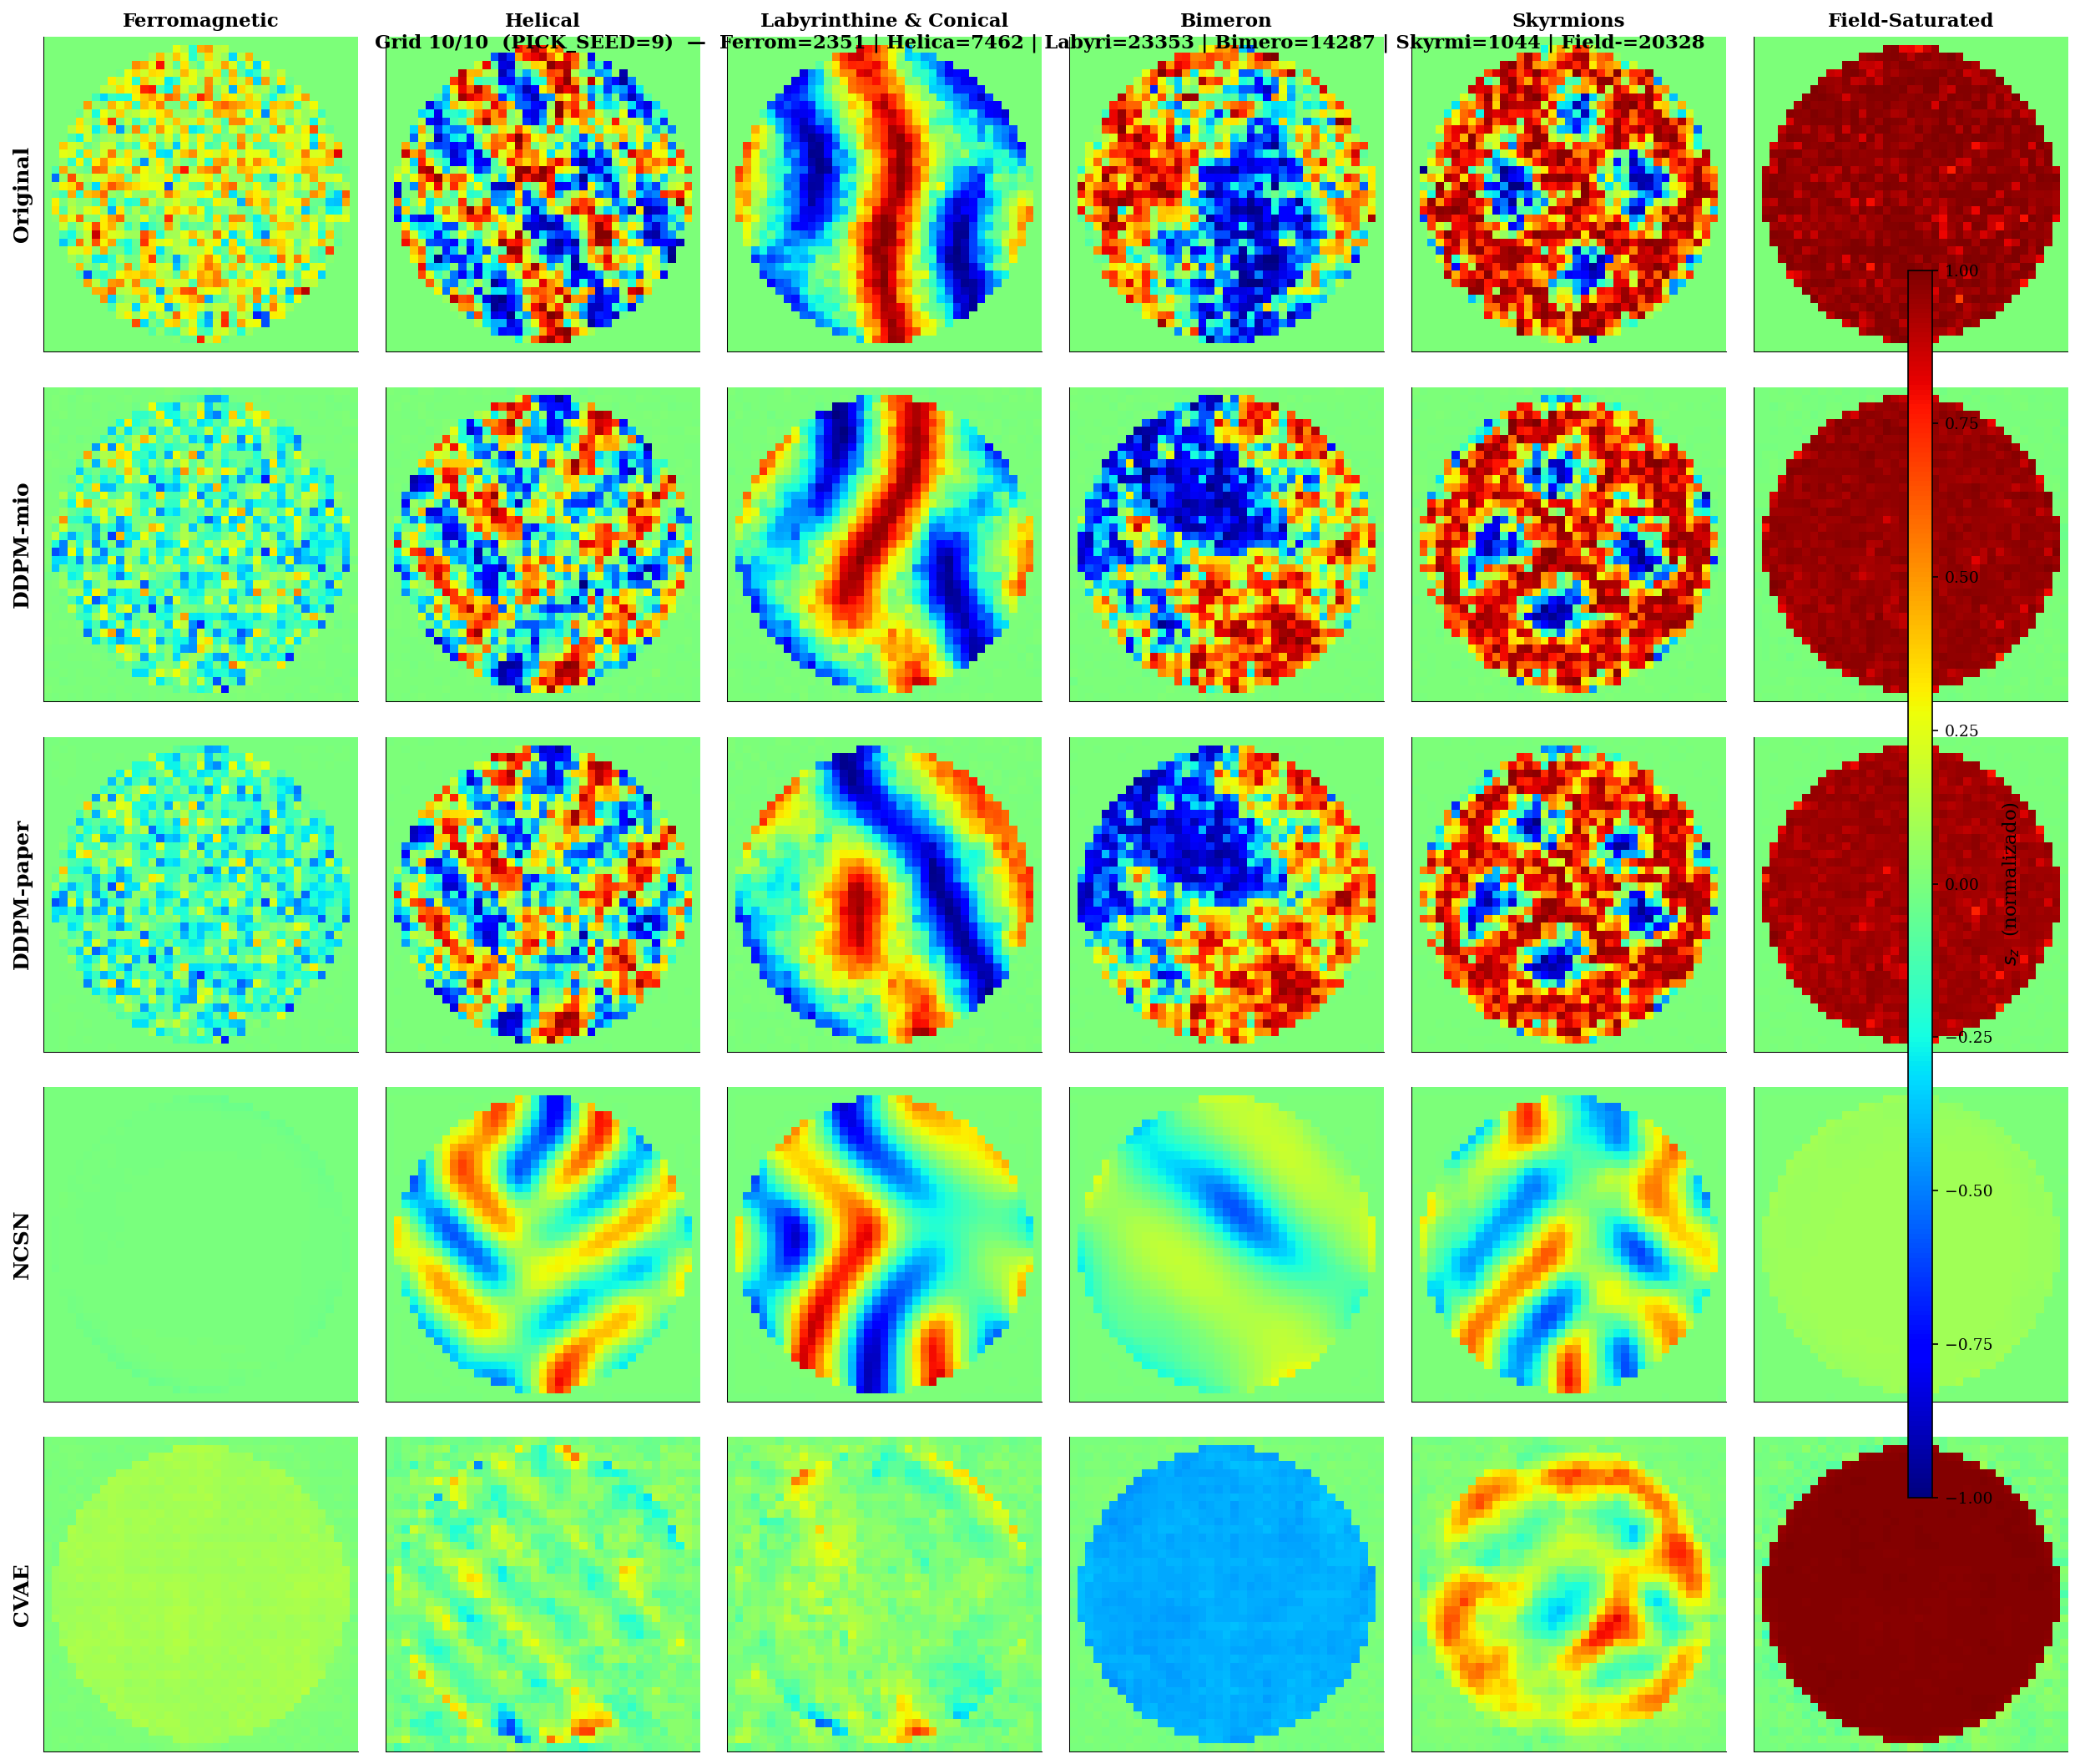


✓ 10 grillas en /kaggle/working/eval_cache/visual_grid_*.png
  Elige la que prefieras por el PICK_SEED del título.


In [17]:
for grid_id in range(N_GRIDS):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols + 1.5, 2.5*n_rows + 1.5),
                            gridspec_kw=dict(wspace=0.08, hspace=0.08))
    if n_rows == 1: axes = axes[None, :]
    if n_cols == 1: axes = axes[:, None]

    for i, row in enumerate(active_rows):
        for j, ph in enumerate(STRUCTURE_NAMES):
            ax = axes[i, j]
            img = gens_visual.get(row, {}).get(grid_id, {}).get(ph)
            if img is None:
                ax.set_facecolor("#eeeeee"); ax.text(0.5, 0.5, "—", ha='center', va='center',
                                                      transform=ax.transAxes, fontsize=20, color='gray')
            else:
                ax.imshow(img, cmap='jet', vmin=-1, vmax=1, interpolation='nearest')
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_linewidth(0.5)
            if j == 0:
                ax.set_ylabel(row, fontsize=12, fontweight='bold', rotation=90, labelpad=12, va='center')
            if i == 0:
                ax.set_title(ph, fontsize=11, fontweight='bold', pad=6)

    idx_info = " | ".join(f"{ph[:6]}={selected_visual[(grid_id, ph)][0]}"
                          for ph in STRUCTURE_NAMES if (grid_id, ph) in selected_visual)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
    sm = plt.cm.ScalarMappable(cmap='jet', norm=Normalize(vmin=-1, vmax=1)); sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=r"$s_z$  (normalizado)")
    fig.suptitle(f"Grid {grid_id+1}/{N_GRIDS}  (PICK_SEED={PICK_SEEDS[grid_id]})  —  {idx_info}",
                 fontsize=11, fontweight='bold', y=0.985)
    plt.subplots_adjust(left=0.08, right=0.91, top=0.93, bottom=0.04)

    out_path = os.path.join(CACHE_DIR, f"visual_grid_{grid_id:02d}.png")
    fig.savefig(out_path, dpi=120, bbox_inches='tight', facecolor='white')
    plt.show()

print(f"\n✓ {N_GRIDS} grillas en {CACHE_DIR}/visual_grid_*.png")
print(f"  Elige la que prefieras por el PICK_SEED del título.")